Heat pilot registry:


,city,climate_type,pilot_start,pilot_end,tract_count,unique_geoids,missing_income_clean,missing_poverty_rate,boundary_minx,boundary_miny,boundary_maxx,boundary_maxy,lst_source,hi_source,notes
0,Houston,humid subtropical,2023-06-01,2023-08-31,654,654,9,3,-95.909743,29.516282,-95.012637,30.155908,LANDSAT/LC08/C02/T1_L2 + LANDSAT/LC09/C02/T1_L2,ECMWF/ERA5_LAND/HOURLY,pilot summer window for workflow validation; n...
1,Phoenix,arid,2023-06-01,2023-08-31,373,373,5,3,-112.324065,33.290260,-111.925521,33.918391,LANDSAT/LC08/C02/T1_L2 + LANDSAT/LC09/C02/T1_L2,ECMWF/ERA5_LAND/HOURLY,pilot summer window for workflow validation; n...



Heat-ready export log:


,city,tract_geojson,boundary_geojson,tract_lookup_csv,tract_geojson_exists,boundary_geojson_exists,tract_lookup_exists
0,Houston,/Users/yufeizhou/Desktop/heat-exposure-compare...,/Users/yufeizhou/Desktop/heat-exposure-compare...,/Users/yufeizhou/Desktop/heat-exposure-compare...,True,True,True
1,Phoenix,/Users/yufeizhou/Desktop/heat-exposure-compare...,/Users/yufeizhou/Desktop/heat-exposure-compare...,/Users/yufeizhou/Desktop/heat-exposure-compare...,True,True,True


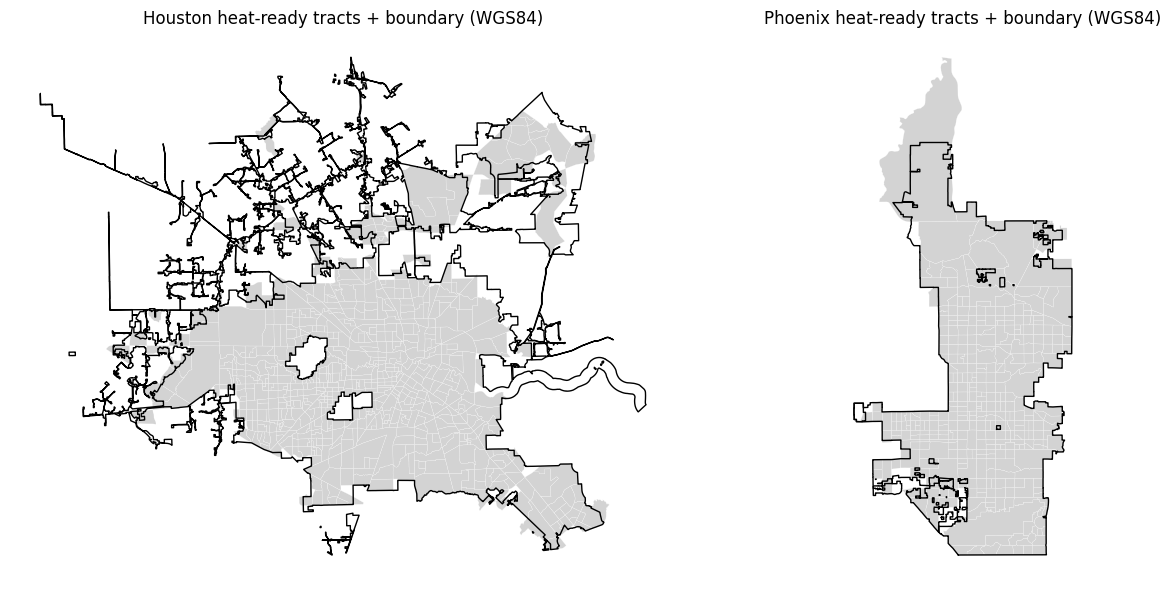


Block 1 file check:
/Users/yufeizhou/Desktop/heat-exposure-compare/outputs/pilot/heat_pilot_registry.csv -> True
/Users/yufeizhou/Desktop/heat-exposure-compare/outputs/pilot/heat_ready_export_log.csv -> True
/Users/yufeizhou/Desktop/heat-exposure-compare/figures/pilot/heat_ready_qc_map.png -> True
/Users/yufeizhou/Desktop/heat-exposure-compare/outputs/pilot/heat_ready/houston/houston_tracts_heat_ready.geojson -> True
/Users/yufeizhou/Desktop/heat-exposure-compare/outputs/pilot/heat_ready/houston/houston_boundary_heat_ready.geojson -> True
/Users/yufeizhou/Desktop/heat-exposure-compare/outputs/pilot/heat_ready/houston/houston_tract_lookup.csv -> True
/Users/yufeizhou/Desktop/heat-exposure-compare/outputs/pilot/heat_ready/phoenix/phoenix_tracts_heat_ready.geojson -> True
/Users/yufeizhou/Desktop/heat-exposure-compare/outputs/pilot/heat_ready/phoenix/phoenix_boundary_heat_ready.geojson -> True
/Users/yufeizhou/Desktop/heat-exposure-compare/outputs/pilot/heat_ready/phoenix/phoenix_tract_l

In [1]:
from pathlib import Path
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt

# =========================================================
# Notebook 04: heat pilot setup
# Block 1: build heat-ready exports from demographic master table
# =========================================================

project_root = Path.cwd().resolve().parent
data_processed = project_root / "data_processed"
output_dir = project_root / "outputs" / "pilot"
figure_dir = project_root / "figures" / "pilot"

# ---- master tables from notebook 03
houston_master_path = data_processed / "houston" / "houston_master_demo_poverty.gpkg"
phoenix_master_path = data_processed / "phoenix" / "phoenix_master_demo_poverty.gpkg"

# ---- city boundaries from notebook 02
houston_boundary_path = data_processed / "houston" / "houston_city_boundary.gpkg"
phoenix_boundary_path = data_processed / "phoenix" / "phoenix_city_boundary.gpkg"

houston_master = gpd.read_file(houston_master_path, layer="tracts")
phoenix_master = gpd.read_file(phoenix_master_path, layer="tracts")

houston_boundary = gpd.read_file(houston_boundary_path, layer="boundary")
phoenix_boundary = gpd.read_file(phoenix_boundary_path, layer="boundary")

# ---- standardize GEOID
for gdf in [houston_master, phoenix_master]:
    gdf["GEOID"] = gdf["GEOID"].astype(str)

# ---- city registry
city_data = {
    "Houston": {
        "master": houston_master,
        "boundary": houston_boundary,
        "climate_type": "humid subtropical",
        "pilot_start": "2023-06-01",
        "pilot_end": "2023-08-31",
        "lst_source": "LANDSAT/LC08/C02/T1_L2 + LANDSAT/LC09/C02/T1_L2",
        "hi_source": "ECMWF/ERA5_LAND/HOURLY",
        "notes": "pilot summer window for workflow validation; not final heat-wave window"
    },
    "Phoenix": {
        "master": phoenix_master,
        "boundary": phoenix_boundary,
        "climate_type": "arid",
        "pilot_start": "2023-06-01",
        "pilot_end": "2023-08-31",
        "lst_source": "LANDSAT/LC08/C02/T1_L2 + LANDSAT/LC09/C02/T1_L2",
        "hi_source": "ECMWF/ERA5_LAND/HOURLY",
        "notes": "pilot summer window for workflow validation; not final heat-wave window"
    }
}

registry_rows = []

for city, obj in city_data.items():
    master = obj["master"]
    boundary = obj["boundary"]

    # convert to WGS84 for EE/geemap
    master_wgs84 = master.to_crs(4326).copy()
    boundary_wgs84 = boundary.to_crs(4326).copy()

    obj["master_wgs84"] = master_wgs84
    obj["boundary_wgs84"] = boundary_wgs84

    minx, miny, maxx, maxy = boundary_wgs84.total_bounds

    registry_rows.append({
        "city": city,
        "climate_type": obj["climate_type"],
        "pilot_start": obj["pilot_start"],
        "pilot_end": obj["pilot_end"],
        "tract_count": len(master),
        "unique_geoids": master["GEOID"].nunique(),
        "missing_income_clean": master["median_household_income_clean"].isna().sum(),
        "missing_poverty_rate": master["poverty_rate"].isna().sum(),
        "boundary_minx": minx,
        "boundary_miny": miny,
        "boundary_maxx": maxx,
        "boundary_maxy": maxy,
        "lst_source": obj["lst_source"],
        "hi_source": obj["hi_source"],
        "notes": obj["notes"]
    })

heat_registry_df = pd.DataFrame(registry_rows)

print("Heat pilot registry:")
display(heat_registry_df)

# ---- export heat-ready files
heat_ready_root = output_dir / "heat_ready"
heat_ready_root.mkdir(parents=True, exist_ok=True)

export_records = []

for city, obj in city_data.items():
    city_lower = city.lower()
    city_dir = heat_ready_root / city_lower
    city_dir.mkdir(parents=True, exist_ok=True)

    master_wgs84 = obj["master_wgs84"]
    boundary_wgs84 = obj["boundary_wgs84"]

    tract_geojson_out = city_dir / f"{city_lower}_tracts_heat_ready.geojson"
    boundary_geojson_out = city_dir / f"{city_lower}_boundary_heat_ready.geojson"
    tract_lookup_out = city_dir / f"{city_lower}_tract_lookup.csv"

    for p in [tract_geojson_out, boundary_geojson_out, tract_lookup_out]:
        if p.exists():
            p.unlink()

    master_wgs84.to_file(tract_geojson_out, driver="GeoJSON")
    boundary_wgs84.to_file(boundary_geojson_out, driver="GeoJSON")

    lookup_cols = [
        c for c in [
            "GEOID",
            "city",
            "area_km2",
            "total_population_clean",
            "median_household_income_clean",
            "poverty_rate",
            "inequity_group"
        ] if c in master_wgs84.columns
    ]
    lookup_df = master_wgs84[lookup_cols].copy()
    if "city" not in lookup_df.columns:
        lookup_df["city"] = city

    lookup_df.to_csv(tract_lookup_out, index=False)

    export_records.append({
        "city": city,
        "tract_geojson": str(tract_geojson_out),
        "boundary_geojson": str(boundary_geojson_out),
        "tract_lookup_csv": str(tract_lookup_out),
        "tract_geojson_exists": tract_geojson_out.exists(),
        "boundary_geojson_exists": boundary_geojson_out.exists(),
        "tract_lookup_exists": tract_lookup_out.exists()
    })

heat_registry_out = output_dir / "heat_pilot_registry.csv"
export_log_out = output_dir / "heat_ready_export_log.csv"

heat_registry_df.to_csv(heat_registry_out, index=False)
pd.DataFrame(export_records).to_csv(export_log_out, index=False)

print("\nHeat-ready export log:")
display(pd.DataFrame(export_records))

# ---- QC figure
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for ax, city in zip(axes, ["Houston", "Phoenix"]):
    city_data[city]["master_wgs84"].plot(
        ax=ax,
        facecolor="lightgray",
        edgecolor="white",
        linewidth=0.15
    )
    city_data[city]["boundary_wgs84"].boundary.plot(
        ax=ax,
        color="black",
        linewidth=1.0
    )
    ax.set_title(f"{city} heat-ready tracts + boundary (WGS84)")
    ax.set_axis_off()

plt.tight_layout()
heat_ready_qc_map_out = figure_dir / "heat_ready_qc_map.png"
plt.savefig(heat_ready_qc_map_out, dpi=300, bbox_inches="tight")
plt.show()

final_heat_ready_files = [
    heat_registry_out,
    export_log_out,
    heat_ready_qc_map_out,
    heat_ready_root / "houston" / "houston_tracts_heat_ready.geojson",
    heat_ready_root / "houston" / "houston_boundary_heat_ready.geojson",
    heat_ready_root / "houston" / "houston_tract_lookup.csv",
    heat_ready_root / "phoenix" / "phoenix_tracts_heat_ready.geojson",
    heat_ready_root / "phoenix" / "phoenix_boundary_heat_ready.geojson",
    heat_ready_root / "phoenix" / "phoenix_tract_lookup.csv",
]

print("\nBlock 1 file check:")
for p in final_heat_ready_files:
    print(p, "->", p.exists())

In [1]:
import ee

EE_PROJECT = "yufei-gee-lab6"

ee.Authenticate(auth_mode="localhost", force=True)
ee.Initialize(project=EE_PROJECT)

print("Earth Engine initialized successfully.")


Successfully saved authorization token.
Earth Engine initialized successfully.


In [2]:
import ee
import geemap
import json

EE_PROJECT = "yufei-gee-lab6"

ee.Initialize(project=EE_PROJECT)
print("Earth Engine initialized successfully.")

Earth Engine initialized successfully.


In [3]:
import ee
import geemap
import json

EE_PROJECT = "yufei-gee-lab6"

ee.Initialize(project=EE_PROJECT)
print("Earth Engine initialized successfully.")

Earth Engine initialized successfully.


In [5]:
from pathlib import Path
import pandas as pd
import json
import ee

# =========================================================
# Earth Engine collection QC (self-contained fixed version)
# =========================================================

# ---- paths
project_root = Path.cwd().resolve().parent
output_dir = project_root / "outputs" / "pilot"

# ---- EE project
EE_PROJECT = "yufei-gee-lab6"

# ---- initialize EE
try:
    ee.Initialize(project=EE_PROJECT)
    print("Earth Engine initialized successfully.")
except Exception as e:
    print("EE not initialized in this kernel yet, trying localhost auth...")
    ee.Authenticate(auth_mode="localhost", force=True)
    ee.Initialize(project=EE_PROJECT)
    print("Earth Engine initialized successfully after auth.")

# ---- helper
def geojson_to_ee_fc(geojson_path):
    with open(geojson_path, "r", encoding="utf-8") as f:
        gj = json.load(f)
    return ee.FeatureCollection(gj)

# ---- heat-ready boundary files
houston_boundary_path = output_dir / "heat_ready" / "houston" / "houston_boundary_heat_ready.geojson"
phoenix_boundary_path = output_dir / "heat_ready" / "phoenix" / "phoenix_boundary_heat_ready.geojson"

print("Houston boundary file exists?", houston_boundary_path.exists())
print("Phoenix boundary file exists?", phoenix_boundary_path.exists())

houston_boundary_fc = geojson_to_ee_fc(houston_boundary_path)
phoenix_boundary_fc = geojson_to_ee_fc(phoenix_boundary_path)

# ---- pilot date window
pilot_start = "2023-06-01"
pilot_end = "2023-08-31"

# ---- official EE collections
landsat8 = ee.ImageCollection("LANDSAT/LC08/C02/T1_L2")
landsat9 = ee.ImageCollection("LANDSAT/LC09/C02/T1_L2")
era5_land = ee.ImageCollection("ECMWF/ERA5_LAND/HOURLY")

# ---- filter by city boundary + date
houston_l8 = landsat8.filterDate(pilot_start, pilot_end).filterBounds(houston_boundary_fc)
houston_l9 = landsat9.filterDate(pilot_start, pilot_end).filterBounds(houston_boundary_fc)
houston_era5 = era5_land.filterDate(pilot_start, pilot_end).filterBounds(houston_boundary_fc)

phoenix_l8 = landsat8.filterDate(pilot_start, pilot_end).filterBounds(phoenix_boundary_fc)
phoenix_l9 = landsat9.filterDate(pilot_start, pilot_end).filterBounds(phoenix_boundary_fc)
phoenix_era5 = era5_land.filterDate(pilot_start, pilot_end).filterBounds(phoenix_boundary_fc)

# ---- collection qc table
collection_qc = pd.DataFrame([
    {
        "city": "Houston",
        "pilot_start": pilot_start,
        "pilot_end": pilot_end,
        "landsat8_count": houston_l8.size().getInfo(),
        "landsat9_count": houston_l9.size().getInfo(),
        "era5_hourly_count": houston_era5.size().getInfo(),
    },
    {
        "city": "Phoenix",
        "pilot_start": pilot_start,
        "pilot_end": pilot_end,
        "landsat8_count": phoenix_l8.size().getInfo(),
        "landsat9_count": phoenix_l9.size().getInfo(),
        "era5_hourly_count": phoenix_era5.size().getInfo(),
    }
])

collection_qc_out = output_dir / "heat_collection_qc.csv"
collection_qc.to_csv(collection_qc_out, index=False)

display(collection_qc)
print(collection_qc_out, "->", collection_qc_out.exists())

Earth Engine initialized successfully.
Houston boundary file exists? True
Phoenix boundary file exists? True


,city,pilot_start,pilot_end,landsat8_count,landsat9_count,era5_hourly_count
0,Houston,2023-06-01,2023-08-31,18,18,2184
1,Phoenix,2023-06-01,2023-08-31,15,16,2184


/Users/yufeizhou/Desktop/heat-exposure-compare/outputs/pilot/heat_collection_qc.csv -> True


In [6]:
from pathlib import Path
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import json
import ee

# =========================================================
# Block 3: first tract-level pilot LST extraction
# Landsat 8/9 Collection 2 Level 2, summer median LST
# =========================================================

# ---- paths
project_root = Path.cwd().resolve().parent
data_processed = project_root / "data_processed"
output_dir = project_root / "outputs" / "pilot"
figure_dir = project_root / "figures" / "pilot"

# ---- EE project
EE_PROJECT = "yufei-gee-lab6"

# ---- init EE (safe to rerun)
try:
    ee.Initialize(project=EE_PROJECT)
    print("Earth Engine initialized successfully.")
except Exception:
    ee.Authenticate(auth_mode="localhost", force=True)
    ee.Initialize(project=EE_PROJECT)
    print("Earth Engine initialized successfully after auth.")

# ---- helper: geojson -> ee.FeatureCollection
def geojson_to_ee_fc(path_obj):
    with open(path_obj, "r", encoding="utf-8") as f:
        gj = json.load(f)
    return ee.FeatureCollection(gj)

# ---- load local tract tables for later merge / plotting
houston_master_path = data_processed / "houston" / "houston_master_demo_poverty.gpkg"
phoenix_master_path = data_processed / "phoenix" / "phoenix_master_demo_poverty.gpkg"

houston_master = gpd.read_file(houston_master_path, layer="tracts")
phoenix_master = gpd.read_file(phoenix_master_path, layer="tracts")

houston_master["GEOID"] = houston_master["GEOID"].astype(str)
phoenix_master["GEOID"] = phoenix_master["GEOID"].astype(str)

# ---- heat-ready boundaries and tracts exported in Block 1
houston_boundary_geojson = output_dir / "heat_ready" / "houston" / "houston_boundary_heat_ready.geojson"
phoenix_boundary_geojson = output_dir / "heat_ready" / "phoenix" / "phoenix_boundary_heat_ready.geojson"
houston_tract_geojson = output_dir / "heat_ready" / "houston" / "houston_tracts_heat_ready.geojson"
phoenix_tract_geojson = output_dir / "heat_ready" / "phoenix" / "phoenix_tracts_heat_ready.geojson"

houston_boundary_fc = geojson_to_ee_fc(houston_boundary_geojson)
phoenix_boundary_fc = geojson_to_ee_fc(phoenix_boundary_geojson)
houston_tract_fc = geojson_to_ee_fc(houston_tract_geojson)
phoenix_tract_fc = geojson_to_ee_fc(phoenix_tract_geojson)

# ---- pilot time window
pilot_start = "2023-06-01"
pilot_end = "2023-08-31"

# ---- official Landsat collections
landsat8 = ee.ImageCollection("LANDSAT/LC08/C02/T1_L2")
landsat9 = ee.ImageCollection("LANDSAT/LC09/C02/T1_L2")

# ---- QA mask + ST conversion
def mask_and_scale_lst(image):
    qa = image.select("QA_PIXEL")

    # mask out dilated cloud, cirrus, cloud, cloud shadow
    mask = (
        qa.bitwiseAnd(1 << 1).eq(0)
        .And(qa.bitwiseAnd(1 << 2).eq(0))
        .And(qa.bitwiseAnd(1 << 3).eq(0))
        .And(qa.bitwiseAnd(1 << 4).eq(0))
    )

    # ST_B10 -> Kelvin -> Celsius
    lst_c = (
        image.select("ST_B10")
        .multiply(0.00341802)
        .add(149.0)
        .subtract(273.15)
        .rename("LST_C")
    )

    return (
        lst_c.updateMask(mask)
        .copyProperties(image, image.propertyNames())
    )

def build_city_lst_collection(boundary_fc):
    l8 = (
        landsat8
        .filterDate(pilot_start, pilot_end)
        .filterBounds(boundary_fc)
        .filter(ee.Filter.eq("PROCESSING_LEVEL", "L2SP"))
        .map(mask_and_scale_lst)
    )

    l9 = (
        landsat9
        .filterDate(pilot_start, pilot_end)
        .filterBounds(boundary_fc)
        .filter(ee.Filter.eq("PROCESSING_LEVEL", "L2SP"))
        .map(mask_and_scale_lst)
    )

    merged = l8.merge(l9)
    return l8, l9, merged

houston_l8_st, houston_l9_st, houston_lst_all = build_city_lst_collection(houston_boundary_fc)
phoenix_l8_st, phoenix_l9_st, phoenix_lst_all = build_city_lst_collection(phoenix_boundary_fc)

# ---- median composite over the pilot summer
houston_lst_median = houston_lst_all.median().clip(houston_boundary_fc)
phoenix_lst_median = phoenix_lst_all.median().clip(phoenix_boundary_fc)

# ---- reduce to tracts
def reduce_landsat_lst_to_tracts(lst_image, tract_fc):
    reduced = lst_image.reduceRegions(
        collection=tract_fc,
        reducer=ee.Reducer.mean().combine(
            reducer2=ee.Reducer.median(),
            sharedInputs=True
        ),
        scale=30,
        tileScale=4
    )
    return reduced

houston_lst_fc = reduce_landsat_lst_to_tracts(houston_lst_median, houston_tract_fc)
phoenix_lst_fc = reduce_landsat_lst_to_tracts(phoenix_lst_median, phoenix_tract_fc)

# ---- FC -> DataFrame
def ee_fc_to_df(fc):
    info = fc.getInfo()
    rows = []
    for feat in info["features"]:
        rows.append(feat["properties"])
    return pd.DataFrame(rows)

houston_lst_df = ee_fc_to_df(houston_lst_fc)
phoenix_lst_df = ee_fc_to_df(phoenix_lst_fc)

# ---- standardize columns
for df, city in [(houston_lst_df, "Houston"), (phoenix_lst_df, "Phoenix")]:
    if "GEOID" in df.columns:
        df["GEOID"] = df["GEOID"].astype(str)
    df["city"] = city

rename_map = {
    "mean": "lst_summer_mean_c",
    "median": "lst_summer_median_c"
}
houston_lst_df = houston_lst_df.rename(columns=rename_map)
phoenix_lst_df = phoenix_lst_df.rename(columns=rename_map)

print("Houston LST extract sample:")
display(houston_lst_df.head())

print("Phoenix LST extract sample:")
display(phoenix_lst_df.head())

# ---- qc table
lst_extract_qc = pd.DataFrame([
    {
        "city": "Houston",
        "tract_rows": len(houston_lst_df),
        "unique_geoids": houston_lst_df["GEOID"].nunique() if "GEOID" in houston_lst_df.columns else None,
        "missing_lst_mean": houston_lst_df["lst_summer_mean_c"].isna().sum() if "lst_summer_mean_c" in houston_lst_df.columns else None,
        "missing_lst_median": houston_lst_df["lst_summer_median_c"].isna().sum() if "lst_summer_median_c" in houston_lst_df.columns else None,
        "l8_scene_count_after_filter": houston_l8_st.size().getInfo(),
        "l9_scene_count_after_filter": houston_l9_st.size().getInfo(),
        "merged_scene_count_after_filter": houston_lst_all.size().getInfo(),
    },
    {
        "city": "Phoenix",
        "tract_rows": len(phoenix_lst_df),
        "unique_geoids": phoenix_lst_df["GEOID"].nunique() if "GEOID" in phoenix_lst_df.columns else None,
        "missing_lst_mean": phoenix_lst_df["lst_summer_mean_c"].isna().sum() if "lst_summer_mean_c" in phoenix_lst_df.columns else None,
        "missing_lst_median": phoenix_lst_df["lst_summer_median_c"].isna().sum() if "lst_summer_median_c" in phoenix_lst_df.columns else None,
        "l8_scene_count_after_filter": phoenix_l8_st.size().getInfo(),
        "l9_scene_count_after_filter": phoenix_l9_st.size().getInfo(),
        "merged_scene_count_after_filter": phoenix_lst_all.size().getInfo(),
    }
])

print("LST extraction QC:")
display(lst_extract_qc)

# ---- save tract-level LST tables
houston_lst_csv = output_dir / "houston_landsat_lst_pilot.csv"
phoenix_lst_csv = output_dir / "phoenix_landsat_lst_pilot.csv"
lst_extract_qc_csv = output_dir / "lst_extract_qc.csv"

houston_lst_df.to_csv(houston_lst_csv, index=False)
phoenix_lst_df.to_csv(phoenix_lst_csv, index=False)
lst_extract_qc.to_csv(lst_extract_qc_csv, index=False)

print("\nSaved:")
print(houston_lst_csv, "->", houston_lst_csv.exists())
print(phoenix_lst_csv, "->", phoenix_lst_csv.exists())
print(lst_extract_qc_csv, "->", lst_extract_qc_csv.exists())

Earth Engine initialized successfully.
Houston LST extract sample:


,ALAND,AWATER,COUNTYFP,GEOID,NAME,NAMELSAD,STATEFP,TRACTCE,area_km2,below_poverty_count,...,low_income_flag,lst_summer_mean_c,lst_summer_median_c,median_household_income,median_household_income_clean,poverty_rate,poverty_universe,poverty_universe_clean,total_population,total_population_clean
0,1238555,0,201,48201421101,4211.01,Census Tract 4211.01,48,421101,1.239311,762,...,True,49.259128,49.220826,57959,57959.0,0.287982,2646,2646,2646,2646
1,1654036,22924,201,48201423301,4233.01,Census Tract 4233.01,48,423301,1.678074,499,...,False,48.109522,47.779601,61979,61979.0,0.101899,4897,4897,4897,4897
2,963415,0,201,48201453401,4534.01,Census Tract 4534.01,48,453401,0.964123,714,...,False,50.612499,50.532028,72572,72572.0,0.242857,2940,2940,2953,2953
3,3231321,0,201,48201331100,3311,Census Tract 3311,48,331100,3.232928,1034,...,True,50.163449,50.092671,53974,53974.0,0.260322,3972,3972,3979,3979
4,3546122,0,201,48201331200,3312,Census Tract 3312,48,331200,3.547893,2017,...,True,46.407487,47.162345,29650,29650.0,0.400437,5037,5037,5051,5051


Phoenix LST extract sample:


,ALAND,AWATER,COUNTYFP,GEOID,NAME,NAMELSAD,STATEFP,TRACTCE,area_km2,below_poverty_count,...,low_income_flag,lst_summer_mean_c,lst_summer_median_c,median_household_income,median_household_income_clean,poverty_rate,poverty_universe,poverty_universe_clean,total_population,total_population_clean
0,7360771,0,013,04013117200,1172,Census Tract 1172,04,117200,7.356595,292,...,True,59.184660,59.281495,65735,65735.0,0.259556,1125,1125,1125,1125
1,5194775,1855,013,04013082016,820.16,Census Tract 820.16,04,082016,5.194239,530,...,False,54.900412,56.063275,90156,90156.0,0.127742,4149,4149,4197,4197
2,2556177,25320,013,04013104402,1044.02,Census Tract 1044.02,04,104402,2.580105,305,...,True,55.605055,55.905070,70455,70455.0,0.125257,2435,2435,2435,2435
3,1067401,0,013,04013104701,1047.01,Census Tract 1047.01,04,104701,1.066803,639,...,True,56.180348,57.086081,68613,68613.0,0.234323,2727,2727,2727,2727
4,1449651,0,013,04013104702,1047.02,Census Tract 1047.02,04,104702,1.448834,770,...,True,56.526002,56.969586,42543,42543.0,0.210268,3662,3662,3662,3662


LST extraction QC:


,city,tract_rows,unique_geoids,missing_lst_mean,missing_lst_median,l8_scene_count_after_filter,l9_scene_count_after_filter,merged_scene_count_after_filter
0,Houston,654,654,0,0,18,18,36
1,Phoenix,373,373,0,0,15,16,31



Saved:
/Users/yufeizhou/Desktop/heat-exposure-compare/outputs/pilot/houston_landsat_lst_pilot.csv -> True
/Users/yufeizhou/Desktop/heat-exposure-compare/outputs/pilot/phoenix_landsat_lst_pilot.csv -> True
/Users/yufeizhou/Desktop/heat-exposure-compare/outputs/pilot/lst_extract_qc.csv -> True


Master + LST QC:


,city,tract_rows,unique_geoids,missing_lst_mean_after_merge,missing_lst_median_after_merge,median_lst_c,mean_lst_c
0,Houston,654,654,0,0,48.531293,48.245528
1,Phoenix,373,373,0,0,57.217040,56.808110


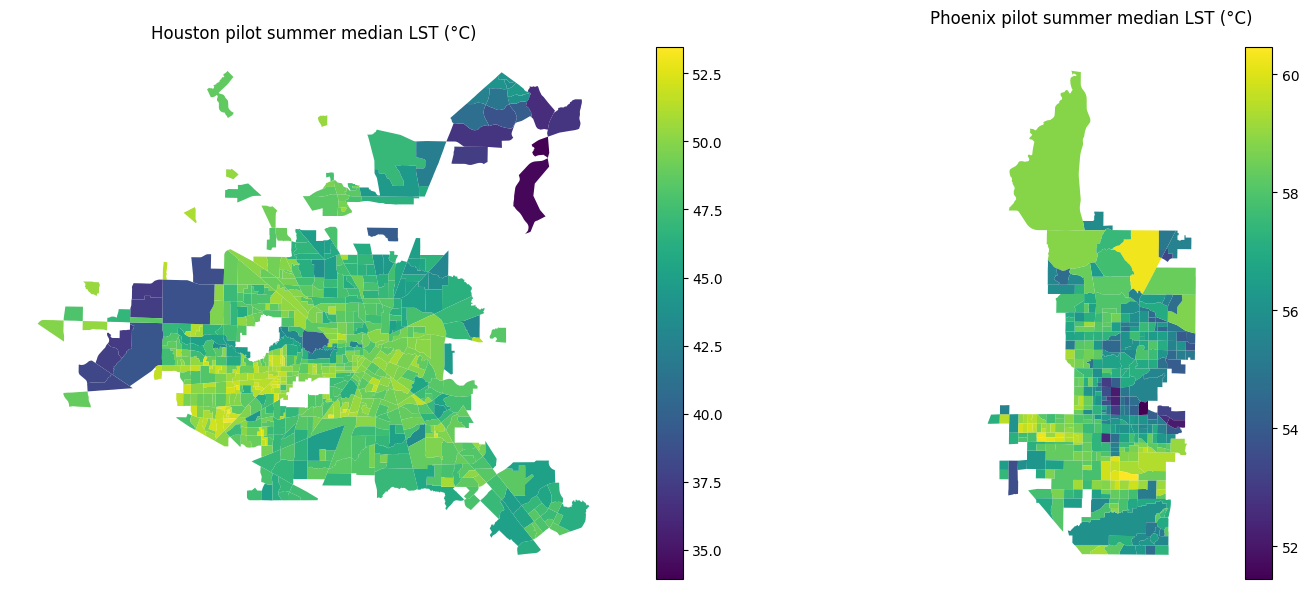


Block 4 file check:
/Users/yufeizhou/Desktop/heat-exposure-compare/data_processed/houston/houston_master_with_lst.gpkg -> True
/Users/yufeizhou/Desktop/heat-exposure-compare/data_processed/phoenix/phoenix_master_with_lst.gpkg -> True
/Users/yufeizhou/Desktop/heat-exposure-compare/outputs/pilot/master_lst_qc.csv -> True
/Users/yufeizhou/Desktop/heat-exposure-compare/figures/pilot/pilot_summer_lst_map.png -> True


In [7]:
# =========================================================
# Block 4: merge LST back to master tables + first LST maps
# =========================================================

# ---- keep only needed columns from LST extract
houston_lst_keep = houston_lst_df[["GEOID", "lst_summer_mean_c", "lst_summer_median_c"]].copy()
phoenix_lst_keep = phoenix_lst_df[["GEOID", "lst_summer_mean_c", "lst_summer_median_c"]].copy()

houston_master_lst = houston_master.copy()
phoenix_master_lst = phoenix_master.copy()

houston_master_lst["GEOID"] = houston_master_lst["GEOID"].astype(str)
phoenix_master_lst["GEOID"] = phoenix_master_lst["GEOID"].astype(str)

# if rerun, drop old LST columns first
for gdf in [houston_master_lst, phoenix_master_lst]:
    for col in ["lst_summer_mean_c", "lst_summer_median_c"]:
        if col in gdf.columns:
            gdf.drop(columns=[col], inplace=True)

houston_master_lst = houston_master_lst.merge(houston_lst_keep, on="GEOID", how="left")
phoenix_master_lst = phoenix_master_lst.merge(phoenix_lst_keep, on="GEOID", how="left")

# ---- merge qc
master_lst_qc = pd.DataFrame([
    {
        "city": "Houston",
        "tract_rows": len(houston_master_lst),
        "unique_geoids": houston_master_lst["GEOID"].nunique(),
        "missing_lst_mean_after_merge": houston_master_lst["lst_summer_mean_c"].isna().sum(),
        "missing_lst_median_after_merge": houston_master_lst["lst_summer_median_c"].isna().sum(),
        "median_lst_c": houston_master_lst["lst_summer_median_c"].median(skipna=True),
        "mean_lst_c": houston_master_lst["lst_summer_mean_c"].mean(skipna=True),
    },
    {
        "city": "Phoenix",
        "tract_rows": len(phoenix_master_lst),
        "unique_geoids": phoenix_master_lst["GEOID"].nunique(),
        "missing_lst_mean_after_merge": phoenix_master_lst["lst_summer_mean_c"].isna().sum(),
        "missing_lst_median_after_merge": phoenix_master_lst["lst_summer_median_c"].isna().sum(),
        "median_lst_c": phoenix_master_lst["lst_summer_median_c"].median(skipna=True),
        "mean_lst_c": phoenix_master_lst["lst_summer_mean_c"].mean(skipna=True),
    }
])

print("Master + LST QC:")
display(master_lst_qc)

# ---- save updated master tables
houston_master_lst_out = data_processed / "houston" / "houston_master_with_lst.gpkg"
phoenix_master_lst_out = data_processed / "phoenix" / "phoenix_master_with_lst.gpkg"
master_lst_qc_out = output_dir / "master_lst_qc.csv"

houston_master_lst.to_file(houston_master_lst_out, layer="tracts", driver="GPKG")
phoenix_master_lst.to_file(phoenix_master_lst_out, layer="tracts", driver="GPKG")
master_lst_qc.to_csv(master_lst_qc_out, index=False)

# ---- first real heat maps
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

houston_master_lst.plot(
    column="lst_summer_median_c",
    ax=axes[0],
    legend=True,
    missing_kwds={"color": "lightgray", "label": "Missing"}
)
axes[0].set_title("Houston pilot summer median LST (°C)")
axes[0].set_axis_off()

phoenix_master_lst.plot(
    column="lst_summer_median_c",
    ax=axes[1],
    legend=True,
    missing_kwds={"color": "lightgray", "label": "Missing"}
)
axes[1].set_title("Phoenix pilot summer median LST (°C)")
axes[1].set_axis_off()

plt.tight_layout()
lst_map_out = figure_dir / "pilot_summer_lst_map.png"
plt.savefig(lst_map_out, dpi=300, bbox_inches="tight")
plt.show()

# ---- final check
block4_files = [
    houston_master_lst_out,
    phoenix_master_lst_out,
    master_lst_qc_out,
    lst_map_out
]

print("\nBlock 4 file check:")
for p in block4_files:
    print(p, "->", p.exists())

Hotspot QC:


,city,tract_rows,hotspot_cut_top20_c,hotspot_top20_count,hotspot_top20_share,hotspot_top10_count,median_lst_city,max_lst_city
0,Houston,654,50.314631,131,0.200306,66,48.531293,53.481081
1,Phoenix,373,58.607177,75,0.201072,38,57.217040,60.466231


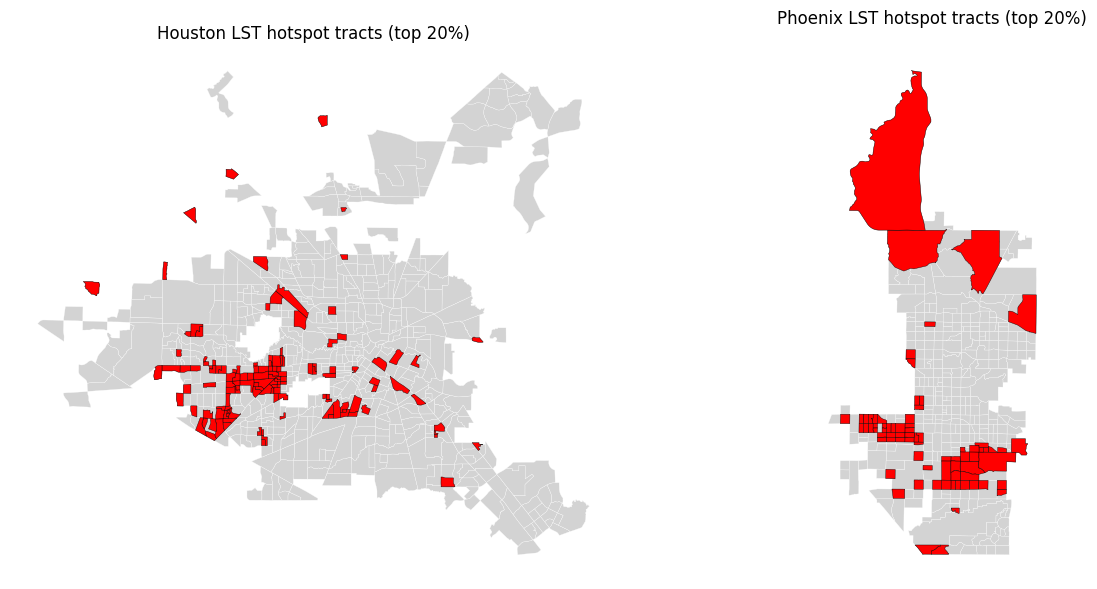


Block 5 file check:
/Users/yufeizhou/Desktop/heat-exposure-compare/data_processed/houston/houston_master_with_lst_hotspot.gpkg -> True
/Users/yufeizhou/Desktop/heat-exposure-compare/data_processed/phoenix/phoenix_master_with_lst_hotspot.gpkg -> True
/Users/yufeizhou/Desktop/heat-exposure-compare/outputs/pilot/hotspot_qc.csv -> True
/Users/yufeizhou/Desktop/heat-exposure-compare/figures/pilot/lst_hotspot_top20_map.png -> True


In [8]:
from pathlib import Path
import pandas as pd
import geopandas as gpd
import numpy as np
import matplotlib.pyplot as plt

# =========================================================
# Block 5: create LST hotspot variables
# =========================================================

project_root = Path.cwd().resolve().parent
data_processed = project_root / "data_processed"
output_dir = project_root / "outputs" / "pilot"
figure_dir = project_root / "figures" / "pilot"

# ---- read block 4 outputs fresh from disk
houston_path = data_processed / "houston" / "houston_master_with_lst.gpkg"
phoenix_path = data_processed / "phoenix" / "phoenix_master_with_lst.gpkg"

houston = gpd.read_file(houston_path, layer="tracts")
phoenix = gpd.read_file(phoenix_path, layer="tracts")

houston["GEOID"] = houston["GEOID"].astype(str)
phoenix["GEOID"] = phoenix["GEOID"].astype(str)

# ---- standardize / create needed socioeconomic fields
def prepare_city_for_hotspot(gdf, city_name):
    gdf = gdf.copy()
    gdf["city"] = city_name

    # poverty_rate
    if "poverty_rate" not in gdf.columns:
        if {"below_poverty_count", "total_population"}.issubset(gdf.columns):
            gdf["poverty_rate"] = np.where(
                gdf["total_population"] > 0,
                gdf["below_poverty_count"] / gdf["total_population"],
                np.nan
            )
        else:
            gdf["poverty_rate"] = np.nan

    # low_income_flag -> boolean-ish
    if "low_income_flag" in gdf.columns:
        gdf["low_income_flag"] = gdf["low_income_flag"].astype("boolean")
    else:
        # fallback: city median income split
        income_cut = gdf["median_household_income"].median(skipna=True)
        gdf["low_income_flag"] = gdf["median_household_income"] < income_cut

    # high_poverty_flag
    if "high_poverty_flag" not in gdf.columns:
        poverty_cut = gdf["poverty_rate"].median(skipna=True)
        gdf["high_poverty_flag"] = gdf["poverty_rate"] >= poverty_cut
        gdf["poverty_cut_city_median"] = poverty_cut
    else:
        poverty_cut = gdf["poverty_rate"].median(skipna=True)
        gdf["poverty_cut_city_median"] = poverty_cut

    # inequity_group
    if "inequity_group" not in gdf.columns:
        gdf["inequity_group"] = np.select(
            [
                (gdf["low_income_flag"] == False) & (gdf["high_poverty_flag"] == True),
                (gdf["low_income_flag"] == False) & (gdf["high_poverty_flag"] == False),
                (gdf["low_income_flag"] == True) & (gdf["high_poverty_flag"] == True),
                (gdf["low_income_flag"] == True) & (gdf["high_poverty_flag"] == False),
            ],
            [
                "High income + High poverty",
                "High income + Low poverty",
                "Low income + High poverty",
                "Low income + Low poverty",
            ],
            default="Missing"
        )

    # hotspot: top 20% hottest tracts within each city
    hot_cut = gdf["lst_summer_median_c"].quantile(0.80)
    gdf["lst_hotspot_top20"] = gdf["lst_summer_median_c"] >= hot_cut
    gdf["lst_hotspot_top10"] = gdf["lst_summer_median_c"] >= gdf["lst_summer_median_c"].quantile(0.90)
    gdf["lst_hotspot_cut_top20_c"] = hot_cut

    return gdf

houston_hot = prepare_city_for_hotspot(houston, "Houston")
phoenix_hot = prepare_city_for_hotspot(phoenix, "Phoenix")

# ---- QC table
hotspot_qc = pd.DataFrame([
    {
        "city": "Houston",
        "tract_rows": len(houston_hot),
        "hotspot_cut_top20_c": houston_hot["lst_hotspot_cut_top20_c"].iloc[0],
        "hotspot_top20_count": int(houston_hot["lst_hotspot_top20"].sum()),
        "hotspot_top20_share": float(houston_hot["lst_hotspot_top20"].mean()),
        "hotspot_top10_count": int(houston_hot["lst_hotspot_top10"].sum()),
        "median_lst_city": float(houston_hot["lst_summer_median_c"].median()),
        "max_lst_city": float(houston_hot["lst_summer_median_c"].max()),
    },
    {
        "city": "Phoenix",
        "tract_rows": len(phoenix_hot),
        "hotspot_cut_top20_c": phoenix_hot["lst_hotspot_cut_top20_c"].iloc[0],
        "hotspot_top20_count": int(phoenix_hot["lst_hotspot_top20"].sum()),
        "hotspot_top20_share": float(phoenix_hot["lst_hotspot_top20"].mean()),
        "hotspot_top10_count": int(phoenix_hot["lst_hotspot_top10"].sum()),
        "median_lst_city": float(phoenix_hot["lst_summer_median_c"].median()),
        "max_lst_city": float(phoenix_hot["lst_summer_median_c"].max()),
    }
])

print("Hotspot QC:")
display(hotspot_qc)

# ---- save hotspot-enhanced master tables
houston_hot_out = data_processed / "houston" / "houston_master_with_lst_hotspot.gpkg"
phoenix_hot_out = data_processed / "phoenix" / "phoenix_master_with_lst_hotspot.gpkg"
hotspot_qc_out = output_dir / "hotspot_qc.csv"

houston_hot.to_file(houston_hot_out, layer="tracts", driver="GPKG")
phoenix_hot.to_file(phoenix_hot_out, layer="tracts", driver="GPKG")
hotspot_qc.to_csv(hotspot_qc_out, index=False)

# ---- hotspot map
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for ax, gdf, city in zip(axes, [houston_hot, phoenix_hot], ["Houston", "Phoenix"]):
    gdf.plot(ax=ax, color="lightgray", edgecolor="white", linewidth=0.2)
    gdf[gdf["lst_hotspot_top20"]].plot(ax=ax, color="red", edgecolor="black", linewidth=0.3)
    ax.set_title(f"{city} LST hotspot tracts (top 20%)")
    ax.set_axis_off()

plt.tight_layout()
hotspot_map_out = figure_dir / "lst_hotspot_top20_map.png"
plt.savefig(hotspot_map_out, dpi=300, bbox_inches="tight")
plt.show()

print("\nBlock 5 file check:")
for p in [houston_hot_out, phoenix_hot_out, hotspot_qc_out, hotspot_map_out]:
    print(p, "->", p.exists())

In [10]:
# =========================================================
# Block 6: summary tables for paper-style comparison
# FIXED VERSION: drop geometry before concat
# =========================================================

# ---- convert to plain DataFrame before concatenation
houston_hot_tab = pd.DataFrame(houston_hot.drop(columns="geometry")).copy()
phoenix_hot_tab = pd.DataFrame(phoenix_hot.drop(columns="geometry")).copy()

all_hot = pd.concat(
    [houston_hot_tab, phoenix_hot_tab],
    ignore_index=True
)

# ---- overall city summary
city_summary = (
    all_hot.groupby("city")
    .agg(
        tract_count=("GEOID", "nunique"),
        median_lst_c=("lst_summer_median_c", "median"),
        mean_lst_c=("lst_summer_median_c", "mean"),
        hotspot_top20_count=("lst_hotspot_top20", "sum"),
        hotspot_top20_share=("lst_hotspot_top20", "mean"),
        median_income=("median_household_income", "median"),
        median_poverty_rate=("poverty_rate", "median"),
    )
    .reset_index()
)

city_summary["hotspot_top20_share"] = city_summary["hotspot_top20_share"] * 100

print("City summary:")
display(city_summary)

# ---- summary by low-income flag
low_income_summary = (
    all_hot.groupby(["city", "low_income_flag"])
    .agg(
        tract_count=("GEOID", "nunique"),
        median_lst_c=("lst_summer_median_c", "median"),
        mean_lst_c=("lst_summer_median_c", "mean"),
        hotspot_top20_share=("lst_hotspot_top20", "mean"),
        median_income=("median_household_income", "median"),
        median_poverty_rate=("poverty_rate", "median"),
    )
    .reset_index()
)
low_income_summary["hotspot_top20_share"] = low_income_summary["hotspot_top20_share"] * 100

print("Low-income summary:")
display(low_income_summary)

# ---- summary by high-poverty flag
high_poverty_summary = (
    all_hot.groupby(["city", "high_poverty_flag"])
    .agg(
        tract_count=("GEOID", "nunique"),
        median_lst_c=("lst_summer_median_c", "median"),
        mean_lst_c=("lst_summer_median_c", "mean"),
        hotspot_top20_share=("lst_hotspot_top20", "mean"),
        median_income=("median_household_income", "median"),
        median_poverty_rate=("poverty_rate", "median"),
    )
    .reset_index()
)
high_poverty_summary["hotspot_top20_share"] = high_poverty_summary["hotspot_top20_share"] * 100

print("High-poverty summary:")
display(high_poverty_summary)

# ---- summary by inequity group
inequity_summary = (
    all_hot.groupby(["city", "inequity_group"])
    .agg(
        tract_count=("GEOID", "nunique"),
        median_lst_c=("lst_summer_median_c", "median"),
        mean_lst_c=("lst_summer_median_c", "mean"),
        hotspot_top20_count=("lst_hotspot_top20", "sum"),
        hotspot_top20_share=("lst_hotspot_top20", "mean"),
        median_income=("median_household_income", "median"),
        median_poverty_rate=("poverty_rate", "median"),
    )
    .reset_index()
)
inequity_summary["hotspot_top20_share"] = inequity_summary["hotspot_top20_share"] * 100

print("Inequity-group summary:")
display(inequity_summary)

# ---- save all summary tables
city_summary_out = output_dir / "city_summary_lst.csv"
low_income_summary_out = output_dir / "low_income_summary_lst.csv"
high_poverty_summary_out = output_dir / "high_poverty_summary_lst.csv"
inequity_summary_out = output_dir / "inequity_group_summary_lst.csv"

city_summary.to_csv(city_summary_out, index=False)
low_income_summary.to_csv(low_income_summary_out, index=False)
high_poverty_summary.to_csv(high_poverty_summary_out, index=False)
inequity_summary.to_csv(inequity_summary_out, index=False)

print("\nBlock 6 file check:")
for p in [
    city_summary_out,
    low_income_summary_out,
    high_poverty_summary_out,
    inequity_summary_out
]:
    print(p, "->", p.exists())

City summary:


,city,tract_count,median_lst_c,mean_lst_c,hotspot_top20_count,hotspot_top20_share,median_income,median_poverty_rate
0,Houston,654,48.531293,48.277537,131,20.030581,59713.0,0.187448
1,Phoenix,373,57.217040,57.089466,75,20.107239,75573.0,0.129445


Low-income summary:


,city,low_income_flag,tract_count,median_lst_c,mean_lst_c,hotspot_top20_share,median_income,median_poverty_rate
0,Houston,False,331,48.277343,47.762614,11.480363,86250.0,0.092487
1,Houston,True,323,48.967746,48.805212,28.792570,43578.0,0.276890
2,Phoenix,False,189,56.657985,56.525487,13.756614,98611.0,0.068807
3,Phoenix,True,184,57.923013,57.668771,26.630435,56949.0,0.206732


High-poverty summary:


,city,high_poverty_flag,tract_count,median_lst_c,mean_lst_c,hotspot_top20_share,median_income,median_poverty_rate
0,Houston,False,328,48.297718,47.822615,14.024390,84141.5,0.088026
1,Houston,True,326,48.905368,48.735249,26.073620,44404.5,0.287093
2,Phoenix,False,188,56.373525,56.383981,8.510638,96740.5,0.065860
3,Phoenix,True,185,58.095675,57.806391,31.891892,60071.0,0.211162


Inequity-group summary:


,city,inequity_group,tract_count,median_lst_c,mean_lst_c,hotspot_top20_count,hotspot_top20_share,median_income,median_poverty_rate
0,Houston,High income + High poverty,53,48.473432,48.341820,8,15.094340,69277.0,0.230970
1,Houston,High income + Low poverty,269,48.153958,47.612443,30,11.152416,95076.0,0.081305
2,Houston,Low income + High poverty,271,48.967746,48.810924,77,28.413284,41985.0,0.300300
3,Houston,Low income + Low poverty,52,48.971305,48.775447,16,30.769231,53041.5,0.138214
4,Houston,Missing,9,48.848764,48.840184,0,0.000000,-666666666.0,0.028497
5,Phoenix,High income + High poverty,37,58.140256,57.777247,13,35.135135,85101.0,0.154723
6,Phoenix,High income + Low poverty,147,56.215406,56.197324,11,7.482993,105687.0,0.060079
7,Phoenix,Low income + High poverty,147,58.013217,57.804140,45,30.612245,54820.0,0.229480
8,Phoenix,Low income + Low poverty,37,57.159398,57.130952,4,10.810811,62305.0,0.095574
9,Phoenix,Missing,5,55.969260,56.910471,2,40.000000,-666666666.0,0.500000



Block 6 file check:
/Users/yufeizhou/Desktop/heat-exposure-compare/outputs/pilot/city_summary_lst.csv -> True
/Users/yufeizhou/Desktop/heat-exposure-compare/outputs/pilot/low_income_summary_lst.csv -> True
/Users/yufeizhou/Desktop/heat-exposure-compare/outputs/pilot/high_poverty_summary_lst.csv -> True
/Users/yufeizhou/Desktop/heat-exposure-compare/outputs/pilot/inequity_group_summary_lst.csv -> True


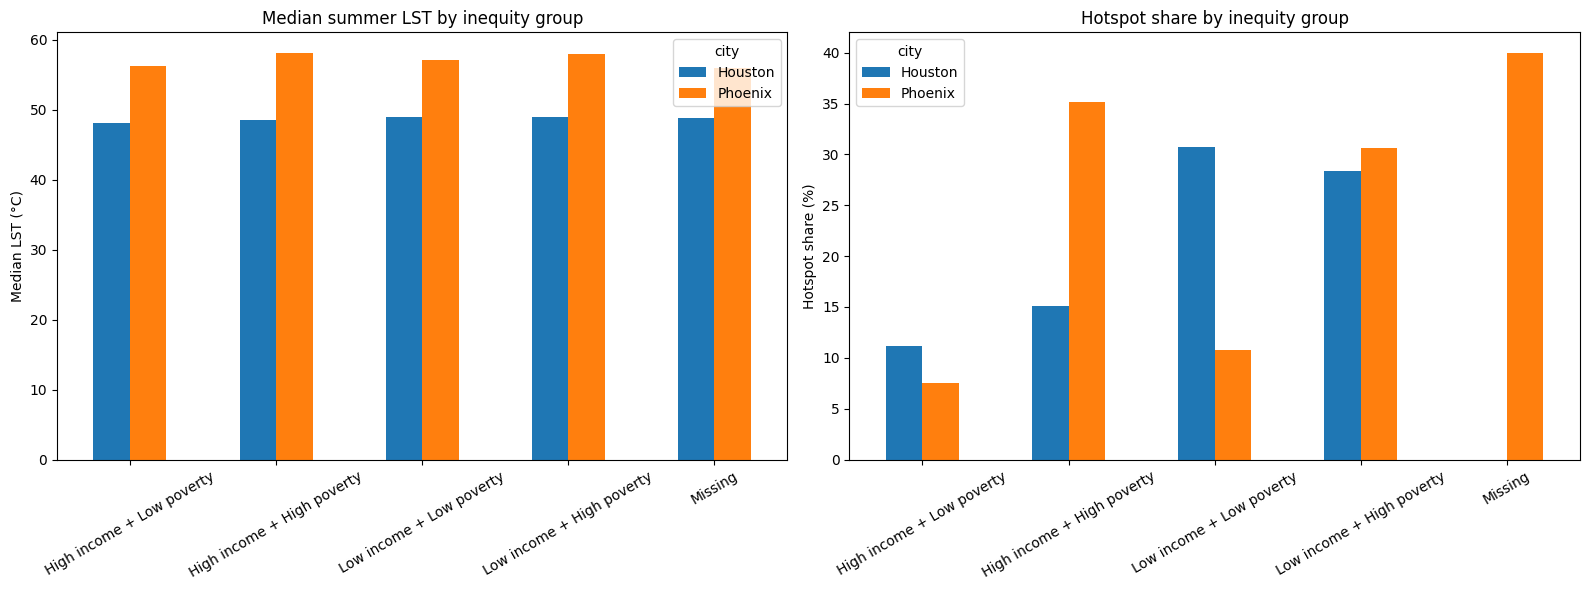


Quick interpretation:
Houston: hottest inequity group = Low income + Low poverty (48.97 °C)
Phoenix: hottest inequity group = High income + High poverty (58.14 °C)

Block 7 file check:
/Users/yufeizhou/Desktop/heat-exposure-compare/figures/pilot/inequity_group_lst_compare.png -> True


In [11]:
# =========================================================
# Block 7: comparison figure for inequity groups
# =========================================================

# keep order stable
group_order = [
    "High income + Low poverty",
    "High income + High poverty",
    "Low income + Low poverty",
    "Low income + High poverty",
    "Missing"
]

ineq_plot = inequity_summary.copy()
ineq_plot["inequity_group"] = pd.Categorical(
    ineq_plot["inequity_group"],
    categories=group_order,
    ordered=True
)
ineq_plot = ineq_plot.sort_values(["city", "inequity_group"])

# ---- pivot tables for plotting
median_lst_pivot = ineq_plot.pivot(
    index="inequity_group",
    columns="city",
    values="median_lst_c"
)

hotspot_share_pivot = ineq_plot.pivot(
    index="inequity_group",
    columns="city",
    values="hotspot_top20_share"
)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

median_lst_pivot.plot(kind="bar", ax=axes[0])
axes[0].set_title("Median summer LST by inequity group")
axes[0].set_ylabel("Median LST (°C)")
axes[0].set_xlabel("")
axes[0].tick_params(axis="x", rotation=30)

hotspot_share_pivot.plot(kind="bar", ax=axes[1])
axes[1].set_title("Hotspot share by inequity group")
axes[1].set_ylabel("Hotspot share (%)")
axes[1].set_xlabel("")
axes[1].tick_params(axis="x", rotation=30)

plt.tight_layout()
ineq_compare_out = figure_dir / "inequity_group_lst_compare.png"
plt.savefig(ineq_compare_out, dpi=300, bbox_inches="tight")
plt.show()

# ---- optional quick interpretation text
print("\nQuick interpretation:")
for city in ["Houston", "Phoenix"]:
    tmp = ineq_plot[ineq_plot["city"] == city].sort_values("median_lst_c", ascending=False)
    if len(tmp) > 0:
        hottest_group = tmp.iloc[0]["inequity_group"]
        hottest_group_lst = tmp.iloc[0]["median_lst_c"]
        print(f"{city}: hottest inequity group = {hottest_group} ({hottest_group_lst:.2f} °C)")

print("\nBlock 7 file check:")
print(ineq_compare_out, "->", ineq_compare_out.exists())

In [12]:
from pathlib import Path
import pandas as pd
import geopandas as gpd
import numpy as np
import matplotlib.pyplot as plt

# =========================================================
# Block 8: build clean paper-ready analysis tables
# =========================================================

project_root = Path.cwd().resolve().parent
data_processed = project_root / "data_processed"
output_dir = project_root / "outputs" / "pilot"
figure_dir = project_root / "figures" / "pilot"

houston_hot_path = data_processed / "houston" / "houston_master_with_lst_hotspot.gpkg"
phoenix_hot_path = data_processed / "phoenix" / "phoenix_master_with_lst_hotspot.gpkg"

houston_hot = gpd.read_file(houston_hot_path, layer="tracts")
phoenix_hot = gpd.read_file(phoenix_hot_path, layer="tracts")

# ---- drop geometry before concat
houston_tab = pd.DataFrame(houston_hot.drop(columns="geometry", errors="ignore")).copy()
phoenix_tab = pd.DataFrame(phoenix_hot.drop(columns="geometry", errors="ignore")).copy()

all_hot = pd.concat([houston_tab, phoenix_tab], ignore_index=True)

# ---- keep only analysis-ready rows
analysis_df = all_hot.copy()

# standardize key fields
analysis_df["GEOID"] = analysis_df["GEOID"].astype(str)
analysis_df["inequity_group"] = analysis_df["inequity_group"].astype(str)

# remove missing group and missing LST
analysis_df = analysis_df[
    analysis_df["inequity_group"].notna()
    & (analysis_df["inequity_group"] != "Missing")
    & analysis_df["lst_summer_median_c"].notna()
].copy()

# stable order
group_order = [
    "High income + Low poverty",
    "High income + High poverty",
    "Low income + Low poverty",
    "Low income + High poverty",
]
analysis_df["inequity_group"] = pd.Categorical(
    analysis_df["inequity_group"],
    categories=group_order,
    ordered=True
)

# ---- tract composition
tract_comp = (
    analysis_df.groupby(["city", "inequity_group"], observed=False)
    .agg(tract_count=("GEOID", "nunique"))
    .reset_index()
)
tract_comp["share_tracts"] = tract_comp.groupby("city")["tract_count"].transform(lambda x: x / x.sum())

# ---- hotspot composition
hotspot_comp = (
    analysis_df[analysis_df["lst_hotspot_top20"] == True]
    .groupby(["city", "inequity_group"], observed=False)
    .agg(hotspot_count=("GEOID", "nunique"))
    .reset_index()
)

if len(hotspot_comp) > 0:
    hotspot_comp["share_hotspots"] = hotspot_comp.groupby("city")["hotspot_count"].transform(lambda x: x / x.sum())

# ---- combine
comp_compare = tract_comp.merge(
    hotspot_comp,
    on=["city", "inequity_group"],
    how="left"
)

comp_compare["hotspot_count"] = comp_compare["hotspot_count"].fillna(0)
comp_compare["share_hotspots"] = comp_compare["share_hotspots"].fillna(0)

comp_compare["overrep_ratio"] = np.where(
    comp_compare["share_tracts"] > 0,
    comp_compare["share_hotspots"] / comp_compare["share_tracts"],
    np.nan
)

# ---- cleaner inequity summary
inequity_summary_clean = (
    analysis_df.groupby(["city", "inequity_group"], observed=False)
    .agg(
        tract_count=("GEOID", "nunique"),
        median_lst_c=("lst_summer_median_c", "median"),
        mean_lst_c=("lst_summer_median_c", "mean"),
        hotspot_top20_count=("lst_hotspot_top20", "sum"),
        hotspot_top20_share=("lst_hotspot_top20", "mean"),
        median_income_clean=("median_household_income_clean", "median"),
        median_poverty_rate=("poverty_rate", "median"),
    )
    .reset_index()
)

inequity_summary_clean["hotspot_top20_share"] = inequity_summary_clean["hotspot_top20_share"] * 100
comp_compare["share_tracts_pct"] = comp_compare["share_tracts"] * 100
comp_compare["share_hotspots_pct"] = comp_compare["share_hotspots"] * 100

print("Composition compare:")
display(comp_compare)

print("\nClean inequity summary:")
display(inequity_summary_clean)

# ---- save
comp_compare_out = output_dir / "composition_compare_lst.csv"
inequity_summary_clean_out = output_dir / "inequity_summary_clean_lst.csv"

comp_compare.to_csv(comp_compare_out, index=False)
inequity_summary_clean.to_csv(inequity_summary_clean_out, index=False)

print("\nBlock 8 file check:")
for p in [comp_compare_out, inequity_summary_clean_out]:
    print(p, "->", p.exists())

Composition compare:


,city,inequity_group,tract_count,share_tracts,hotspot_count,share_hotspots,overrep_ratio,share_tracts_pct,share_hotspots_pct
0,Houston,High income + Low poverty,269,0.417054,30,0.229008,0.549108,41.705426,22.900763
1,Houston,High income + High poverty,53,0.082171,8,0.061069,0.743195,8.217054,6.106870
2,Houston,Low income + Low poverty,52,0.080620,16,0.122137,1.514974,8.062016,12.213740
3,Houston,Low income + High poverty,271,0.420155,77,0.587786,1.398975,42.015504,58.778626
4,Phoenix,High income + Low poverty,147,0.399457,11,0.150685,0.377225,39.945652,15.068493
5,Phoenix,High income + High poverty,37,0.100543,13,0.178082,1.771196,10.054348,17.808219
6,Phoenix,Low income + Low poverty,37,0.100543,4,0.054795,0.544983,10.054348,5.479452
7,Phoenix,Low income + High poverty,147,0.399457,45,0.616438,1.543193,39.945652,61.643836



Clean inequity summary:


,city,inequity_group,tract_count,median_lst_c,mean_lst_c,hotspot_top20_count,hotspot_top20_share,median_income_clean,median_poverty_rate
0,Houston,High income + Low poverty,269,48.153958,47.612443,30,11.152416,95076.0,0.081305
1,Houston,High income + High poverty,53,48.473432,48.341820,8,15.094340,69277.0,0.230970
2,Houston,Low income + Low poverty,52,48.971305,48.775447,16,30.769231,53041.5,0.138214
3,Houston,Low income + High poverty,271,48.967746,48.810924,77,28.413284,41985.0,0.300300
4,Phoenix,High income + Low poverty,147,56.215406,56.197324,11,7.482993,105687.0,0.060079
5,Phoenix,High income + High poverty,37,58.140256,57.777247,13,35.135135,85101.0,0.154723
6,Phoenix,Low income + Low poverty,37,57.159398,57.130952,4,10.810811,62305.0,0.095574
7,Phoenix,Low income + High poverty,147,58.013217,57.804140,45,30.612245,54820.0,0.229480



Block 8 file check:
/Users/yufeizhou/Desktop/heat-exposure-compare/outputs/pilot/composition_compare_lst.csv -> True
/Users/yufeizhou/Desktop/heat-exposure-compare/outputs/pilot/inequity_summary_clean_lst.csv -> True


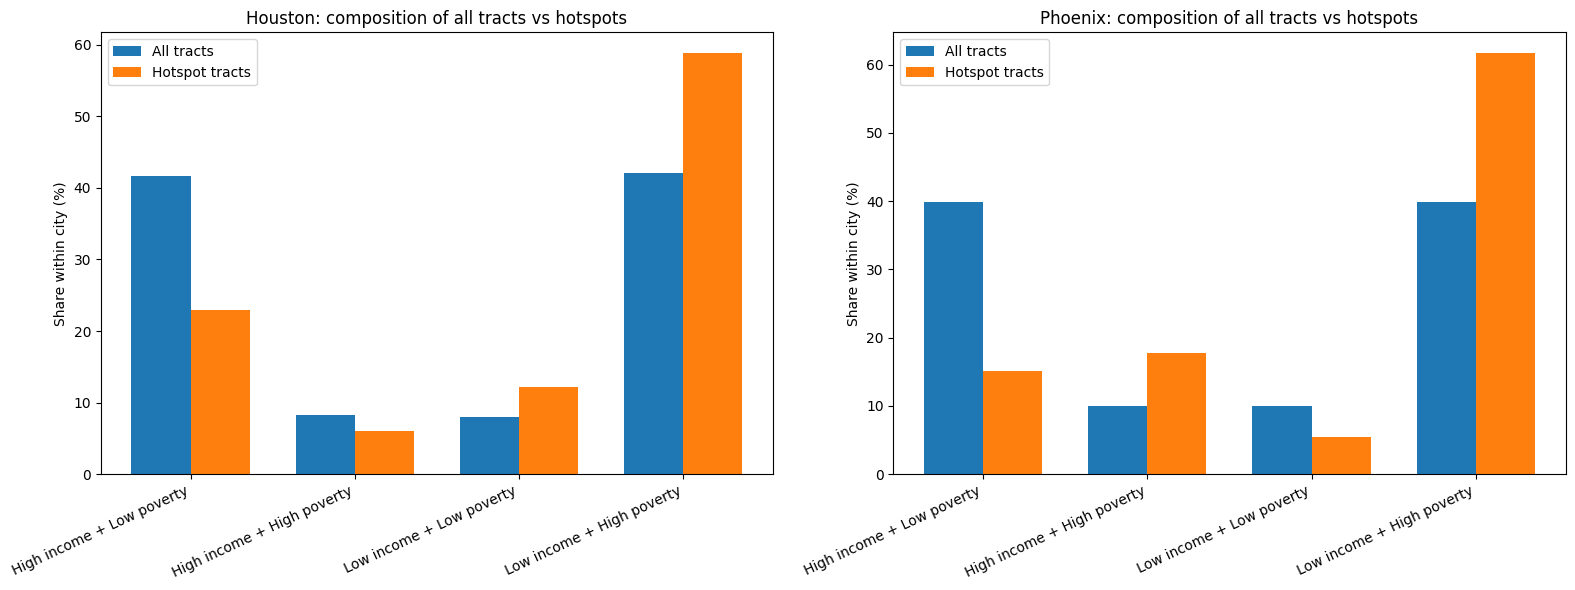

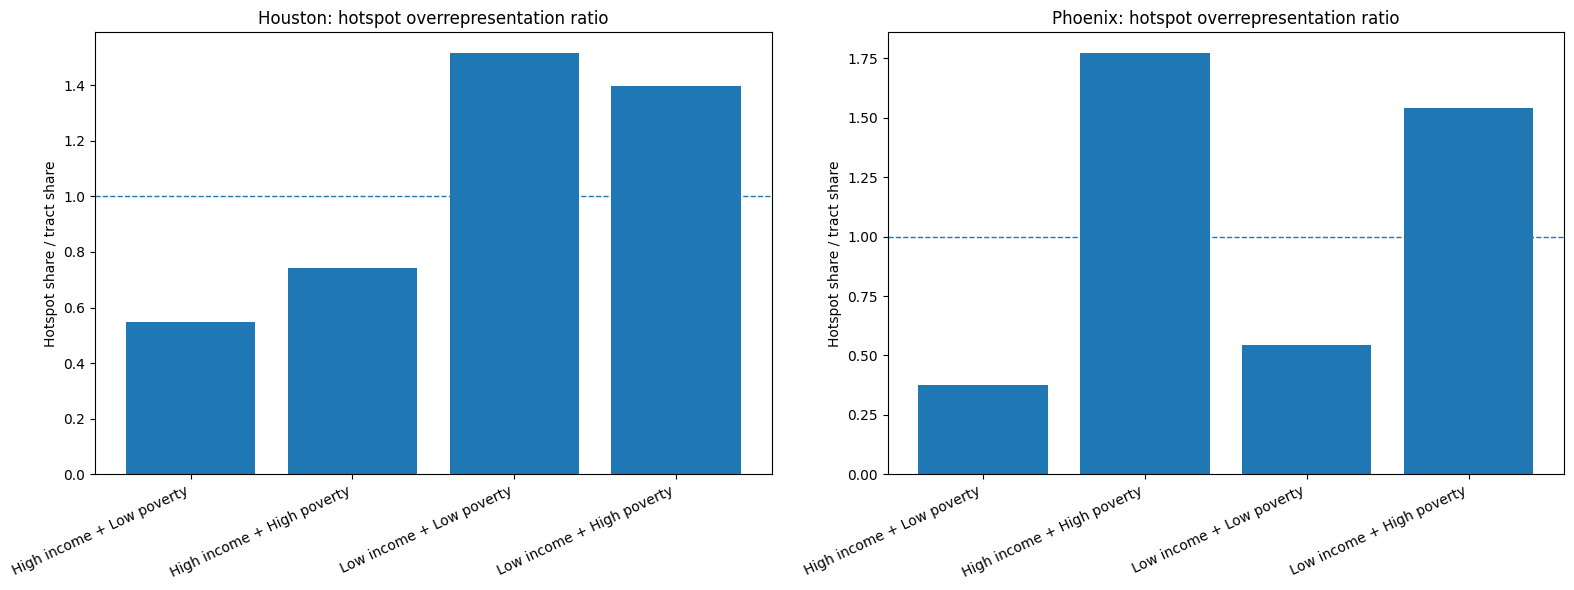


Block 9 file check:
/Users/yufeizhou/Desktop/heat-exposure-compare/figures/pilot/hotspot_composition_compare.png -> True
/Users/yufeizhou/Desktop/heat-exposure-compare/figures/pilot/hotspot_overrepresentation_ratio.png -> True


In [13]:
# =========================================================
# Block 9: hotspot composition and overrepresentation figures
# =========================================================

cities = ["Houston", "Phoenix"]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, city in zip(axes, cities):
    tmp = comp_compare[comp_compare["city"] == city].copy()
    tmp = tmp.sort_values("inequity_group")

    x = np.arange(len(tmp))
    width = 0.36

    ax.bar(x - width/2, tmp["share_tracts_pct"], width=width, label="All tracts")
    ax.bar(x + width/2, tmp["share_hotspots_pct"], width=width, label="Hotspot tracts")

    ax.set_title(f"{city}: composition of all tracts vs hotspots")
    ax.set_ylabel("Share within city (%)")
    ax.set_xticks(x)
    ax.set_xticklabels(tmp["inequity_group"], rotation=25, ha="right")
    ax.legend()

plt.tight_layout()
composition_fig_out = figure_dir / "hotspot_composition_compare.png"
plt.savefig(composition_fig_out, dpi=300, bbox_inches="tight")
plt.show()

# ---- overrepresentation ratio figure
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, city in zip(axes, cities):
    tmp = comp_compare[comp_compare["city"] == city].copy()
    tmp = tmp.sort_values("inequity_group")

    x = np.arange(len(tmp))
    ax.bar(x, tmp["overrep_ratio"])
    ax.axhline(1.0, linestyle="--", linewidth=1)

    ax.set_title(f"{city}: hotspot overrepresentation ratio")
    ax.set_ylabel("Hotspot share / tract share")
    ax.set_xticks(x)
    ax.set_xticklabels(tmp["inequity_group"], rotation=25, ha="right")

plt.tight_layout()
overrep_fig_out = figure_dir / "hotspot_overrepresentation_ratio.png"
plt.savefig(overrep_fig_out, dpi=300, bbox_inches="tight")
plt.show()

print("\nBlock 9 file check:")
for p in [composition_fig_out, overrep_fig_out]:
    print(p, "->", p.exists())

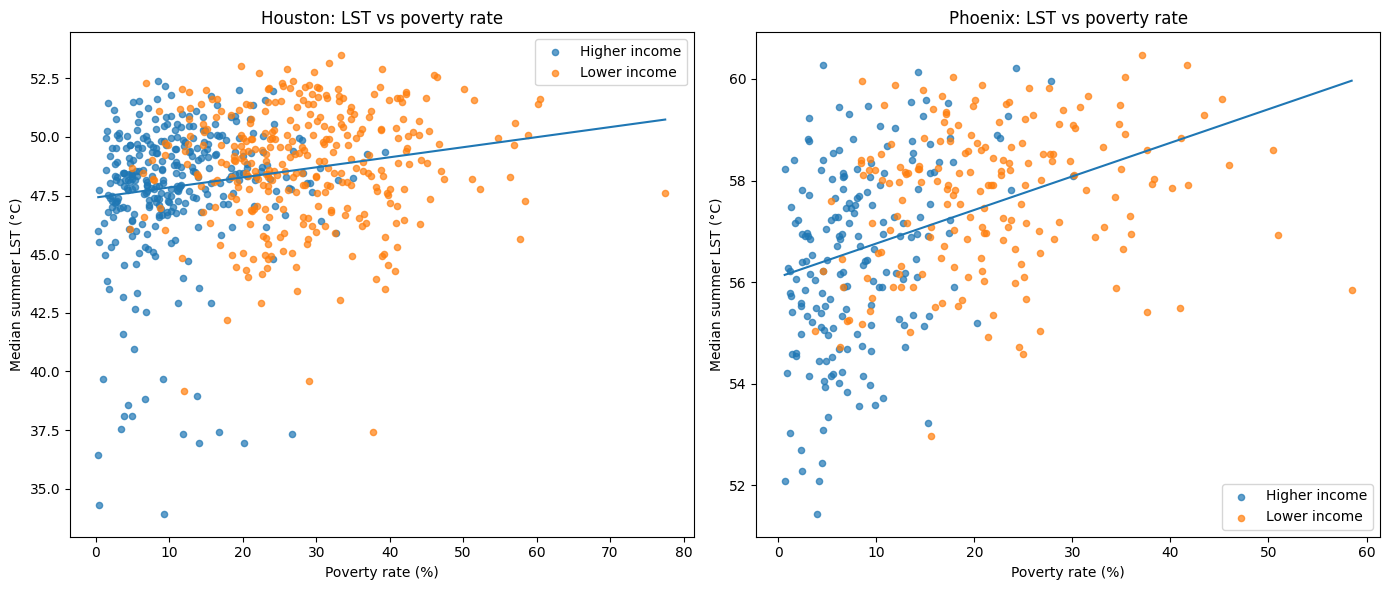

,city,n,slope_c_per_pct_poverty,intercept,corr,median_lst_c,median_poverty_pct
0,Houston,645,0.042870,47.417666,0.198661,48.513372,18.770479
1,Phoenix,368,0.066109,56.098989,0.400824,57.217789,12.944532



Block 10 file check:
/Users/yufeizhou/Desktop/heat-exposure-compare/figures/pilot/lst_vs_poverty_scatter.png -> True
/Users/yufeizhou/Desktop/heat-exposure-compare/outputs/pilot/lst_vs_poverty_regression_qc.csv -> True


In [14]:
# =========================================================
# Block 10: LST vs poverty scatter with simple regression
# =========================================================

regression_rows = []

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for ax, city in zip(axes, ["Houston", "Phoenix"]):
    tmp = analysis_df[analysis_df["city"] == city].copy()
    tmp = tmp.dropna(subset=["poverty_rate", "lst_summer_median_c"])

    # split by low-income flag
    low_income_true = tmp[tmp["low_income_flag"] == True]
    low_income_false = tmp[tmp["low_income_flag"] == False]

    ax.scatter(
        low_income_false["poverty_rate"] * 100,
        low_income_false["lst_summer_median_c"],
        s=20,
        alpha=0.7,
        label="Higher income"
    )
    ax.scatter(
        low_income_true["poverty_rate"] * 100,
        low_income_true["lst_summer_median_c"],
        s=20,
        alpha=0.7,
        label="Lower income"
    )

    # simple linear fit
    x = (tmp["poverty_rate"] * 100).to_numpy()
    y = tmp["lst_summer_median_c"].to_numpy()

    if len(tmp) >= 2:
        slope, intercept = np.polyfit(x, y, 1)
        xline = np.linspace(x.min(), x.max(), 100)
        yline = slope * xline + intercept
        ax.plot(xline, yline, linewidth=1.5)

        corr = np.corrcoef(x, y)[0, 1]
    else:
        slope, intercept, corr = np.nan, np.nan, np.nan

    regression_rows.append({
        "city": city,
        "n": len(tmp),
        "slope_c_per_pct_poverty": slope,
        "intercept": intercept,
        "corr": corr,
        "median_lst_c": np.median(y) if len(y) > 0 else np.nan,
        "median_poverty_pct": np.median(x) if len(x) > 0 else np.nan,
    })

    ax.set_title(f"{city}: LST vs poverty rate")
    ax.set_xlabel("Poverty rate (%)")
    ax.set_ylabel("Median summer LST (°C)")
    ax.legend()

plt.tight_layout()
scatter_fig_out = figure_dir / "lst_vs_poverty_scatter.png"
plt.savefig(scatter_fig_out, dpi=300, bbox_inches="tight")
plt.show()

regression_qc = pd.DataFrame(regression_rows)
display(regression_qc)

regression_qc_out = output_dir / "lst_vs_poverty_regression_qc.csv"
regression_qc.to_csv(regression_qc_out, index=False)

print("\nBlock 10 file check:")
for p in [scatter_fig_out, regression_qc_out]:
    print(p, "->", p.exists())

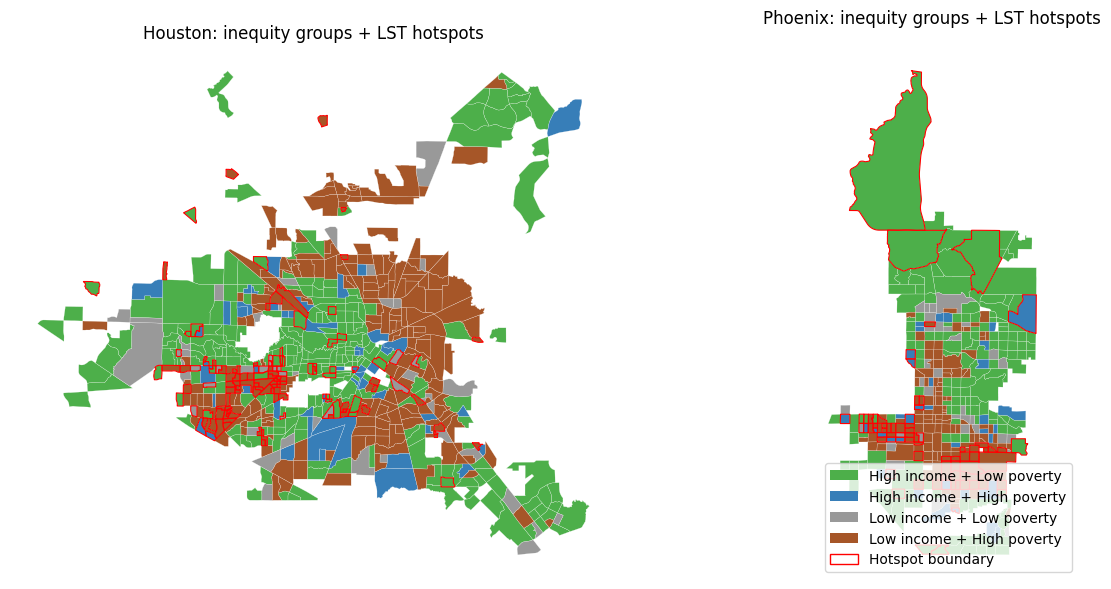


Block 11 file check:
/Users/yufeizhou/Desktop/heat-exposure-compare/figures/pilot/inequity_group_hotspot_overlay.png -> True


In [15]:
# =========================================================
# Block 11: map inequity groups with hotspot overlays
# =========================================================

from matplotlib.patches import Patch

group_colors = {
    "High income + Low poverty": "#4daf4a",
    "High income + High poverty": "#377eb8",
    "Low income + Low poverty": "#999999",
    "Low income + High poverty": "#a65628",
}

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for ax, gdf, city in zip(axes, [houston_hot, phoenix_hot], ["Houston", "Phoenix"]):
    tmp = gdf.copy()
    tmp = tmp[tmp["inequity_group"].isin(group_colors.keys())].copy()

    for group, color in group_colors.items():
        sub = tmp[tmp["inequity_group"] == group]
        if len(sub) > 0:
            sub.plot(ax=ax, color=color, edgecolor="white", linewidth=0.15)

    # hotspot overlay
    hotspot_sub = tmp[tmp["lst_hotspot_top20"] == True]
    if len(hotspot_sub) > 0:
        hotspot_sub.boundary.plot(ax=ax, color="red", linewidth=0.8)

    ax.set_title(f"{city}: inequity groups + LST hotspots")
    ax.set_axis_off()

legend_handles = [Patch(facecolor=c, edgecolor="none", label=g) for g, c in group_colors.items()]
legend_handles.append(Patch(facecolor="none", edgecolor="red", label="Hotspot boundary"))

axes[1].legend(handles=legend_handles, loc="lower left", frameon=True)

plt.tight_layout()
overlay_map_out = figure_dir / "inequity_group_hotspot_overlay.png"
plt.savefig(overlay_map_out, dpi=300, bbox_inches="tight")
plt.show()

print("\nBlock 11 file check:")
print(overlay_map_out, "->", overlay_map_out.exists())

In [16]:
from pathlib import Path
import pandas as pd
import geopandas as gpd
import numpy as np
import matplotlib.pyplot as plt

# =========================================================
# Block 12: RQ1-only city inequality metrics
# =========================================================

project_root = Path.cwd().resolve().parent
data_processed = project_root / "data_processed"
output_dir = project_root / "outputs" / "pilot"
figure_dir = project_root / "figures" / "pilot"

houston_hot_path = data_processed / "houston" / "houston_master_with_lst_hotspot.gpkg"
phoenix_hot_path = data_processed / "phoenix" / "phoenix_master_with_lst_hotspot.gpkg"

houston_hot = gpd.read_file(houston_hot_path, layer="tracts")
phoenix_hot = gpd.read_file(phoenix_hot_path, layer="tracts")

houston_hot["city"] = "Houston"
phoenix_hot["city"] = "Phoenix"

# ---- helper
def compute_city_inequality_metrics(gdf: gpd.GeoDataFrame, city_name: str) -> dict:
    tmp = gdf.copy()

    # keep only rows with valid LST
    tmp = tmp[tmp["lst_summer_median_c"].notna()].copy()

    x = tmp["lst_summer_median_c"].to_numpy()

    # quantiles
    p10 = np.nanpercentile(x, 10)
    p25 = np.nanpercentile(x, 25)
    p50 = np.nanpercentile(x, 50)
    p75 = np.nanpercentile(x, 75)
    p90 = np.nanpercentile(x, 90)
    p95 = np.nanpercentile(x, 95)

    # sd / cv
    mean_lst = np.nanmean(x)
    sd_lst = np.nanstd(x, ddof=1)
    cv_lst = sd_lst / mean_lst if mean_lst not in [0, np.nan] else np.nan

    # hotspot concentration metrics
    hotspot = tmp[tmp["lst_hotspot_top20"] == True].copy()

    total_area = tmp["area_km2"].sum(skipna=True)
    hotspot_area = hotspot["area_km2"].sum(skipna=True)

    if "total_population_clean" in tmp.columns:
        total_pop = tmp["total_population_clean"].sum(skipna=True)
        hotspot_pop = hotspot["total_population_clean"].sum(skipna=True)
    else:
        total_pop = np.nan
        hotspot_pop = np.nan

    return {
        "city": city_name,
        "tract_count": len(tmp),
        "median_lst_c": p50,
        "mean_lst_c": mean_lst,
        "sd_lst_c": sd_lst,
        "cv_lst": cv_lst,
        "p10_lst_c": p10,
        "p25_lst_c": p25,
        "p50_lst_c": p50,
        "p75_lst_c": p75,
        "p90_lst_c": p90,
        "p95_lst_c": p95,
        "iqr_lst_c": p75 - p25,
        "p90_minus_p10_c": p90 - p10,
        "p95_minus_p50_c": p95 - p50,
        "hotspot_cut_top20_c": float(tmp["lst_hotspot_cut_top20_c"].iloc[0]) if "lst_hotspot_cut_top20_c" in tmp.columns else np.nan,
        "hotspot_tract_count": int(tmp["lst_hotspot_top20"].sum()) if "lst_hotspot_top20" in tmp.columns else np.nan,
        "hotspot_area_share_pct": (hotspot_area / total_area * 100) if total_area > 0 else np.nan,
        "hotspot_population_share_pct": (hotspot_pop / total_pop * 100) if total_pop > 0 else np.nan,
    }

rq1_metrics = pd.DataFrame([
    compute_city_inequality_metrics(houston_hot, "Houston"),
    compute_city_inequality_metrics(phoenix_hot, "Phoenix"),
])

print("RQ1 city inequality metrics:")
display(rq1_metrics)

# ---- long-format table for cleaner plotting later
rq1_long = pd.DataFrame([
    {"city": row["city"], "metric": "Median LST", "value": row["median_lst_c"]} for _, row in rq1_metrics.iterrows()
] + [
    {"city": row["city"], "metric": "IQR", "value": row["iqr_lst_c"]} for _, row in rq1_metrics.iterrows()
] + [
    {"city": row["city"], "metric": "P90 - P10", "value": row["p90_minus_p10_c"]} for _, row in rq1_metrics.iterrows()
] + [
    {"city": row["city"], "metric": "P95 - P50", "value": row["p95_minus_p50_c"]} for _, row in rq1_metrics.iterrows()
] + [
    {"city": row["city"], "metric": "CV", "value": row["cv_lst"]} for _, row in rq1_metrics.iterrows()
] + [
    {"city": row["city"], "metric": "Hotspot area share (%)", "value": row["hotspot_area_share_pct"]} for _, row in rq1_metrics.iterrows()
] + [
    {"city": row["city"], "metric": "Hotspot population share (%)", "value": row["hotspot_population_share_pct"]} for _, row in rq1_metrics.iterrows()
])

print("\nRQ1 long-format metrics:")
display(rq1_long)

# ---- save
rq1_metrics_out = output_dir / "rq1_city_inequality_metrics.csv"
rq1_long_out = output_dir / "rq1_city_inequality_metrics_long.csv"

rq1_metrics.to_csv(rq1_metrics_out, index=False)
rq1_long.to_csv(rq1_long_out, index=False)

print("\nBlock 12 file check:")
for p in [rq1_metrics_out, rq1_long_out]:
    print(p, "->", p.exists())

RQ1 city inequality metrics:


,city,tract_count,median_lst_c,mean_lst_c,sd_lst_c,cv_lst,p10_lst_c,p25_lst_c,p50_lst_c,p75_lst_c,p90_lst_c,p95_lst_c,iqr_lst_c,p90_minus_p10_c,p95_minus_p50_c,hotspot_cut_top20_c,hotspot_tract_count,hotspot_area_share_pct,hotspot_population_share_pct
0,Houston,654,48.531293,48.277537,2.792195,0.057836,45.235969,47.156771,48.531293,49.983998,51.379801,51.821461,2.827227,6.143831,3.290168,50.314631,131,7.153203,17.259310
1,Phoenix,373,57.217040,57.089466,1.739173,0.030464,54.725652,55.907969,57.217040,58.388696,59.259548,59.562390,2.480727,4.533897,2.345350,58.607177,75,34.181579,19.470399



RQ1 long-format metrics:


,city,metric,value
0,Houston,Median LST,48.531293
1,Phoenix,Median LST,57.217040
2,Houston,IQR,2.827227
3,Phoenix,IQR,2.480727
4,Houston,P90 - P10,6.143831
5,Phoenix,P90 - P10,4.533897
6,Houston,P95 - P50,3.290168
7,Phoenix,P95 - P50,2.345350
8,Houston,CV,0.057836
9,Phoenix,CV,0.030464



Block 12 file check:
/Users/yufeizhou/Desktop/heat-exposure-compare/outputs/pilot/rq1_city_inequality_metrics.csv -> True
/Users/yufeizhou/Desktop/heat-exposure-compare/outputs/pilot/rq1_city_inequality_metrics_long.csv -> True


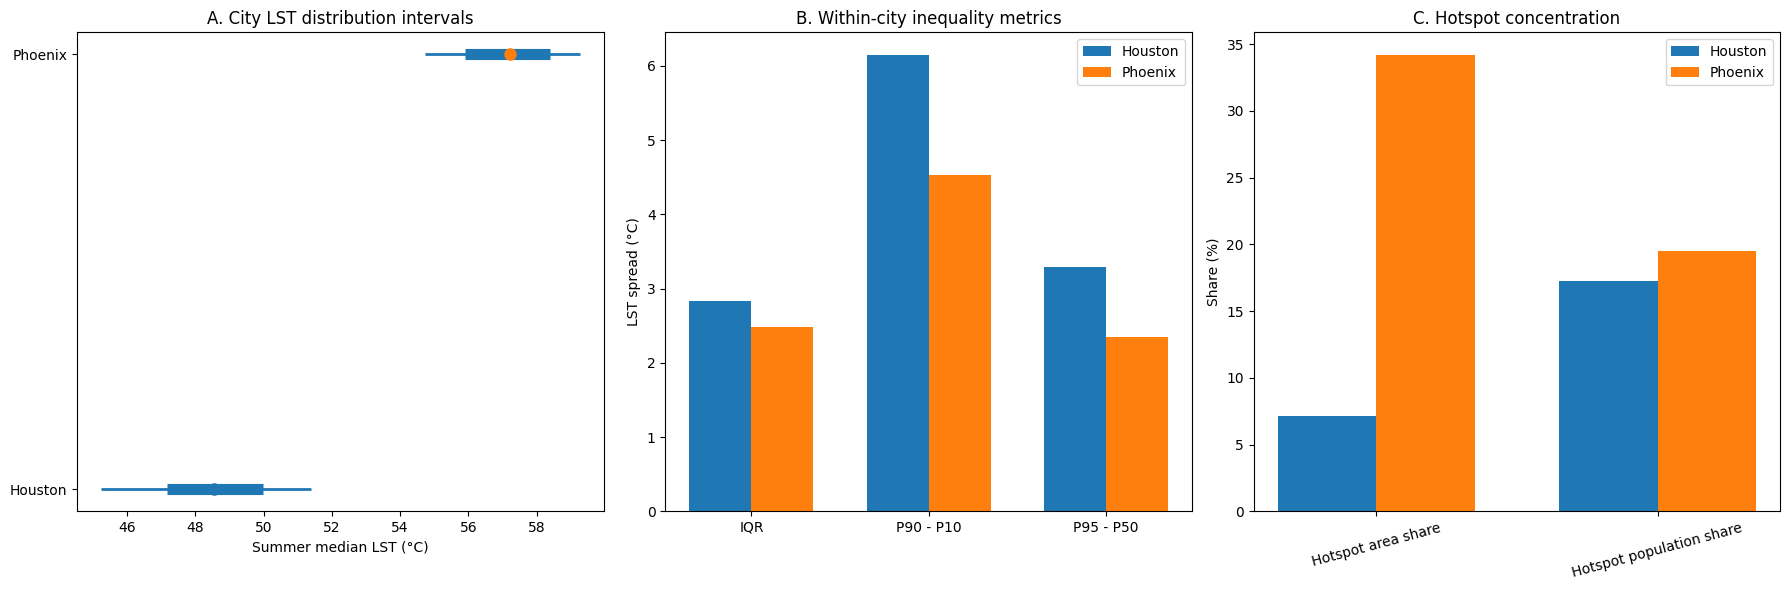

Quick RQ1 interpretation:
Houston: median=48.53 °C, IQR=2.83, P90-P10=6.14, CV=0.058, hotspot area share=7.15%, hotspot population share=17.26%
Phoenix: median=57.22 °C, IQR=2.48, P90-P10=4.53, CV=0.030, hotspot area share=34.18%, hotspot population share=19.47%

Block 13 file check:
/Users/yufeizhou/Desktop/heat-exposure-compare/figures/pilot/rq1_city_inequality_compare.png -> True


In [17]:
# =========================================================
# Block 13: paper-style RQ1 comparison figure
# =========================================================

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# -------------------------
# Panel A: interval plot
# -------------------------
cities = rq1_metrics["city"].tolist()
ypos = np.arange(len(cities))

for i, row in rq1_metrics.iterrows():
    # p10-p90 thin line
    axes[0].hlines(
        y=i,
        xmin=row["p10_lst_c"],
        xmax=row["p90_lst_c"],
        linewidth=2
    )
    # p25-p75 thick line
    axes[0].hlines(
        y=i,
        xmin=row["p25_lst_c"],
        xmax=row["p75_lst_c"],
        linewidth=8
    )
    # median point
    axes[0].plot(
        row["p50_lst_c"],
        i,
        marker="o",
        markersize=8
    )

axes[0].set_yticks(ypos)
axes[0].set_yticklabels(cities)
axes[0].set_xlabel("Summer median LST (°C)")
axes[0].set_title("A. City LST distribution intervals")

# -------------------------
# Panel B: inequality metrics
# -------------------------
ineq_metrics = ["iqr_lst_c", "p90_minus_p10_c", "p95_minus_p50_c"]
ineq_labels = ["IQR", "P90 - P10", "P95 - P50"]

x = np.arange(len(ineq_metrics))
width = 0.35

houston_vals = rq1_metrics[rq1_metrics["city"] == "Houston"][ineq_metrics].iloc[0].to_list()
phoenix_vals = rq1_metrics[rq1_metrics["city"] == "Phoenix"][ineq_metrics].iloc[0].to_list()

axes[1].bar(x - width/2, houston_vals, width=width, label="Houston")
axes[1].bar(x + width/2, phoenix_vals, width=width, label="Phoenix")
axes[1].set_xticks(x)
axes[1].set_xticklabels(ineq_labels)
axes[1].set_ylabel("LST spread (°C)")
axes[1].set_title("B. Within-city inequality metrics")
axes[1].legend()

# -------------------------
# Panel C: hotspot concentration
# -------------------------
conc_metrics = ["hotspot_area_share_pct", "hotspot_population_share_pct"]
conc_labels = ["Hotspot area share", "Hotspot population share"]

x2 = np.arange(len(conc_metrics))
houston_conc = rq1_metrics[rq1_metrics["city"] == "Houston"][conc_metrics].iloc[0].to_list()
phoenix_conc = rq1_metrics[rq1_metrics["city"] == "Phoenix"][conc_metrics].iloc[0].to_list()

axes[2].bar(x2 - width/2, houston_conc, width=width, label="Houston")
axes[2].bar(x2 + width/2, phoenix_conc, width=width, label="Phoenix")
axes[2].set_xticks(x2)
axes[2].set_xticklabels(conc_labels, rotation=15)
axes[2].set_ylabel("Share (%)")
axes[2].set_title("C. Hotspot concentration")
axes[2].legend()

plt.tight_layout()
rq1_compare_fig_out = figure_dir / "rq1_city_inequality_compare.png"
plt.savefig(rq1_compare_fig_out, dpi=300, bbox_inches="tight")
plt.show()

# ---- quick interpretation
print("Quick RQ1 interpretation:")
for _, row in rq1_metrics.iterrows():
    print(
        f"{row['city']}: median={row['median_lst_c']:.2f} °C, "
        f"IQR={row['iqr_lst_c']:.2f}, "
        f"P90-P10={row['p90_minus_p10_c']:.2f}, "
        f"CV={row['cv_lst']:.3f}, "
        f"hotspot area share={row['hotspot_area_share_pct']:.2f}%, "
        f"hotspot population share={row['hotspot_population_share_pct']:.2f}%"
    )

print("\nBlock 13 file check:")
print(rq1_compare_fig_out, "->", rq1_compare_fig_out.exists())

In [18]:
from pathlib import Path
import geopandas as gpd
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

# =========================================================
# Publication-style figure prep
# =========================================================

project_root = Path.cwd().resolve().parent
data_processed = project_root / "data_processed"
figure_dir = project_root / "figures" / "pilot"
output_dir = project_root / "outputs" / "pilot"

houston_path = data_processed / "houston" / "houston_master_with_lst_hotspot.gpkg"
phoenix_path = data_processed / "phoenix" / "phoenix_master_with_lst_hotspot.gpkg"

houston = gpd.read_file(houston_path, layer="tracts")
phoenix = gpd.read_file(phoenix_path, layer="tracts")

houston["city"] = "Houston"
phoenix["city"] = "Phoenix"

# ---- make anomaly
houston["lst_anomaly_c"] = houston["lst_summer_median_c"] - houston["lst_summer_median_c"].median()
phoenix["lst_anomaly_c"] = phoenix["lst_summer_median_c"] - phoenix["lst_summer_median_c"].median()

# ---- common class breaks for absolute LST
all_lst = pd.concat([
    houston["lst_summer_median_c"],
    phoenix["lst_summer_median_c"]
], ignore_index=True).dropna()

lst_breaks = np.quantile(all_lst, [0, 0.2, 0.4, 0.6, 0.8, 1.0])
lst_breaks = np.unique(np.round(lst_breaks, 2))

# make sure there are enough unique bin edges
if len(lst_breaks) < 6:
    lst_breaks = np.linspace(all_lst.min(), all_lst.max(), 6)
    lst_breaks = np.round(lst_breaks, 2)

# ---- symmetric class breaks for anomaly
all_anom = pd.concat([
    houston["lst_anomaly_c"],
    phoenix["lst_anomaly_c"]
], ignore_index=True).dropna()

anom_abs = max(abs(all_anom.min()), abs(all_anom.max()))
anom_breaks = np.array([
    -anom_abs,
    -anom_abs * 0.5,
    -anom_abs * 0.15,
    anom_abs * 0.15,
    anom_abs * 0.5,
    anom_abs
])
anom_breaks = np.round(anom_breaks, 2)

# ---- classify function
def classify_series(series, breaks, labels):
    s = pd.cut(
        series,
        bins=breaks,
        labels=labels,
        include_lowest=True,
        duplicates="drop"
    )
    return s

lst_labels = [
    f"{lst_breaks[i]:.1f}–{lst_breaks[i+1]:.1f}"
    for i in range(len(lst_breaks)-1)
]

anom_labels = [
    f"{anom_breaks[i]:.1f}–{anom_breaks[i+1]:.1f}"
    for i in range(len(anom_breaks)-1)
]

houston["lst_class"] = classify_series(houston["lst_summer_median_c"], lst_breaks, lst_labels)
phoenix["lst_class"] = classify_series(phoenix["lst_summer_median_c"], lst_breaks, lst_labels)

houston["anom_class"] = classify_series(houston["lst_anomaly_c"], anom_breaks, anom_labels)
phoenix["anom_class"] = classify_series(phoenix["lst_anomaly_c"], anom_breaks, anom_labels)

# ---- define publication colors
lst_colors = ["#fff7bc", "#fec44f", "#fe9929", "#ec7014", "#cc4c02"]
anom_colors = ["#2166ac", "#67a9cf", "#f7f7f7", "#f4a582", "#b2182b"]

# ---- quick check table
pub_map_qc = pd.DataFrame({
    "city": ["Houston", "Phoenix"],
    "median_lst_c": [
        houston["lst_summer_median_c"].median(),
        phoenix["lst_summer_median_c"].median()
    ],
    "min_lst_c": [
        houston["lst_summer_median_c"].min(),
        phoenix["lst_summer_median_c"].min()
    ],
    "max_lst_c": [
        houston["lst_summer_median_c"].max(),
        phoenix["lst_summer_median_c"].max()
    ],
    "min_anom_c": [
        houston["lst_anomaly_c"].min(),
        phoenix["lst_anomaly_c"].min()
    ],
    "max_anom_c": [
        houston["lst_anomaly_c"].max(),
        phoenix["lst_anomaly_c"].max()
    ]
})

print("Publication map QC:")
display(pub_map_qc)

print("LST breaks:", lst_breaks)
print("Anomaly breaks:", anom_breaks)

Publication map QC:


,city,median_lst_c,min_lst_c,max_lst_c,min_anom_c,max_anom_c
0,Houston,48.531293,33.932659,53.481081,-14.598635,4.949788
1,Phoenix,57.217040,51.440967,60.466231,-5.776073,3.249191


LST breaks: [33.93 47.69 49.34 51.71 56.97 60.47]
Anomaly breaks: [-14.6   -7.3   -2.19   2.19   7.3   14.6 ]


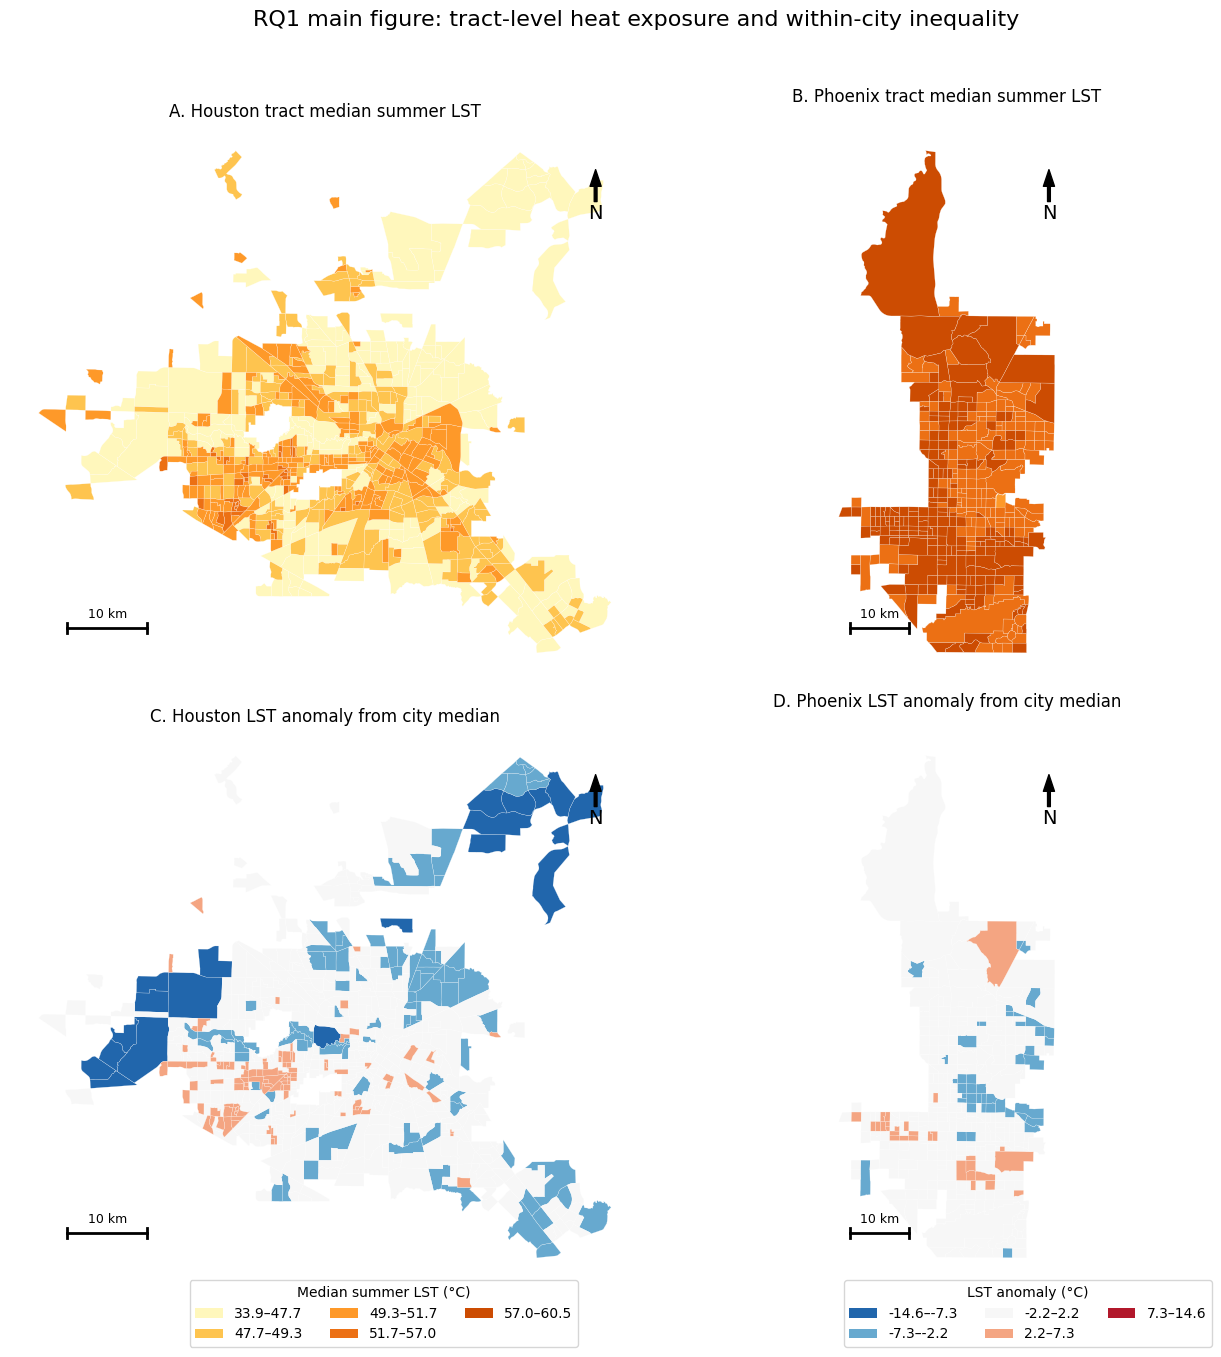


Block map-panel file check:
/Users/yufeizhou/Desktop/heat-exposure-compare/figures/pilot/rq1_main_map_panel.png -> True


In [19]:
# =========================================================
# Figure 1: publication-style 2x2 map panel
# A Houston absolute LST
# B Phoenix absolute LST
# C Houston anomaly
# D Phoenix anomaly
# =========================================================

def add_north_arrow(ax, x=0.93, y=0.92, size=14):
    ax.annotate(
        "N",
        xy=(x, y),
        xytext=(x, y-0.08),
        arrowprops=dict(facecolor="black", width=2, headwidth=8),
        ha="center",
        va="center",
        fontsize=size,
        xycoords=ax.transAxes
    )

def add_scalebar(ax, gdf, length_km=10):
    minx, miny, maxx, maxy = gdf.total_bounds
    x0 = minx + 0.05 * (maxx - minx)
    y0 = miny + 0.05 * (maxy - miny)
    length_m = length_km * 1000

    ax.plot([x0, x0 + length_m], [y0, y0], color="black", linewidth=2)
    ax.plot([x0, x0], [y0 - 0.01*(maxy-miny), y0 + 0.01*(maxy-miny)], color="black", linewidth=2)
    ax.plot([x0 + length_m, x0 + length_m], [y0 - 0.01*(maxy-miny), y0 + 0.01*(maxy-miny)], color="black", linewidth=2)
    ax.text(x0 + length_m/2, y0 + 0.02*(maxy-miny), f"{length_km} km", ha="center", fontsize=9)

def plot_categorical_map(ax, gdf, class_col, categories, colors, title):
    for cat, color in zip(categories, colors):
        sub = gdf[gdf[class_col] == cat]
        if len(sub) > 0:
            sub.plot(ax=ax, color=color, edgecolor="white", linewidth=0.15)
    ax.set_title(title, fontsize=12)
    ax.axis("off")
    add_north_arrow(ax)
    add_scalebar(ax, gdf, length_km=10)

fig, axes = plt.subplots(2, 2, figsize=(14, 14))

plot_categorical_map(
    axes[0, 0], houston, "lst_class", lst_labels, lst_colors,
    "A. Houston tract median summer LST"
)

plot_categorical_map(
    axes[0, 1], phoenix, "lst_class", lst_labels, lst_colors,
    "B. Phoenix tract median summer LST"
)

plot_categorical_map(
    axes[1, 0], houston, "anom_class", anom_labels, anom_colors,
    "C. Houston LST anomaly from city median"
)

plot_categorical_map(
    axes[1, 1], phoenix, "anom_class", anom_labels, anom_colors,
    "D. Phoenix LST anomaly from city median"
)

# legends
lst_handles = [Patch(facecolor=c, edgecolor="none", label=l) for c, l in zip(lst_colors, lst_labels)]
anom_handles = [Patch(facecolor=c, edgecolor="none", label=l) for c, l in zip(anom_colors, anom_labels)]

fig.legend(
    handles=lst_handles,
    loc="lower center",
    bbox_to_anchor=(0.32, 0.02),
    ncol=3,
    frameon=True,
    title="Median summer LST (°C)"
)

fig.legend(
    handles=anom_handles,
    loc="lower center",
    bbox_to_anchor=(0.78, 0.02),
    ncol=3,
    frameon=True,
    title="LST anomaly (°C)"
)

plt.suptitle("RQ1 main figure: tract-level heat exposure and within-city inequality", fontsize=16, y=0.98)
plt.tight_layout(rect=[0, 0.06, 1, 0.96])

rq1_map_panel_out = figure_dir / "rq1_main_map_panel.png"
plt.savefig(rq1_map_panel_out, dpi=300, bbox_inches="tight")
plt.show()

print("\nBlock map-panel file check:")
print(rq1_map_panel_out, "->", rq1_map_panel_out.exists())

In [21]:
import sys
print(sys.executable)

import libpysal
import esda

print("libpysal ok")
print("esda ok")

/Users/yufeizhou/Desktop/heat-exposure-compare/.venv/bin/python
libpysal ok
esda ok


/var/folders/6w/9b3gk7f16xx8v8xscr34djk00000gn/T/ipykernel_73634/2456781698.py:14: FutureWarning: `use_index` defaults to False but will default to True in future. Set True/False directly to control this behavior and silence this warning
  w = Queen.from_dataframe(tmp)
/Users/yufeizhou/Desktop/heat-exposure-compare/.venv/lib/python3.12/site-packages/libpysal/weights/contiguity.py:347: UserWarning: The weights matrix is not fully connected: 
 There are 10 disconnected components.
 There are 8 islands with ids: 70, 110, 123, 213, 424, 468, 513, 636.
  W.__init__(self, neighbors, ids=ids, **kw)
/Users/yufeizhou/Desktop/heat-exposure-compare/.venv/lib/python3.12/site-packages/esda/moran.py:1354: RuntimeWarning: invalid value encountered in divide
  self.z_sim = (self.Is - self.EI_sim) / self.seI_sim
/var/folders/6w/9b3gk7f16xx8v8xscr34djk00000gn/T/ipykernel_73634/2456781698.py:14: FutureWarning: `use_index` defaults to False but will default to True in future. Set True/False directly to co

('WARNING: ', 70, ' is an island (no neighbors)')
('WARNING: ', 110, ' is an island (no neighbors)')
('WARNING: ', 123, ' is an island (no neighbors)')
('WARNING: ', 213, ' is an island (no neighbors)')
('WARNING: ', 424, ' is an island (no neighbors)')
('WARNING: ', 468, ' is an island (no neighbors)')
('WARNING: ', 513, ' is an island (no neighbors)')
('WARNING: ', 636, ' is an island (no neighbors)')


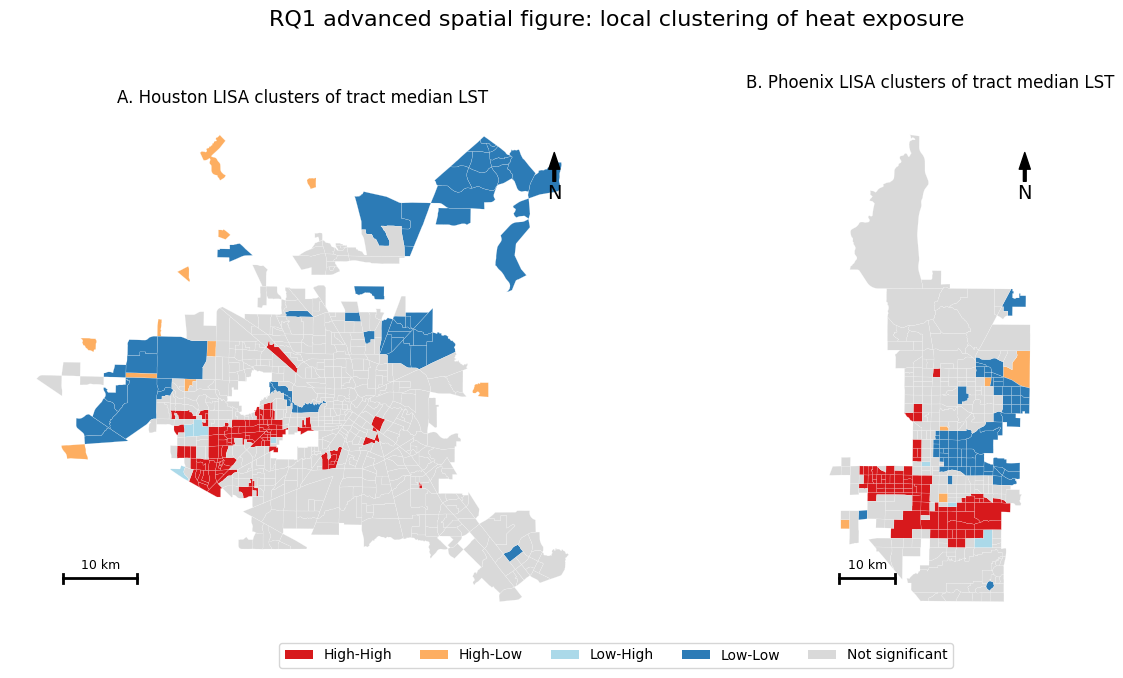

LISA QC:


,lisa_cluster,count,city
0,Not significant,483,Houston
1,High-High,101,Houston
2,Low-Low,55,Houston
3,High-Low,11,Houston
4,Low-High,4,Houston
5,Not significant,214,Phoenix
6,High-High,83,Phoenix
7,Low-Low,68,Phoenix
8,High-Low,5,Phoenix
9,Low-High,3,Phoenix



Block LISA file check:
/Users/yufeizhou/Desktop/heat-exposure-compare/figures/pilot/rq1_lisa_cluster_panel.png -> True
/Users/yufeizhou/Desktop/heat-exposure-compare/outputs/pilot/rq1_lisa_qc.csv -> True


In [22]:
# =========================================================
# Figure 2: LISA cluster maps for tract median summer LST
# =========================================================

from libpysal.weights import Queen
from esda.moran import Moran_Local

def make_lisa_map(gdf):
    tmp = gdf.copy()
    tmp = tmp[tmp["lst_summer_median_c"].notna()].copy()
    tmp = tmp[tmp.geometry.notna()].copy()
    tmp = tmp[tmp.geometry.is_valid].copy()

    w = Queen.from_dataframe(tmp)
    w.transform = "r"

    y = tmp["lst_summer_median_c"].values
    lisa = Moran_Local(y, w)

    tmp["lisa_p"] = lisa.p_sim
    tmp["lisa_q"] = lisa.q
    tmp["significant"] = tmp["lisa_p"] < 0.05

    tmp["lisa_cluster"] = "Not significant"
    tmp.loc[(tmp["significant"]) & (tmp["lisa_q"] == 1), "lisa_cluster"] = "High-High"
    tmp.loc[(tmp["significant"]) & (tmp["lisa_q"] == 2), "lisa_cluster"] = "Low-High"
    tmp.loc[(tmp["significant"]) & (tmp["lisa_q"] == 3), "lisa_cluster"] = "Low-Low"
    tmp.loc[(tmp["significant"]) & (tmp["lisa_q"] == 4), "lisa_cluster"] = "High-Low"

    return tmp

houston_lisa = make_lisa_map(houston)
phoenix_lisa = make_lisa_map(phoenix)

cluster_order = ["High-High", "High-Low", "Low-High", "Low-Low", "Not significant"]
cluster_colors = {
    "High-High": "#d7191c",
    "High-Low": "#fdae61",
    "Low-High": "#abd9e9",
    "Low-Low": "#2c7bb6",
    "Not significant": "#d9d9d9"
}

fig, axes = plt.subplots(1, 2, figsize=(14, 7))

for ax, gdf_plot, title in [
    (axes[0], houston_lisa, "A. Houston LISA clusters of tract median LST"),
    (axes[1], phoenix_lisa, "B. Phoenix LISA clusters of tract median LST")
]:
    for cat in cluster_order:
        sub = gdf_plot[gdf_plot["lisa_cluster"] == cat]
        if len(sub) > 0:
            sub.plot(ax=ax, color=cluster_colors[cat], edgecolor="white", linewidth=0.12)
    ax.set_title(title, fontsize=12)
    ax.axis("off")
    add_north_arrow(ax)
    add_scalebar(ax, gdf_plot, length_km=10)

handles = [Patch(facecolor=cluster_colors[c], edgecolor="none", label=c) for c in cluster_order]
fig.legend(handles=handles, loc="lower center", bbox_to_anchor=(0.5, 0.02), ncol=5, frameon=True)

plt.suptitle("RQ1 advanced spatial figure: local clustering of heat exposure", fontsize=16, y=0.97)
plt.tight_layout(rect=[0, 0.07, 1, 0.95])

rq1_lisa_panel_out = figure_dir / "rq1_lisa_cluster_panel.png"
plt.savefig(rq1_lisa_panel_out, dpi=300, bbox_inches="tight")
plt.show()

# QC
lisa_qc = pd.concat([
    houston_lisa["lisa_cluster"].value_counts(dropna=False).rename("count").reset_index().assign(city="Houston"),
    phoenix_lisa["lisa_cluster"].value_counts(dropna=False).rename("count").reset_index().assign(city="Phoenix")
], ignore_index=True).rename(columns={"index": "lisa_cluster"})

print("LISA QC:")
display(lisa_qc)

rq1_lisa_qc_out = output_dir / "rq1_lisa_qc.csv"
lisa_qc.to_csv(rq1_lisa_qc_out, index=False)

print("\nBlock LISA file check:")
for p in [rq1_lisa_panel_out, rq1_lisa_qc_out]:
    print(p, "->", p.exists())

In [24]:
# ============================================================
# Gi* FIXED VERSION - compute tract hot/cold spots from LST
# ============================================================

from pathlib import Path
import warnings
import numpy as np
import pandas as pd
import geopandas as gpd
from libpysal.weights import Queen
from esda.getisord import G_Local

# ---------- locate project root ----------
project_root = Path.cwd()
if not (project_root / "data_processed").exists():
    project_root = project_root.parent

data_processed = project_root / "data_processed"
output_dir = project_root / "outputs" / "pilot"
figure_dir = project_root / "figures" / "pilot"

# ---------- use the file that already has LST ----------
houston_path = data_processed / "houston" / "houston_master_with_lst_hotspot.gpkg"
phoenix_path = data_processed / "phoenix" / "phoenix_master_with_lst_hotspot.gpkg"

print("Houston input exists?", houston_path.exists())
print("Phoenix input exists?", phoenix_path.exists())

# ---------- helper ----------
def prepare_city_gdf(path, city_name):
    gdf = gpd.read_file(path).copy()

    # robust column detection
    if "lst_summer_median_c" in gdf.columns:
        value_col = "lst_summer_median_c"
    elif "median_lst_c" in gdf.columns:
        value_col = "median_lst_c"
    else:
        raise ValueError(
            f"{city_name}: cannot find LST column. Available columns:\n{list(gdf.columns)}"
        )

    gdf[value_col] = pd.to_numeric(gdf[value_col], errors="coerce")
    gdf = gdf.loc[gdf.geometry.notna() & gdf[value_col].notna()].copy()
    gdf["city"] = city_name

    return gdf, value_col

def add_gistar_clusters(gdf, value_col, permutations=999):
    gdf = gdf.copy()

    # suppress island warnings (not fatal)
    warnings.filterwarnings("ignore", message=".*is an island.*")
    warnings.filterwarnings("ignore", message=".*not fully connected.*")

    w = Queen.from_dataframe(gdf)
    w.transform = "B"

    y = gdf[value_col].to_numpy()
    gi = G_Local(y, w, star=True, permutations=permutations)

    gdf["gi_z"] = gi.Zs
    gdf["gi_p"] = gi.p_sim
    gdf["gi_sig"] = gdf["gi_p"] < 0.05
    gdf["gi_cluster"] = "Not significant"

    gdf.loc[(gdf["gi_z"] > 0) & (gdf["gi_p"] < 0.05), "gi_cluster"] = "Hot spot"
    gdf.loc[(gdf["gi_z"] < 0) & (gdf["gi_p"] < 0.05), "gi_cluster"] = "Cold spot"

    return gdf

# ---------- read ----------
houston_gi, houston_value_col = prepare_city_gdf(houston_path, "Houston")
phoenix_gi, phoenix_value_col = prepare_city_gdf(phoenix_path, "Phoenix")

print("Houston LST column used:", houston_value_col)
print("Phoenix LST column used:", phoenix_value_col)

# ---------- compute Gi* ----------
houston_gi = add_gistar_clusters(houston_gi, houston_value_col, permutations=999)
phoenix_gi = add_gistar_clusters(phoenix_gi, phoenix_value_col, permutations=999)

# ---------- save ----------
houston_gi_out = data_processed / "houston" / "houston_master_gistar.gpkg"
phoenix_gi_out = data_processed / "phoenix" / "phoenix_master_gistar.gpkg"

houston_gi.to_file(houston_gi_out, driver="GPKG")
phoenix_gi.to_file(phoenix_gi_out, driver="GPKG")

print("\nGi* compute finished:")
print("Houston Gi* rows:", len(houston_gi))
print("Phoenix Gi* rows:", len(phoenix_gi))
print(houston_gi_out, "->", houston_gi_out.exists())
print(phoenix_gi_out, "->", phoenix_gi_out.exists())

Houston input exists? True
Phoenix input exists? True
Houston LST column used: lst_summer_median_c
Phoenix LST column used: lst_summer_median_c


/var/folders/6w/9b3gk7f16xx8v8xscr34djk00000gn/T/ipykernel_73634/259098175.py:56: FutureWarning: `use_index` defaults to False but will default to True in future. Set True/False directly to control this behavior and silence this warning
  w = Queen.from_dataframe(gdf)



Gi* compute finished:
Houston Gi* rows: 654
Phoenix Gi* rows: 373
/Users/yufeizhou/Desktop/heat-exposure-compare/data_processed/houston/houston_master_gistar.gpkg -> True
/Users/yufeizhou/Desktop/heat-exposure-compare/data_processed/phoenix/phoenix_master_gistar.gpkg -> True


/Users/yufeizhou/Desktop/heat-exposure-compare/.venv/lib/python3.12/site-packages/esda/getisord.py:450: RuntimeWarning: divide by zero encountered in divide
  self.z_sim = (self.Gs - self.EG_sim) / self.seG_sim
/var/folders/6w/9b3gk7f16xx8v8xscr34djk00000gn/T/ipykernel_73634/259098175.py:56: FutureWarning: `use_index` defaults to False but will default to True in future. Set True/False directly to control this behavior and silence this warning
  w = Queen.from_dataframe(gdf)


,city,tract_count,hot_count,cold_count,not_significant_count,hot_share_pct,cold_share_pct,median_lst_c,mean_lst_c,max_gi_z,min_gi_z
0,Houston,654,123,54,477,18.807339,8.256881,48.531293,48.277537,1.451946,-5.074024
1,Phoenix,373,85,71,217,22.788204,19.034853,57.217040,57.089466,1.464634,-2.191605


,gi_cluster,count,city
0,Not significant,477,Houston
1,Hot spot,123,Houston
2,Cold spot,54,Houston
3,Not significant,217,Phoenix
4,Hot spot,85,Phoenix
5,Cold spot,71,Phoenix


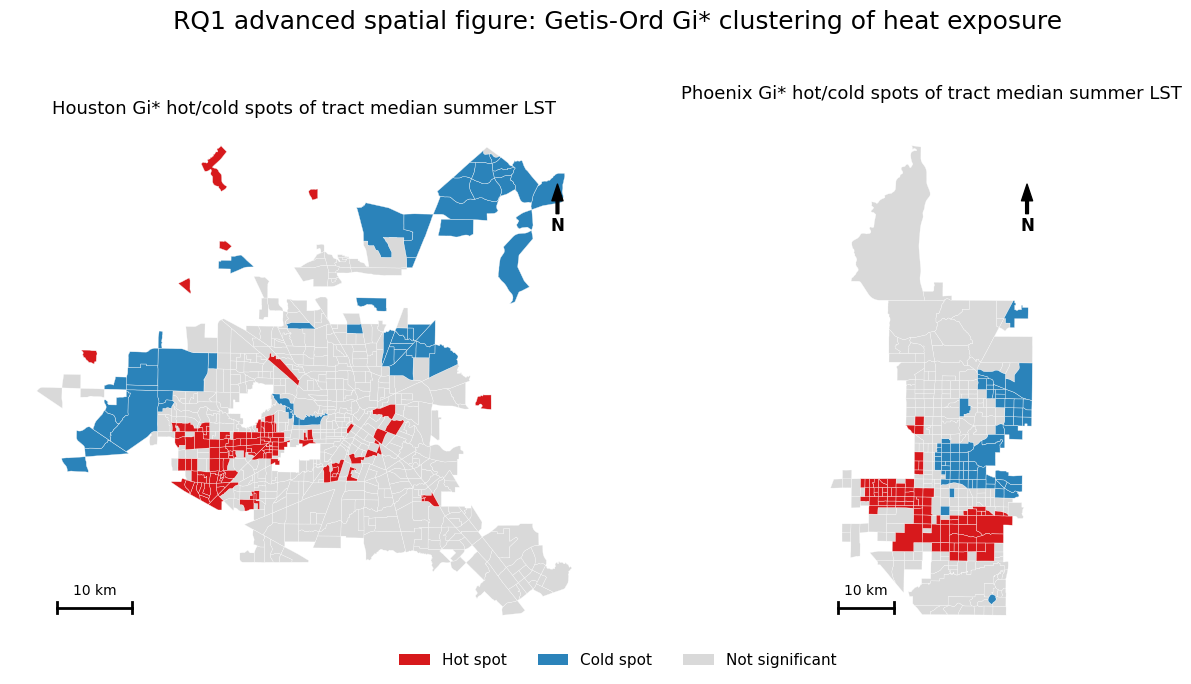


Gi* quick interpretation:
Houston: hot spots = 18.81%, cold spots = 8.26%, median LST = 48.53 °C
Phoenix: hot spots = 22.79%, cold spots = 19.03%, median LST = 57.22 °C

Block Gi* file check:
/Users/yufeizhou/Desktop/heat-exposure-compare/outputs/pilot/rq1_gistar_qc.csv -> True
/Users/yufeizhou/Desktop/heat-exposure-compare/outputs/pilot/rq1_gistar_cluster_counts.csv -> True
/Users/yufeizhou/Desktop/heat-exposure-compare/figures/pilot/rq1_gistar_panel.png -> True


In [25]:
# ============================================================
# Gi* FIXED VERSION - QC + teacher-ready figure
# ============================================================

import matplotlib.pyplot as plt
from matplotlib.patches import Patch

def add_north_arrow(ax, x=0.93, y=0.88, dy=0.08):
    ax.annotate(
        "N",
        xy=(x, y),
        xytext=(x, y - dy),
        xycoords="axes fraction",
        textcoords="axes fraction",
        ha="center",
        va="center",
        fontsize=12,
        fontweight="bold",
        arrowprops=dict(facecolor="black", edgecolor="black", width=2, headwidth=8, shrink=0.0)
    )

def add_scalebar(ax, length_km=10):
    minx, maxx = ax.get_xlim()
    miny, maxy = ax.get_ylim()

    x_range = maxx - minx
    y_range = maxy - miny

    bar_len = length_km * 1000  # projected CRS expected
    x0 = minx + 0.08 * x_range
    y0 = miny + 0.06 * y_range

    ax.plot([x0, x0 + bar_len], [y0, y0], color="black", lw=2)
    ax.plot([x0, x0], [y0 - 0.01 * y_range, y0 + 0.01 * y_range], color="black", lw=2)
    ax.plot([x0 + bar_len, x0 + bar_len], [y0 - 0.01 * y_range, y0 + 0.01 * y_range], color="black", lw=2)
    ax.text(x0 + bar_len / 2, y0 + 0.02 * y_range, f"{length_km} km", ha="center", va="bottom", fontsize=10)

def gi_summary(gdf, city_name, value_col):
    tract_count = len(gdf)
    hot_count = int((gdf["gi_cluster"] == "Hot spot").sum())
    cold_count = int((gdf["gi_cluster"] == "Cold spot").sum())
    ns_count = int((gdf["gi_cluster"] == "Not significant").sum())

    return pd.DataFrame([{
        "city": city_name,
        "tract_count": tract_count,
        "hot_count": hot_count,
        "cold_count": cold_count,
        "not_significant_count": ns_count,
        "hot_share_pct": 100 * hot_count / tract_count,
        "cold_share_pct": 100 * cold_count / tract_count,
        "median_lst_c": gdf[value_col].median(),
        "mean_lst_c": gdf[value_col].mean(),
        "max_gi_z": gdf["gi_z"].max(),
        "min_gi_z": gdf["gi_z"].min()
    }])

gi_qc = pd.concat([
    gi_summary(houston_gi, "Houston", houston_value_col),
    gi_summary(phoenix_gi, "Phoenix", phoenix_value_col)
], ignore_index=True)

display(gi_qc)

gi_cluster_counts = pd.concat([
    houston_gi["gi_cluster"].value_counts(dropna=False).rename("count").reset_index().assign(city="Houston"),
    phoenix_gi["gi_cluster"].value_counts(dropna=False).rename("count").reset_index().assign(city="Phoenix")
], ignore_index=True).rename(columns={"index": "gi_cluster"})

display(gi_cluster_counts)

gi_qc_out = output_dir / "rq1_gistar_qc.csv"
gi_counts_out = output_dir / "rq1_gistar_cluster_counts.csv"

gi_qc.to_csv(gi_qc_out, index=False)
gi_cluster_counts.to_csv(gi_counts_out, index=False)

cluster_colors = {
    "Hot spot": "#d7191c",
    "Cold spot": "#2b83ba",
    "Not significant": "#d9d9d9"
}

fig, axes = plt.subplots(1, 2, figsize=(14, 7))

for ax, city_name, gdf in zip(
    axes,
    ["Houston", "Phoenix"],
    [houston_gi, phoenix_gi]
):
    gdf.plot(ax=ax, color=cluster_colors["Not significant"], edgecolor="white", linewidth=0.2)

    for cat in ["Cold spot", "Hot spot"]:
        sub = gdf[gdf["gi_cluster"] == cat]
        if len(sub) > 0:
            sub.plot(ax=ax, color=cluster_colors[cat], edgecolor="white", linewidth=0.25)

    ax.set_title(f"{city_name} Gi* hot/cold spots of tract median summer LST", fontsize=13)
    ax.set_axis_off()
    add_north_arrow(ax)
    add_scalebar(ax, length_km=10)

legend_handles = [
    Patch(facecolor=cluster_colors["Hot spot"], edgecolor="none", label="Hot spot"),
    Patch(facecolor=cluster_colors["Cold spot"], edgecolor="none", label="Cold spot"),
    Patch(facecolor=cluster_colors["Not significant"], edgecolor="none", label="Not significant")
]

fig.suptitle("RQ1 advanced spatial figure: Getis-Ord Gi* clustering of heat exposure", fontsize=18, y=0.98)
fig.legend(handles=legend_handles, loc="lower center", ncol=3, frameon=False, bbox_to_anchor=(0.5, 0.02), fontsize=11)
plt.tight_layout(rect=[0, 0.06, 1, 0.95])

rq1_gistar_fig_out = figure_dir / "rq1_gistar_panel.png"
plt.savefig(rq1_gistar_fig_out, dpi=300, bbox_inches="tight")
plt.show()

print("\nGi* quick interpretation:")
for _, row in gi_qc.iterrows():
    print(
        f"{row['city']}: hot spots = {row['hot_share_pct']:.2f}%, "
        f"cold spots = {row['cold_share_pct']:.2f}%, "
        f"median LST = {row['median_lst_c']:.2f} °C"
    )

print("\nBlock Gi* file check:")
for p in [gi_qc_out, gi_counts_out, rq1_gistar_fig_out]:
    print(p, "->", p.exists())

/var/folders/6w/9b3gk7f16xx8v8xscr34djk00000gn/T/ipykernel_73634/3781494289.py:103: UserWarning: The GeoDataFrame you are attempting to plot is empty. Nothing has been displayed.
  gdf[gdf["lst_class"].isna()].plot(ax=ax, color="#eeeeee", edgecolor="white", linewidth=0.15)
/var/folders/6w/9b3gk7f16xx8v8xscr34djk00000gn/T/ipykernel_73634/3781494289.py:103: UserWarning: The GeoDataFrame you are attempting to plot is empty. Nothing has been displayed.
  gdf[gdf["lst_class"].isna()].plot(ax=ax, color="#eeeeee", edgecolor="white", linewidth=0.15)


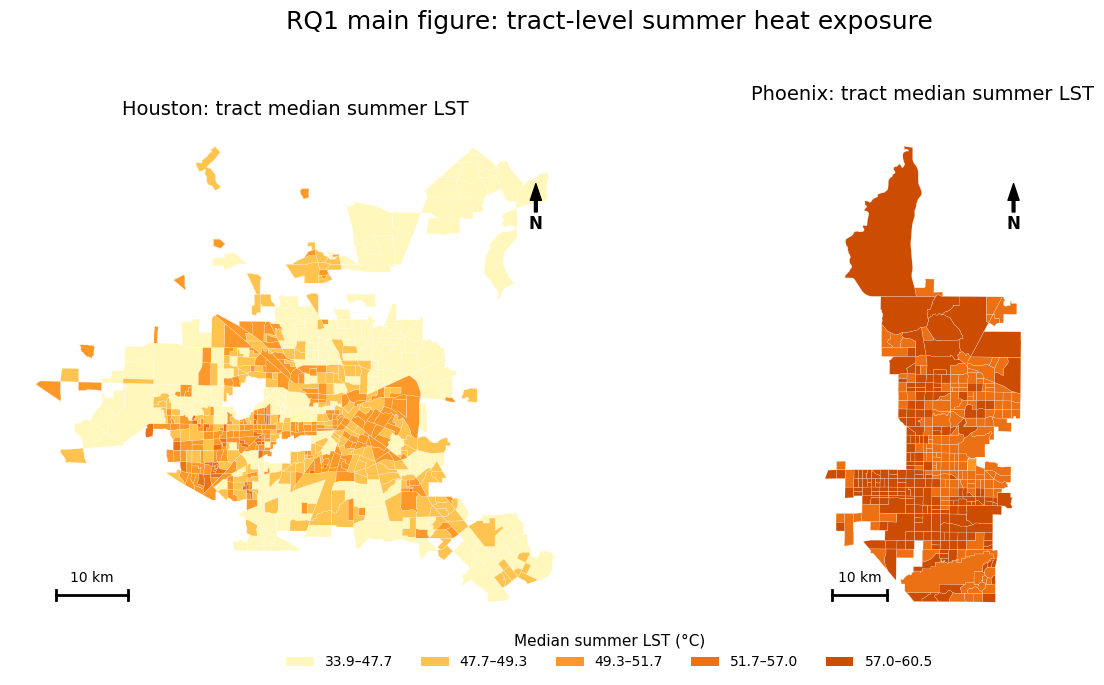

/Users/yufeizhou/Desktop/heat-exposure-compare/figures/pilot/teacher_ready_absolute_lst.png -> True
Breaks used: [33.9 47.7 49.3 51.7 57.  60.5]


In [26]:
# ============================================================
# Teacher-ready Figure A: clean absolute LST map
# ============================================================

from pathlib import Path
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

project_root = Path.cwd()
if not (project_root / "data_processed").exists():
    project_root = project_root.parent

figure_dir = project_root / "figures" / "pilot"
figure_dir.mkdir(parents=True, exist_ok=True)

houston_path = project_root / "data_processed" / "houston" / "houston_master_with_lst_hotspot.gpkg"
phoenix_path = project_root / "data_processed" / "phoenix" / "phoenix_master_with_lst_hotspot.gpkg"

houston = gpd.read_file(houston_path).copy()
phoenix = gpd.read_file(phoenix_path).copy()

# robust column detection
def get_lst_col(gdf):
    if "lst_summer_median_c" in gdf.columns:
        return "lst_summer_median_c"
    elif "median_lst_c" in gdf.columns:
        return "median_lst_c"
    else:
        raise ValueError(f"Cannot find LST column. Available columns: {list(gdf.columns)}")

houston_col = get_lst_col(houston)
phoenix_col = get_lst_col(phoenix)

# common class breaks across both cities
all_vals = pd.concat([
    pd.to_numeric(houston[houston_col], errors="coerce"),
    pd.to_numeric(phoenix[phoenix_col], errors="coerce")
], ignore_index=True).dropna()

breaks = np.quantile(all_vals, [0, 0.2, 0.4, 0.6, 0.8, 1.0])
breaks = np.unique(np.round(breaks, 1))
if len(breaks) < 6:
    breaks = np.round(np.linspace(all_vals.min(), all_vals.max(), 6), 1)

labels = [f"{breaks[i]:.1f}–{breaks[i+1]:.1f}" for i in range(len(breaks)-1)]
colors = ["#fff7bc", "#fec44f", "#fe9929", "#ec7014", "#cc4c02"]

houston["lst_class"] = pd.cut(
    pd.to_numeric(houston[houston_col], errors="coerce"),
    bins=breaks,
    labels=labels,
    include_lowest=True,
    duplicates="drop"
)

phoenix["lst_class"] = pd.cut(
    pd.to_numeric(phoenix[phoenix_col], errors="coerce"),
    bins=breaks,
    labels=labels,
    include_lowest=True,
    duplicates="drop"
)

def add_north_arrow(ax, x=0.92, y=0.88, dy=0.08):
    ax.annotate(
        "N",
        xy=(x, y),
        xytext=(x, y - dy),
        xycoords="axes fraction",
        textcoords="axes fraction",
        ha="center",
        va="center",
        fontsize=12,
        fontweight="bold",
        arrowprops=dict(facecolor="black", edgecolor="black", width=2, headwidth=8, shrink=0.0)
    )

def add_scalebar(ax, length_km=10):
    minx, maxx = ax.get_xlim()
    miny, maxy = ax.get_ylim()
    x_range = maxx - minx
    y_range = maxy - miny
    bar_len = length_km * 1000

    x0 = minx + 0.08 * x_range
    y0 = miny + 0.06 * y_range

    ax.plot([x0, x0 + bar_len], [y0, y0], color="black", lw=2)
    ax.plot([x0, x0], [y0 - 0.01 * y_range, y0 + 0.01 * y_range], color="black", lw=2)
    ax.plot([x0 + bar_len, x0 + bar_len], [y0 - 0.01 * y_range, y0 + 0.01 * y_range], color="black", lw=2)
    ax.text(x0 + bar_len / 2, y0 + 0.02 * y_range, f"{length_km} km", ha="center", va="bottom", fontsize=10)

fig, axes = plt.subplots(1, 2, figsize=(14, 7))

for ax, city_name, gdf in [
    (axes[0], "Houston", houston),
    (axes[1], "Phoenix", phoenix)
]:
    # base missing
    gdf[gdf["lst_class"].isna()].plot(ax=ax, color="#eeeeee", edgecolor="white", linewidth=0.15)

    # draw from low to high
    for lab, col in zip(labels, colors):
        sub = gdf[gdf["lst_class"] == lab]
        if len(sub) > 0:
            sub.plot(ax=ax, color=col, edgecolor="white", linewidth=0.15)

    ax.set_title(f"{city_name}: tract median summer LST", fontsize=14)
    ax.set_axis_off()
    add_north_arrow(ax)
    add_scalebar(ax, length_km=10)

handles = [Patch(facecolor=c, edgecolor="none", label=l) for c, l in zip(colors, labels)]
fig.legend(
    handles=handles,
    loc="lower center",
    bbox_to_anchor=(0.5, 0.02),
    ncol=len(labels),
    frameon=False,
    title="Median summer LST (°C)",
    fontsize=10,
    title_fontsize=11
)

plt.suptitle("RQ1 main figure: tract-level summer heat exposure", fontsize=18, y=0.98)
plt.tight_layout(rect=[0, 0.08, 1, 0.95])

teacher_abs_lst_out = figure_dir / "teacher_ready_absolute_lst.png"
plt.savefig(teacher_abs_lst_out, dpi=300, bbox_inches="tight", facecolor="white")
plt.show()

print(teacher_abs_lst_out, "->", teacher_abs_lst_out.exists())
print("Breaks used:", breaks)

Houston input exists? True
Phoenix input exists? True
Houston LST col: lst_summer_median_c
Phoenix LST col: lst_summer_median_c


,city,lst_col_used,city_median_lst,min_anomaly,max_anomaly,p95_abs_anomaly
0,Houston,lst_summer_median_c,48.531293,-14.598635,4.949788,4.992061
1,Phoenix,lst_summer_median_c,57.217040,-5.776073,3.249191,3.173307


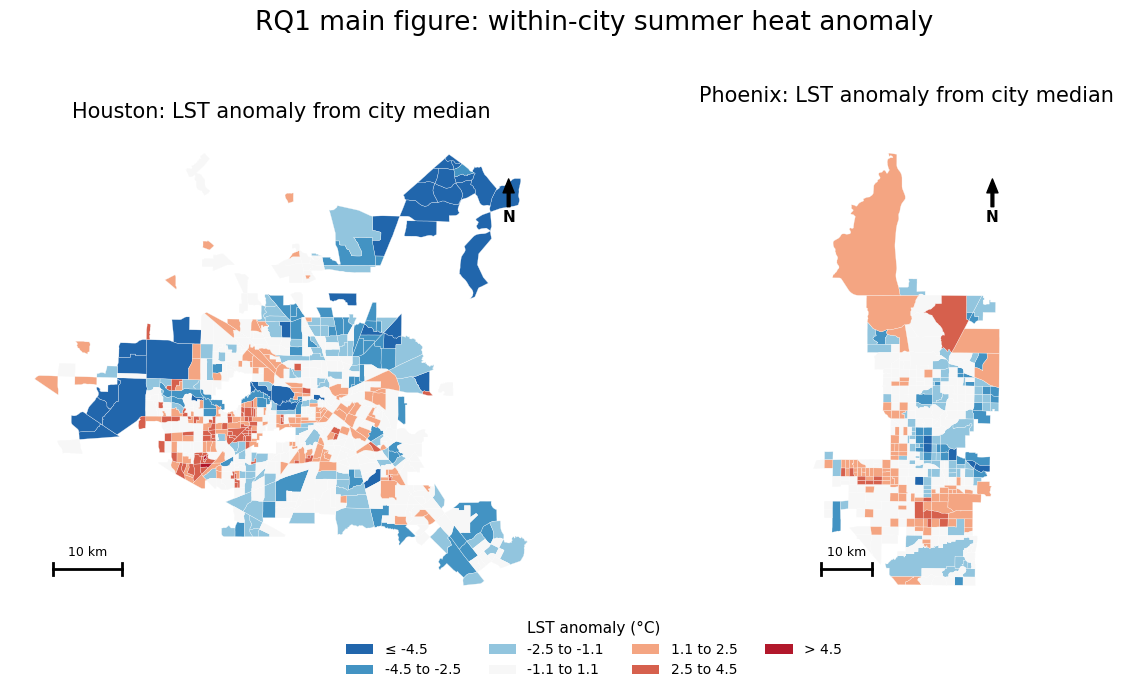


Fixed anomaly file check:
/Users/yufeizhou/Desktop/heat-exposure-compare/figures/pilot/teacher_ready_lst_anomaly_fixed.png -> True
/Users/yufeizhou/Desktop/heat-exposure-compare/outputs/pilot/rq1_anomaly_qc_fixed.csv -> True

Anomaly bins used: [-inf, np.float64(-4.5), np.float64(-2.5), np.float64(-1.1), np.float64(1.1), np.float64(2.5), np.float64(4.5), inf]


In [28]:


from pathlib import Path
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

# ---------- locate project root ----------
project_root = Path.cwd()
if not (project_root / "data_processed").exists():
    project_root = project_root.parent

figure_dir = project_root / "figures" / "pilot"
output_dir = project_root / "outputs" / "pilot"
figure_dir.mkdir(parents=True, exist_ok=True)
output_dir.mkdir(parents=True, exist_ok=True)

# ---------- correct input files ----------
houston_path = project_root / "data_processed" / "houston" / "houston_master_with_lst_hotspot.gpkg"
phoenix_path = project_root / "data_processed" / "phoenix" / "phoenix_master_with_lst_hotspot.gpkg"

print("Houston input exists?", houston_path.exists())
print("Phoenix input exists?", phoenix_path.exists())

# ---------- helper ----------
def detect_lst_col(gdf, city_name):
    candidates = ["lst_summer_median_c", "median_lst_c"]
    for c in candidates:
        if c in gdf.columns:
            return c
    raise ValueError(f"{city_name}: cannot find LST column. Available columns: {list(gdf.columns)}")

def load_city_gdf(path, city_name):
    gdf = gpd.read_file(path).copy()
    value_col = detect_lst_col(gdf, city_name)
    gdf[value_col] = pd.to_numeric(gdf[value_col], errors="coerce")
    gdf = gdf.loc[gdf.geometry.notna() & gdf[value_col].notna()].copy()
    gdf["city"] = city_name
    return gdf, value_col

def add_north_arrow(ax, x=0.92, y=0.90, size=0.08):
    ax.annotate(
        "N",
        xy=(x, y), xytext=(x, y - size),
        xycoords="axes fraction",
        textcoords="axes fraction",
        ha="center", va="center",
        fontsize=11, fontweight="bold",
        arrowprops=dict(facecolor="black", width=2, headwidth=8, headlength=10)
    )

def add_scalebar(ax, length_km=10, location=(0.08, 0.08), linewidth=2):
    xmin, xmax = ax.get_xlim()
    ymin, ymax = ax.get_ylim()
    x0 = xmin + (xmax - xmin) * location[0]
    y0 = ymin + (ymax - ymin) * location[1]
    length_m = length_km * 1000
    tick_h = (ymax - ymin) * 0.012

    ax.plot([x0, x0 + length_m], [y0, y0], color="black", linewidth=linewidth)
    ax.plot([x0, x0], [y0 - tick_h, y0 + tick_h], color="black", linewidth=linewidth)
    ax.plot([x0 + length_m, x0 + length_m], [y0 - tick_h, y0 + tick_h], color="black", linewidth=linewidth)
    ax.text(x0 + length_m / 2, y0 + tick_h * 1.8, f"{length_km} km", ha="center", va="bottom", fontsize=9)

def make_anomaly(gdf, value_col):
    gdf = gdf.copy()
    city_median = gdf[value_col].median()
    gdf["city_median_lst"] = city_median
    gdf["lst_anomaly"] = gdf[value_col] - city_median
    return gdf

# ---------- load ----------
houston, houston_lst_col = load_city_gdf(houston_path, "Houston")
phoenix, phoenix_lst_col = load_city_gdf(phoenix_path, "Phoenix")

print("Houston LST col:", houston_lst_col)
print("Phoenix LST col:", phoenix_lst_col)

houston = make_anomaly(houston, houston_lst_col)
phoenix = make_anomaly(phoenix, phoenix_lst_col)

# ---------- common anomaly breaks ----------
all_abs = pd.concat([
    houston["lst_anomaly"].abs(),
    phoenix["lst_anomaly"].abs()
], ignore_index=True).dropna()

vmax = float(np.nanpercentile(all_abs, 95))
vmax = max(vmax, 2.0)
vmax = np.ceil(vmax * 2) / 2  # nearest 0.5

b1 = round(vmax * 0.25, 1)
b2 = round(vmax * 0.55, 1)
b3 = round(vmax, 1)

bins = [-np.inf, -b3, -b2, -b1, b1, b2, b3, np.inf]
labels = [
    f"≤ -{b3}",
    f"-{b3} to -{b2}",
    f"-{b2} to -{b1}",
    f"-{b1} to {b1}",
    f"{b1} to {b2}",
    f"{b2} to {b3}",
    f"> {b3}"
]

colors = {
    f"≤ -{b3}": "#2166ac",
    f"-{b3} to -{b2}": "#4393c3",
    f"-{b2} to -{b1}": "#92c5de",
    f"-{b1} to {b1}": "#f7f7f7",
    f"{b1} to {b2}": "#f4a582",
    f"{b2} to {b3}": "#d6604d",
    f"> {b3}": "#b2182b"
}

for gdf in [houston, phoenix]:
    gdf["anomaly_class"] = pd.cut(
        gdf["lst_anomaly"],
        bins=bins,
        labels=labels,
        include_lowest=True
    )
    gdf["anomaly_class"] = pd.Categorical(gdf["anomaly_class"], categories=labels, ordered=True)

# ---------- QC ----------
anomaly_qc = pd.DataFrame([
    {
        "city": "Houston",
        "lst_col_used": houston_lst_col,
        "city_median_lst": houston["city_median_lst"].iloc[0],
        "min_anomaly": houston["lst_anomaly"].min(),
        "max_anomaly": houston["lst_anomaly"].max(),
        "p95_abs_anomaly": houston["lst_anomaly"].abs().quantile(0.95),
    },
    {
        "city": "Phoenix",
        "lst_col_used": phoenix_lst_col,
        "city_median_lst": phoenix["city_median_lst"].iloc[0],
        "min_anomaly": phoenix["lst_anomaly"].min(),
        "max_anomaly": phoenix["lst_anomaly"].max(),
        "p95_abs_anomaly": phoenix["lst_anomaly"].abs().quantile(0.95),
    }
])

display(anomaly_qc)

anomaly_qc_out = output_dir / "rq1_anomaly_qc_fixed.csv"
anomaly_qc.to_csv(anomaly_qc_out, index=False)

# ---------- plot ----------
fig, axes = plt.subplots(1, 2, figsize=(14, 6.8))

for ax, city_name, gdf in [
    (axes[0], "Houston", houston),
    (axes[1], "Phoenix", phoenix)
]:
    # base
    gdf.plot(ax=ax, color="#eeeeee", edgecolor="white", linewidth=0.2)

    # draw class by class
    for lab in labels:
        sub = gdf[gdf["anomaly_class"] == lab]
        if len(sub) > 0:
            sub.plot(ax=ax, color=colors[lab], edgecolor="white", linewidth=0.2)

    ax.set_title(f"{city_name}: LST anomaly from city median", fontsize=15, pad=10)
    ax.set_axis_off()
    add_north_arrow(ax)
    add_scalebar(ax, length_km=10)

handles = [Patch(facecolor=colors[l], edgecolor="none", label=l) for l in labels]
fig.legend(
    handles=handles,
    title="LST anomaly (°C)",
    loc="lower center",
    bbox_to_anchor=(0.5, -0.02),
    ncol=4,
    frameon=False,
    fontsize=10,
    title_fontsize=11
)

fig.suptitle("RQ1 main figure: within-city summer heat anomaly", fontsize=19, y=0.98)
plt.tight_layout(rect=[0, 0.08, 1, 0.95])

teacher_ready_anomaly_out = figure_dir / "teacher_ready_lst_anomaly_fixed.png"
plt.savefig(teacher_ready_anomaly_out, dpi=300, bbox_inches="tight")
plt.show()

print("\nFixed anomaly file check:")
for p in [teacher_ready_anomaly_out, anomaly_qc_out]:
    print(p, "->", p.exists())

print("\nAnomaly bins used:", bins)

,city,hot20_cut,cold20_cut,hot20_count,cold20_count
0,Houston,50.314631,46.782380,131,131
1,Phoenix,58.607177,55.533642,75,75


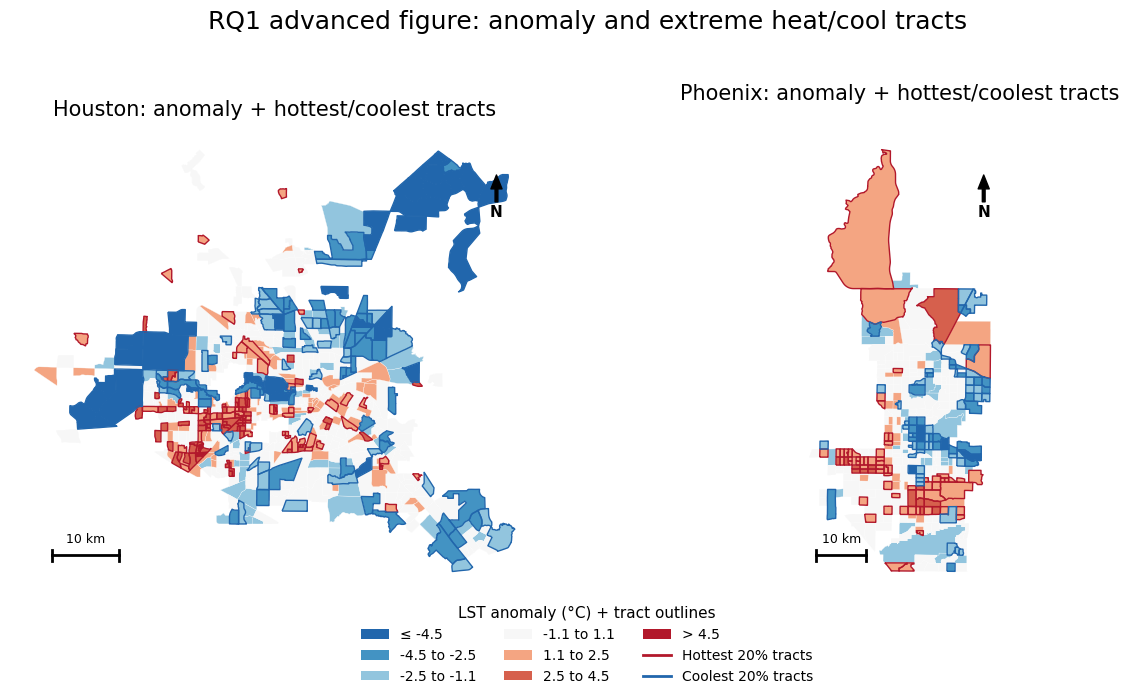


Fixed overlay file check:
/Users/yufeizhou/Desktop/heat-exposure-compare/figures/pilot/teacher_ready_anomaly_overlay_fixed.png -> True
/Users/yufeizhou/Desktop/heat-exposure-compare/outputs/pilot/rq1_extreme_overlay_qc_fixed.csv -> True


In [29]:
# ============================================================
# FIXED anomaly overlay map (self-contained)
# ============================================================

from matplotlib.lines import Line2D

def add_extreme_flags(gdf, value_col):
    gdf = gdf.copy()
    hot_cut = gdf[value_col].quantile(0.80)
    cold_cut = gdf[value_col].quantile(0.20)
    gdf["hot20_flag"] = gdf[value_col] >= hot_cut
    gdf["cold20_flag"] = gdf[value_col] <= cold_cut
    return gdf, hot_cut, cold_cut

houston2, hou_hot_cut, hou_cold_cut = add_extreme_flags(houston, houston_lst_col)
phoenix2, phx_hot_cut, phx_cold_cut = add_extreme_flags(phoenix, phoenix_lst_col)

overlay_qc = pd.DataFrame([
    {
        "city": "Houston",
        "hot20_cut": hou_hot_cut,
        "cold20_cut": hou_cold_cut,
        "hot20_count": int(houston2["hot20_flag"].sum()),
        "cold20_count": int(houston2["cold20_flag"].sum())
    },
    {
        "city": "Phoenix",
        "hot20_cut": phx_hot_cut,
        "cold20_cut": phx_cold_cut,
        "hot20_count": int(phoenix2["hot20_flag"].sum()),
        "cold20_count": int(phoenix2["cold20_flag"].sum())
    }
])

display(overlay_qc)

overlay_qc_out = output_dir / "rq1_extreme_overlay_qc_fixed.csv"
overlay_qc.to_csv(overlay_qc_out, index=False)

fig, axes = plt.subplots(1, 2, figsize=(14, 6.8))

for ax, city_name, gdf in [
    (axes[0], "Houston", houston2),
    (axes[1], "Phoenix", phoenix2)
]:
    gdf.plot(ax=ax, color="#eeeeee", edgecolor="white", linewidth=0.2)

    for lab in labels:
        sub = gdf[gdf["anomaly_class"] == lab]
        if len(sub) > 0:
            sub.plot(ax=ax, color=colors[lab], edgecolor="white", linewidth=0.2)

    # hottest 20%
    gdf[gdf["hot20_flag"]].boundary.plot(ax=ax, color="#b2182b", linewidth=1.0)

    # coolest 20%
    gdf[gdf["cold20_flag"]].boundary.plot(ax=ax, color="#2166ac", linewidth=1.0)

    ax.set_title(f"{city_name}: anomaly + hottest/coolest tracts", fontsize=15, pad=10)
    ax.set_axis_off()
    add_north_arrow(ax)
    add_scalebar(ax, length_km=10)

patch_handles = [Patch(facecolor=colors[l], edgecolor="none", label=l) for l in labels]
line_handles = [
    Line2D([0], [0], color="#b2182b", lw=2, label="Hottest 20% tracts"),
    Line2D([0], [0], color="#2166ac", lw=2, label="Coolest 20% tracts")
]

fig.legend(
    handles=patch_handles + line_handles,
    title="LST anomaly (°C) + tract outlines",
    loc="lower center",
    bbox_to_anchor=(0.5, -0.03),
    ncol=3,
    frameon=False,
    fontsize=10,
    title_fontsize=11
)

fig.suptitle("RQ1 advanced figure: anomaly and extreme heat/cool tracts", fontsize=18, y=0.98)
plt.tight_layout(rect=[0, 0.10, 1, 0.95])

teacher_ready_overlay_out = figure_dir / "teacher_ready_anomaly_overlay_fixed.png"
plt.savefig(teacher_ready_overlay_out, dpi=300, bbox_inches="tight")
plt.show()

print("\nFixed overlay file check:")
for p in [teacher_ready_overlay_out, overlay_qc_out]:
    print(p, "->", p.exists())

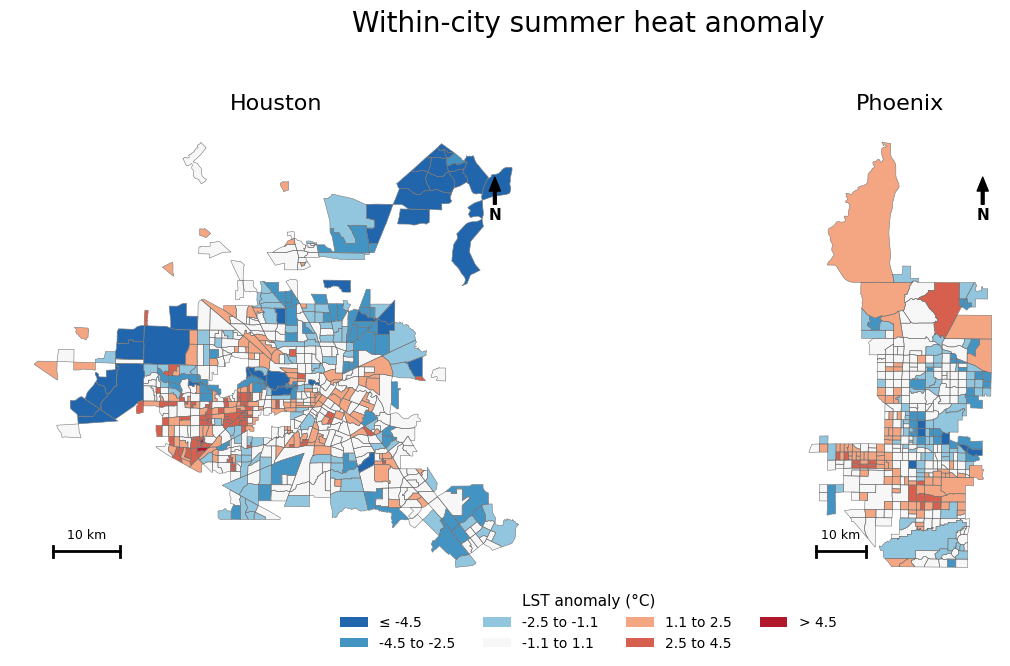

/Users/yufeizhou/Desktop/heat-exposure-compare/figures/pilot/teacher_ready_lst_anomaly_polished.png -> True
Bins: [-inf, np.float64(-4.5), np.float64(-2.5), np.float64(-1.1), np.float64(1.1), np.float64(2.5), np.float64(4.5), inf]


In [30]:
# ============================================================
# Final polish: cleaner teacher-ready anomaly figure
# ============================================================

from pathlib import Path
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import geopandas as gpd
import pandas as pd
import numpy as np

project_root = Path.cwd()
if not (project_root / "data_processed").exists():
    project_root = project_root.parent

figure_dir = project_root / "figures" / "pilot"
figure_dir.mkdir(parents=True, exist_ok=True)

# Reuse current data if available; otherwise reload
houston_path = project_root / "data_processed" / "houston" / "houston_master_with_lst_hotspot.gpkg"
phoenix_path = project_root / "data_processed" / "phoenix" / "phoenix_master_with_lst_hotspot.gpkg"

def detect_lst_col(gdf):
    for c in ["lst_summer_median_c", "median_lst_c"]:
        if c in gdf.columns:
            return c
    raise ValueError(f"Cannot find LST column. Available columns: {list(gdf.columns)}")

def load_for_polish(path, city_name):
    gdf = gpd.read_file(path).copy()
    value_col = detect_lst_col(gdf)
    gdf[value_col] = pd.to_numeric(gdf[value_col], errors="coerce")
    gdf = gdf.loc[gdf.geometry.notna() & gdf[value_col].notna()].copy()
    gdf["city"] = city_name
    gdf["lst_anomaly"] = gdf[value_col] - gdf[value_col].median()
    return gdf, value_col

def add_north_arrow(ax, x=0.91, y=0.88, size=0.08):
    ax.annotate(
        "N",
        xy=(x, y), xytext=(x, y - size),
        xycoords="axes fraction",
        textcoords="axes fraction",
        ha="center", va="center",
        fontsize=11, fontweight="bold",
        arrowprops=dict(facecolor="black", width=2, headwidth=8, headlength=10)
    )

def add_scalebar(ax, length_km=10, location=(0.08, 0.08), linewidth=2):
    xmin, xmax = ax.get_xlim()
    ymin, ymax = ax.get_ylim()
    x0 = xmin + (xmax - xmin) * location[0]
    y0 = ymin + (ymax - ymin) * location[1]
    length_m = length_km * 1000
    tick_h = (ymax - ymin) * 0.012

    ax.plot([x0, x0 + length_m], [y0, y0], color="black", linewidth=linewidth)
    ax.plot([x0, x0], [y0 - tick_h, y0 + tick_h], color="black", linewidth=linewidth)
    ax.plot([x0 + length_m, x0 + length_m], [y0 - tick_h, y0 + tick_h], color="black", linewidth=linewidth)
    ax.text(x0 + length_m / 2, y0 + tick_h * 1.8, f"{length_km} km", ha="center", va="bottom", fontsize=9)

houston_p, hou_col = load_for_polish(houston_path, "Houston")
phoenix_p, phx_col = load_for_polish(phoenix_path, "Phoenix")

all_abs = pd.concat([
    houston_p["lst_anomaly"].abs(),
    phoenix_p["lst_anomaly"].abs()
], ignore_index=True).dropna()

vmax = float(np.nanpercentile(all_abs, 95))
vmax = max(vmax, 2.0)
vmax = np.ceil(vmax * 2) / 2

b1 = round(vmax * 0.25, 1)
b2 = round(vmax * 0.55, 1)
b3 = round(vmax, 1)

bins = [-np.inf, -b3, -b2, -b1, b1, b2, b3, np.inf]
labels = [
    f"≤ -{b3}",
    f"-{b3} to -{b2}",
    f"-{b2} to -{b1}",
    f"-{b1} to {b1}",
    f"{b1} to {b2}",
    f"{b2} to {b3}",
    f"> {b3}"
]

colors = {
    f"≤ -{b3}": "#2166ac",
    f"-{b3} to -{b2}": "#4393c3",
    f"-{b2} to -{b1}": "#92c5de",
    f"-{b1} to {b1}": "#f7f7f7",
    f"{b1} to {b2}": "#f4a582",
    f"{b2} to {b3}": "#d6604d",
    f"> {b3}": "#b2182b"
}

for gdf in [houston_p, phoenix_p]:
    gdf["anomaly_class"] = pd.cut(gdf["lst_anomaly"], bins=bins, labels=labels, include_lowest=True)
    gdf["anomaly_class"] = pd.Categorical(gdf["anomaly_class"], categories=labels, ordered=True)

fig, axes = plt.subplots(1, 2, figsize=(14, 6.6), facecolor="white")

for ax, city_name, gdf in [
    (axes[0], "Houston", houston_p),
    (axes[1], "Phoenix", phoenix_p)
]:
    # draw base
    gdf.plot(ax=ax, color="#f0f0f0", edgecolor="white", linewidth=0.15)

    # anomaly fill
    for lab in labels:
        sub = gdf[gdf["anomaly_class"] == lab]
        if len(sub) > 0:
            sub.plot(ax=ax, color=colors[lab], edgecolor="white", linewidth=0.15)

    # outer city outline for clarity
    gdf.boundary.plot(ax=ax, color="#666666", linewidth=0.35)

    ax.set_title(city_name, fontsize=16, pad=8)
    ax.set_axis_off()
    add_north_arrow(ax)
    add_scalebar(ax, length_km=10)

handles = [Patch(facecolor=colors[l], edgecolor="none", label=l) for l in labels]
fig.legend(
    handles=handles,
    title="LST anomaly (°C)",
    loc="lower center",
    bbox_to_anchor=(0.5, -0.01),
    ncol=4,
    frameon=False,
    fontsize=10,
    title_fontsize=11
)

fig.suptitle("Within-city summer heat anomaly", fontsize=20, y=0.98)
plt.tight_layout(rect=[0, 0.08, 1, 0.94])

teacher_ready_anomaly_polished_out = figure_dir / "teacher_ready_lst_anomaly_polished.png"
plt.savefig(teacher_ready_anomaly_polished_out, dpi=300, bbox_inches="tight", facecolor="white")
plt.show()

print(teacher_ready_anomaly_polished_out, "->", teacher_ready_anomaly_polished_out.exists())
print("Bins:", bins)

In [32]:
import json
from pathlib import Path

print("Current cwd:", Path.cwd())

project_root = Path.cwd()
if not (project_root / "archive_old").exists():
    project_root = project_root.parent

print("Project root:", project_root)

nb_path = project_root / "archive_old" / "02_four_city_extension.ipynb"
print("Notebook path:", nb_path)
print("Notebook exists?", nb_path.exists())

nb = json.loads(nb_path.read_text(encoding="utf-8"))

keywords = [
    "jaccard", "hotspot", "Heat Index", "heat index", "LST",
    "quantile", "qcut", "percentile", "threshold", "cutoff",
    "intersection", "union",
    "Phoenix", "Miami", "Las Vegas", "Houston"
]

for i, cell in enumerate(nb.get("cells", [])):
    src = "".join(cell.get("source", []))
    lower = src.lower()
    if any(k.lower() in lower for k in keywords):
        print("\n" + "=" * 80)
        print(f"CELL {i}")
        print("=" * 80)
        print(src[:4000])

Current cwd: /Users/yufeizhou/Desktop/heat-exposure-compare/notebooks
Project root: /Users/yufeizhou/Desktop/heat-exposure-compare
Notebook path: /Users/yufeizhou/Desktop/heat-exposure-compare/archive_old/02_four_city_extension.ipynb
Notebook exists? True

CELL 0
# Four-City Extension for Heat Exposure Comparison

This notebook extends the pilot comparison from two cities to four cities:

- Phoenix, Arizona
- Miami, Florida
- Las Vegas, Nevada
- Houston, Texas

The goal is to test whether the differences between Land Surface Temperature (LST) and Heat Index remain consistent across more hot-dry and hot-humid urban contexts.

CELL 4
# Filter four target cities

phoenix_gdf = az_places_gdf[az_places_gdf["NAME"].str.lower() == "phoenix"].copy()
miami_gdf = fl_places_gdf[fl_places_gdf["NAME"].str.lower() == "miami"].copy()
lasvegas_gdf = nv_places_gdf[nv_places_gdf["NAME"].str.lower() == "las vegas"].copy()
houston_gdf = tx_places_gdf[tx_places_gdf["NAME"].str.lower() == "houston"].copy()


In [33]:
import json
import re
from pathlib import Path

project_root = Path.cwd()
if not (project_root / "archive_old").exists():
    project_root = project_root.parent

nb_path = project_root / "archive_old" / "02_four_city_extension.ipynb"
print("Notebook exists?", nb_path.exists())

nb = json.loads(nb_path.read_text(encoding="utf-8"))

patterns = [
    r"jaccard",
    r"intersection",
    r"\bunion\b",
    r"quantile\s*\(",
    r"qcut\s*\(",
    r"percentile",
    r"threshold",
    r"cutoff",
    r"hotspot"
]

for i, cell in enumerate(nb.get("cells", [])):
    src = "".join(cell.get("source", []))
    hits = [p for p in patterns if re.search(p, src, flags=re.I)]
    if hits:
        print("\n" + "=" * 90)
        print(f"CELL {i}   hits = {hits}")
        print("=" * 90)

        lines = src.splitlines()
        for ln, line in enumerate(lines, start=1):
            if any(re.search(p, line, flags=re.I) for p in patterns):
                start = max(0, ln - 3)
                end = min(len(lines), ln + 3)
                print(f"\n--- around line {ln} ---")
                for j in range(start, end):
                    print(f"{j+1:03d}: {lines[j]}")

Notebook exists? True

CELL 11   hits = ['jaccard', 'hotspot']

--- around line 1 ---
001: ## Hotspot Overlap Analysis Across Four Cities
002: 
003: Next, we compare whether LST hotspots and Heat Index hotspots identify the same high-risk areas.
004: 

--- around line 3 ---
001: ## Hotspot Overlap Analysis Across Four Cities
002: 
003: Next, we compare whether LST hotspots and Heat Index hotspots identify the same high-risk areas.
004: 
005: For each city, we define hotspots as the top 20% pixels for each measure and calculate:
006: 

--- around line 5 ---
003: Next, we compare whether LST hotspots and Heat Index hotspots identify the same high-risk areas.
004: 
005: For each city, we define hotspots as the top 20% pixels for each measure and calculate:
006: 
007: - LST-only hotspot area
008: - Heat-Index-only hotspot area

--- around line 7 ---
005: For each city, we define hotspots as the top 20% pixels for each measure and calculate:
006: 
007: - LST-only hotspot area
008: - Heat-In

In [35]:
# ============================================================
# Block A: tract-level pilot Heat Index extraction (FULL REPLACEMENT)
# ============================================================

from pathlib import Path
import json
import pandas as pd
import ee

# ---------- locate project root ----------
project_root = Path.cwd()
if not (project_root / "data_processed").exists():
    project_root = project_root.parent

data_processed = project_root / "data_processed"
output_dir = project_root / "outputs" / "pilot"
output_dir.mkdir(parents=True, exist_ok=True)

EE_PROJECT = "yufei-gee-lab6"

# ---------- initialize EE ----------
try:
    ee.Initialize(project=EE_PROJECT)
    print("Earth Engine initialized successfully.")
except Exception:
    ee.Authenticate(auth_mode="localhost", force=True)
    ee.Initialize(project=EE_PROJECT)
    print("Earth Engine initialized successfully after auth.")

# ---------- helper: geojson -> EE FeatureCollection ----------
def geojson_to_ee_fc(path_obj):
    with open(path_obj, "r", encoding="utf-8") as f:
        gj = json.load(f)
    return ee.FeatureCollection(gj)

# ---------- input paths ----------
houston_boundary_geojson = output_dir / "heat_ready" / "houston" / "houston_boundary_heat_ready.geojson"
phoenix_boundary_geojson = output_dir / "heat_ready" / "phoenix" / "phoenix_boundary_heat_ready.geojson"
houston_tract_geojson = output_dir / "heat_ready" / "houston" / "houston_tracts_heat_ready.geojson"
phoenix_tract_geojson = output_dir / "heat_ready" / "phoenix" / "phoenix_tracts_heat_ready.geojson"

print("Houston boundary exists?", houston_boundary_geojson.exists())
print("Phoenix boundary exists?", phoenix_boundary_geojson.exists())
print("Houston tracts exists?", houston_tract_geojson.exists())
print("Phoenix tracts exists?", phoenix_tract_geojson.exists())

houston_boundary_fc = geojson_to_ee_fc(houston_boundary_geojson)
phoenix_boundary_fc = geojson_to_ee_fc(phoenix_boundary_geojson)
houston_tract_fc = geojson_to_ee_fc(houston_tract_geojson)
phoenix_tract_fc = geojson_to_ee_fc(phoenix_tract_geojson)

# ---------- pilot window ----------
# end is exclusive in Earth Engine filterDate, so use 2023-09-01
pilot_start = "2023-06-01"
pilot_end = "2023-09-01"

# ---------- ERA5-Land ----------
era5_land = ee.ImageCollection("ECMWF/ERA5_LAND/HOURLY")

# ---------- Heat Index from temperature + dew point ----------
def image_to_hi_c(image):
    # Kelvin -> Celsius
    t_c = image.select("temperature_2m").subtract(273.15).rename("T_C")
    td_c = image.select("dewpoint_temperature_2m").subtract(273.15).rename("TD_C")

    # Relative humidity from T and Td
    rh = t_c.expression(
        "100 * exp((17.625 * Td) / (243.04 + Td) - (17.625 * T) / (243.04 + T))",
        {
            "T": t_c,
            "Td": td_c
        }
    ).clamp(0, 100).rename("RH")

    # Celsius -> Fahrenheit
    t_f = t_c.multiply(9 / 5).add(32).rename("T_F")

    # Simple HI approximation for lower temperatures
    simple_hi_f = t_f.expression(
        "0.5 * (T + 61.0 + ((T - 68.0) * 1.2) + (RH * 0.094))",
        {
            "T": t_f,
            "RH": rh
        }
    ).rename("HI_simple_F")

    # Rothfusz regression
    roth_hi_f = t_f.expression(
        "-42.379 + 2.04901523*T + 10.14333127*RH - 0.22475541*T*RH"
        " - 0.00683783*T*T - 0.05481717*RH*RH + 0.00122874*T*T*RH"
        " + 0.00085282*T*RH*RH - 0.00000199*T*T*RH*RH",
        {
            "T": t_f,
            "RH": rh
        }
    ).rename("HI_roth_F")

    # Use simple formula when T < 80 F
    hi_f = roth_hi_f.where(t_f.lt(80), simple_hi_f).rename("HI_F")

    # Fahrenheit -> Celsius
    hi_c = hi_f.subtract(32).multiply(5 / 9).rename("HI_C")

    return hi_c.copyProperties(image, image.propertyNames())

def build_city_hi_collection(boundary_fc):
    coll = (
        era5_land
        .filterDate(pilot_start, pilot_end)
        .filterBounds(boundary_fc)
        .map(image_to_hi_c)
    )
    return coll

houston_hi_coll = build_city_hi_collection(houston_boundary_fc)
phoenix_hi_coll = build_city_hi_collection(phoenix_boundary_fc)

houston_hi_median = houston_hi_coll.median().clip(houston_boundary_fc)
phoenix_hi_median = phoenix_hi_coll.median().clip(phoenix_boundary_fc)

# ---------- reduce to tracts ----------
def reduce_hi_to_tracts(hi_image, tract_fc):
    return hi_image.reduceRegions(
        collection=tract_fc,
        reducer=ee.Reducer.mean().combine(
            reducer2=ee.Reducer.median(),
            sharedInputs=True
        ),
        scale=11132,
        tileScale=4
    )

houston_hi_fc = reduce_hi_to_tracts(houston_hi_median, houston_tract_fc)
phoenix_hi_fc = reduce_hi_to_tracts(phoenix_hi_median, phoenix_tract_fc)

def ee_fc_to_df(fc):
    info = fc.getInfo()
    rows = []
    for feat in info["features"]:
        rows.append(feat["properties"])
    return pd.DataFrame(rows)

houston_hi_df = ee_fc_to_df(houston_hi_fc)
phoenix_hi_df = ee_fc_to_df(phoenix_hi_fc)

for df, city in [(houston_hi_df, "Houston"), (phoenix_hi_df, "Phoenix")]:
    if "GEOID" in df.columns:
        df["GEOID"] = df["GEOID"].astype(str)
    df["city"] = city

rename_map = {
    "mean": "hi_summer_mean_c",
    "median": "hi_summer_median_c"
}
houston_hi_df = houston_hi_df.rename(columns=rename_map)
phoenix_hi_df = phoenix_hi_df.rename(columns=rename_map)

print("Houston HI sample:")
display(houston_hi_df.head())

print("Phoenix HI sample:")
display(phoenix_hi_df.head())

hi_extract_qc = pd.DataFrame([
    {
        "city": "Houston",
        "tract_rows": len(houston_hi_df),
        "unique_geoids": houston_hi_df["GEOID"].nunique() if "GEOID" in houston_hi_df.columns else None,
        "missing_hi_mean": houston_hi_df["hi_summer_mean_c"].isna().sum() if "hi_summer_mean_c" in houston_hi_df.columns else None,
        "missing_hi_median": houston_hi_df["hi_summer_median_c"].isna().sum() if "hi_summer_median_c" in houston_hi_df.columns else None,
        "era5_hourly_count": houston_hi_coll.size().getInfo(),
    },
    {
        "city": "Phoenix",
        "tract_rows": len(phoenix_hi_df),
        "unique_geoids": phoenix_hi_df["GEOID"].nunique() if "GEOID" in phoenix_hi_df.columns else None,
        "missing_hi_mean": phoenix_hi_df["hi_summer_mean_c"].isna().sum() if "hi_summer_mean_c" in phoenix_hi_df.columns else None,
        "missing_hi_median": phoenix_hi_df["hi_summer_median_c"].isna().sum() if "hi_summer_median_c" in phoenix_hi_df.columns else None,
        "era5_hourly_count": phoenix_hi_coll.size().getInfo(),
    }
])

print("HI extraction QC:")
display(hi_extract_qc)

houston_hi_csv = output_dir / "houston_hi_pilot.csv"
phoenix_hi_csv = output_dir / "phoenix_hi_pilot.csv"
hi_extract_qc_csv = output_dir / "hi_extract_qc.csv"

houston_hi_df.to_csv(houston_hi_csv, index=False)
phoenix_hi_df.to_csv(phoenix_hi_csv, index=False)
hi_extract_qc.to_csv(hi_extract_qc_csv, index=False)

print("\nBlock A file check:")
for p in [houston_hi_csv, phoenix_hi_csv, hi_extract_qc_csv]:
    print(p, "->", p.exists())

Earth Engine initialized successfully.
Houston boundary exists? True
Phoenix boundary exists? True
Houston tracts exists? True
Phoenix tracts exists? True
Houston HI sample:


,ALAND,AWATER,COUNTYFP,GEOID,NAME,NAMELSAD,STATEFP,TRACTCE,area_km2,below_poverty_count,...,low_income_flag,hi_summer_mean_c,hi_summer_median_c,median_household_income,median_household_income_clean,poverty_rate,poverty_universe,poverty_universe_clean,total_population,total_population_clean
0,1238555,0,201,48201421101,4211.01,Census Tract 4211.01,48,421101,1.239311,762,...,True,34.198098,34.198098,57959,57959.0,0.287982,2646,2646,2646,2646
1,1654036,22924,201,48201423301,4233.01,Census Tract 4233.01,48,423301,1.678074,499,...,False,34.199077,34.199077,61979,61979.0,0.101899,4897,4897,4897,4897
2,963415,0,201,48201453401,4534.01,Census Tract 4534.01,48,453401,0.964123,714,...,False,34.199077,34.199077,72572,72572.0,0.242857,2940,2940,2953,2953
3,3231321,0,201,48201331100,3311,Census Tract 3311,48,331100,3.232928,1034,...,True,34.183054,34.183054,53974,53974.0,0.260322,3972,3972,3979,3979
4,3546122,0,201,48201331200,3312,Census Tract 3312,48,331200,3.547893,2017,...,True,34.183054,34.183054,29650,29650.0,0.400437,5037,5037,5051,5051


Phoenix HI sample:


,ALAND,AWATER,COUNTYFP,GEOID,NAME,NAMELSAD,STATEFP,TRACTCE,area_km2,below_poverty_count,...,low_income_flag,hi_summer_mean_c,hi_summer_median_c,median_household_income,median_household_income_clean,poverty_rate,poverty_universe,poverty_universe_clean,total_population,total_population_clean
0,7360771,0,013,04013117200,1172,Census Tract 1172,04,117200,7.356595,292,...,True,33.553842,33.553842,65735,65735.0,0.259556,1125,1125,1125,1125
1,5194775,1855,013,04013082016,820.16,Census Tract 820.16,04,082016,5.194239,530,...,False,34.032794,34.186790,90156,90156.0,0.127742,4149,4149,4197,4197
2,2556177,25320,013,04013104402,1044.02,Census Tract 1044.02,04,104402,2.580105,305,...,True,33.307519,33.307519,70455,70455.0,0.125257,2435,2435,2435,2435
3,1067401,0,013,04013104701,1047.01,Census Tract 1047.01,04,104701,1.066803,639,...,True,33.308242,33.308242,68613,68613.0,0.234323,2727,2727,2727,2727
4,1449651,0,013,04013104702,1047.02,Census Tract 1047.02,04,104702,1.448834,770,...,True,33.308242,33.308242,42543,42543.0,0.210268,3662,3662,3662,3662


HI extraction QC:


,city,tract_rows,unique_geoids,missing_hi_mean,missing_hi_median,era5_hourly_count
0,Houston,654,654,105,105,2208
1,Phoenix,373,373,41,41,2208



Block A file check:
/Users/yufeizhou/Desktop/heat-exposure-compare/outputs/pilot/houston_hi_pilot.csv -> True
/Users/yufeizhou/Desktop/heat-exposure-compare/outputs/pilot/phoenix_hi_pilot.csv -> True
/Users/yufeizhou/Desktop/heat-exposure-compare/outputs/pilot/hi_extract_qc.csv -> True


In [36]:
from pathlib import Path

project_root = Path.cwd()
if not (project_root / "data_processed").exists():
    project_root = project_root.parent

candidate_paths = [
    project_root / "data_processed" / "houston" / "houston_master_with_lst_hotspot.gpkg",
    project_root / "data_processed" / "houston" / "houston_master_demo_poverty.gpkg",
    project_root / "data_processed" / "houston" / "houston_master_demo.gpkg",
]

candidate_paths_phx = [
    project_root / "data_processed" / "phoenix" / "phoenix_master_with_lst_hotspot.gpkg",
    project_root / "data_processed" / "phoenix" / "phoenix_master_demo_poverty.gpkg",
    project_root / "data_processed" / "phoenix" / "phoenix_master_demo.gpkg",
]

print("Houston candidates:")
for p in candidate_paths:
    print(p, "->", p.exists())

print("\nPhoenix candidates:")
for p in candidate_paths_phx:
    print(p, "->", p.exists())

Houston candidates:
/Users/yufeizhou/Desktop/heat-exposure-compare/data_processed/houston/houston_master_with_lst_hotspot.gpkg -> True
/Users/yufeizhou/Desktop/heat-exposure-compare/data_processed/houston/houston_master_demo_poverty.gpkg -> True
/Users/yufeizhou/Desktop/heat-exposure-compare/data_processed/houston/houston_master_demo.gpkg -> True

Phoenix candidates:
/Users/yufeizhou/Desktop/heat-exposure-compare/data_processed/phoenix/phoenix_master_with_lst_hotspot.gpkg -> True
/Users/yufeizhou/Desktop/heat-exposure-compare/data_processed/phoenix/phoenix_master_demo_poverty.gpkg -> True
/Users/yufeizhou/Desktop/heat-exposure-compare/data_processed/phoenix/phoenix_master_demo.gpkg -> True


Houston master: using -> /Users/yufeizhou/Desktop/heat-exposure-compare/data_processed/houston/houston_master_with_lst_hotspot.gpkg
Phoenix master: using -> /Users/yufeizhou/Desktop/heat-exposure-compare/data_processed/phoenix/phoenix_master_with_lst_hotspot.gpkg
Houston LST column: lst_summer_median_c
Phoenix LST column: lst_summer_median_c
Comparison QC:


/Users/yufeizhou/Desktop/heat-exposure-compare/.venv/lib/python3.12/site-packages/numpy/lib/_nanfunctions_impl.py:1213: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)
/Users/yufeizhou/Desktop/heat-exposure-compare/.venv/lib/python3.12/site-packages/numpy/lib/_nanfunctions_impl.py:1213: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)


,city,tract_rows,missing_hi_after_merge,median_lst_c,median_hi_c
0,Houston,654,105,48.531293,34.182125
1,Phoenix,373,373,57.217040,NaN


/var/folders/6w/9b3gk7f16xx8v8xscr34djk00000gn/T/ipykernel_73634/751239046.py:177: UserWarning: The GeoDataFrame you are attempting to plot is empty. Nothing has been displayed.
  gdf[gdf[class_col].isna()].plot(ax=ax, color="#d9d9d9", edgecolor="white", linewidth=0.18)
/var/folders/6w/9b3gk7f16xx8v8xscr34djk00000gn/T/ipykernel_73634/751239046.py:177: UserWarning: The GeoDataFrame you are attempting to plot is empty. Nothing has been displayed.
  gdf[gdf[class_col].isna()].plot(ax=ax, color="#d9d9d9", edgecolor="white", linewidth=0.18)


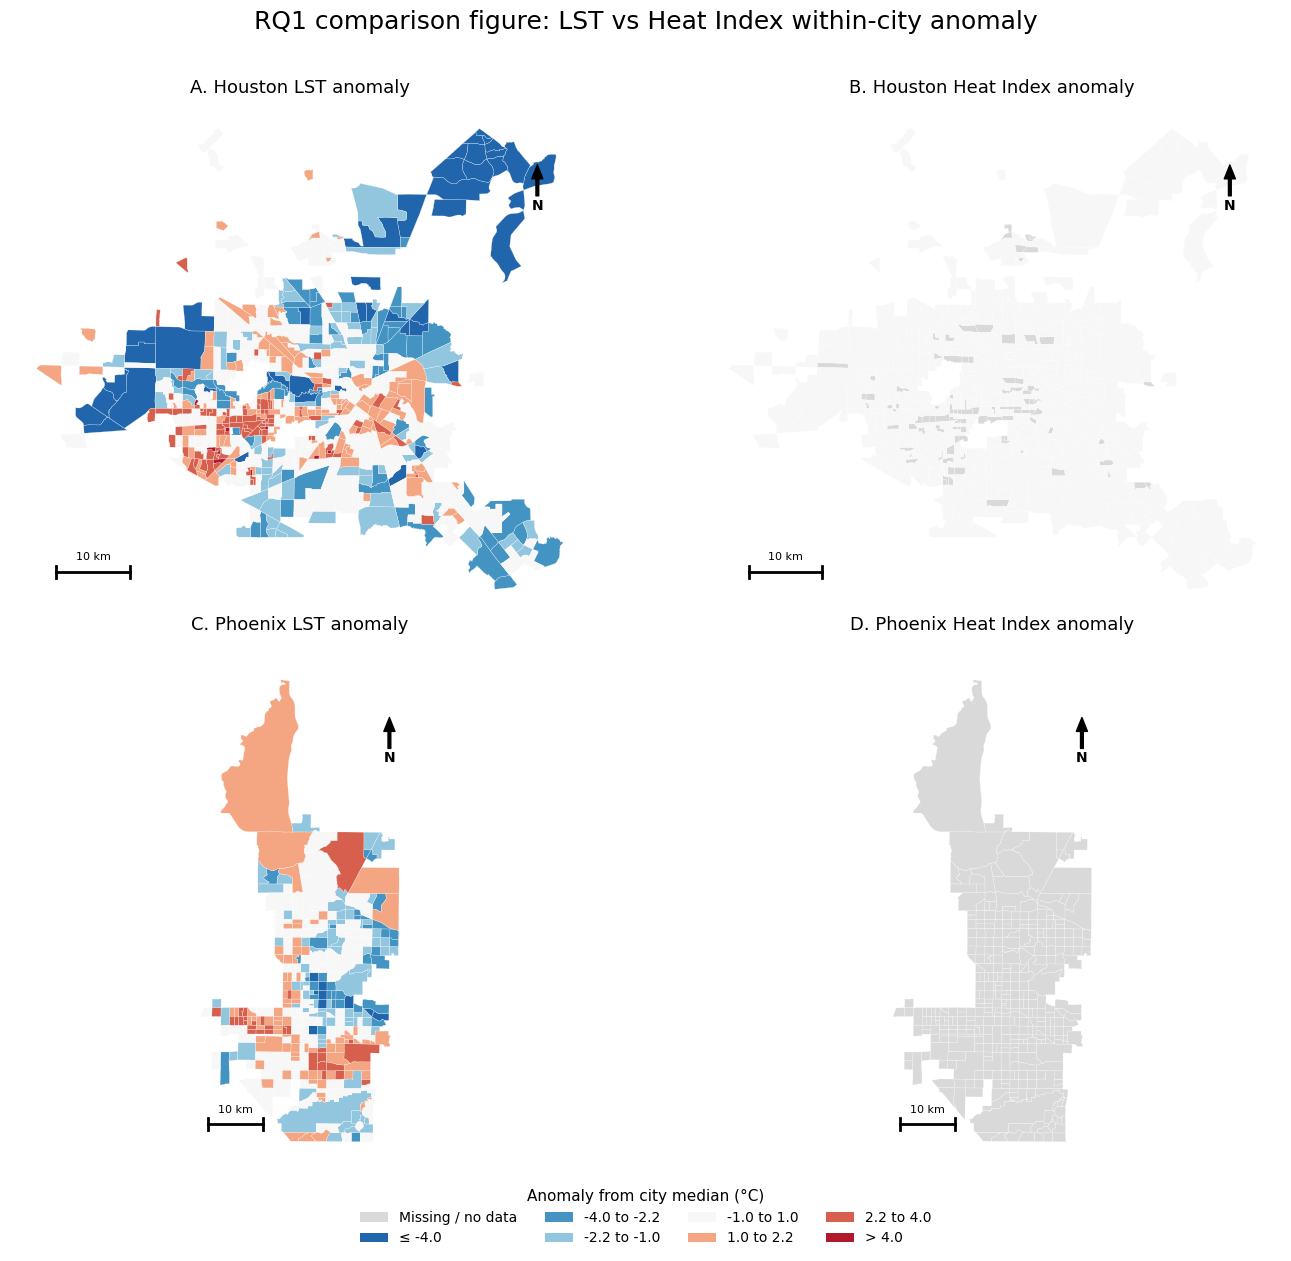


Block B file check:
/Users/yufeizhou/Desktop/heat-exposure-compare/figures/pilot/rq1_lst_vs_hi_anomaly_panel.png -> True
/Users/yufeizhou/Desktop/heat-exposure-compare/outputs/pilot/rq1_lst_vs_hi_comparison_qc.csv -> True
/Users/yufeizhou/Desktop/heat-exposure-compare/data_processed/houston/houston_master_with_lst_hi.gpkg -> True
/Users/yufeizhou/Desktop/heat-exposure-compare/data_processed/phoenix/phoenix_master_with_lst_hi.gpkg -> True


In [37]:
# ============================================================
# Block B (robust): merge HI back and make LST vs HI comparison maps
# ============================================================

from pathlib import Path
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

# ---------- locate project root ----------
project_root = Path.cwd()
if not (project_root / "data_processed").exists():
    project_root = project_root.parent

data_processed = project_root / "data_processed"
output_dir = project_root / "outputs" / "pilot"
figure_dir = project_root / "figures" / "pilot"
figure_dir.mkdir(parents=True, exist_ok=True)

# ---------- helper: choose first existing path ----------
def first_existing(paths, label):
    for p in paths:
        if p.exists():
            print(f"{label}: using -> {p}")
            return p
    raise FileNotFoundError(f"{label}: no existing file found in candidates:\n" + "\n".join(str(x) for x in paths))

houston_master_path = first_existing([
    data_processed / "houston" / "houston_master_with_lst_hotspot.gpkg",
    data_processed / "houston" / "houston_master_demo_poverty.gpkg",
    data_processed / "houston" / "houston_master_demo.gpkg",
], "Houston master")

phoenix_master_path = first_existing([
    data_processed / "phoenix" / "phoenix_master_with_lst_hotspot.gpkg",
    data_processed / "phoenix" / "phoenix_master_demo_poverty.gpkg",
    data_processed / "phoenix" / "phoenix_master_demo.gpkg",
], "Phoenix master")

houston_hi_csv = output_dir / "houston_hi_pilot.csv"
phoenix_hi_csv = output_dir / "phoenix_hi_pilot.csv"

# ---------- read ----------
houston = gpd.read_file(houston_master_path).copy()
phoenix = gpd.read_file(phoenix_master_path).copy()

houston["GEOID"] = houston["GEOID"].astype(str)
phoenix["GEOID"] = phoenix["GEOID"].astype(str)

houston_hi = pd.read_csv(houston_hi_csv)
phoenix_hi = pd.read_csv(phoenix_hi_csv)

houston_hi["GEOID"] = houston_hi["GEOID"].astype(str)
phoenix_hi["GEOID"] = phoenix_hi["GEOID"].astype(str)

# ---------- detect LST column ----------
def detect_lst_col(gdf, city_name):
    for c in ["lst_summer_median_c", "median_lst_c", "lst_median_c"]:
        if c in gdf.columns:
            return c
    raise ValueError(f"{city_name}: cannot find LST column. Available columns: {list(gdf.columns)}")

houston_lst_col = detect_lst_col(houston, "Houston")
phoenix_lst_col = detect_lst_col(phoenix, "Phoenix")

print("Houston LST column:", houston_lst_col)
print("Phoenix LST column:", phoenix_lst_col)

# ---------- merge HI ----------
houston_cmp = houston.merge(
    houston_hi[["GEOID", "hi_summer_mean_c", "hi_summer_median_c"]],
    on="GEOID",
    how="left"
)
phoenix_cmp = phoenix.merge(
    phoenix_hi[["GEOID", "hi_summer_mean_c", "hi_summer_median_c"]],
    on="GEOID",
    how="left"
)

# ---------- anomalies ----------
houston_cmp["lst_anomaly"] = houston_cmp[houston_lst_col] - houston_cmp[houston_lst_col].median()
phoenix_cmp["lst_anomaly"] = phoenix_cmp[phoenix_lst_col] - phoenix_cmp[phoenix_lst_col].median()

houston_cmp["hi_anomaly"] = houston_cmp["hi_summer_median_c"] - houston_cmp["hi_summer_median_c"].median()
phoenix_cmp["hi_anomaly"] = phoenix_cmp["hi_summer_median_c"] - phoenix_cmp["hi_summer_median_c"].median()

comparison_qc = pd.DataFrame([
    {
        "city": "Houston",
        "tract_rows": len(houston_cmp),
        "missing_hi_after_merge": int(houston_cmp["hi_summer_median_c"].isna().sum()),
        "median_lst_c": float(houston_cmp[houston_lst_col].median()),
        "median_hi_c": float(houston_cmp["hi_summer_median_c"].median()),
    },
    {
        "city": "Phoenix",
        "tract_rows": len(phoenix_cmp),
        "missing_hi_after_merge": int(phoenix_cmp["hi_summer_median_c"].isna().sum()),
        "median_lst_c": float(phoenix_cmp[phoenix_lst_col].median()),
        "median_hi_c": float(phoenix_cmp["hi_summer_median_c"].median()),
    }
])

print("Comparison QC:")
display(comparison_qc)

# ---------- common anomaly bins ----------
all_abs = pd.concat([
    houston_cmp["lst_anomaly"].abs(),
    phoenix_cmp["lst_anomaly"].abs(),
    houston_cmp["hi_anomaly"].abs(),
    phoenix_cmp["hi_anomaly"].abs()
], ignore_index=True).dropna()

vmax = float(np.nanpercentile(all_abs, 95))
vmax = max(vmax, 2.0)
vmax = np.ceil(vmax * 2) / 2

b1 = round(vmax * 0.25, 1)
b2 = round(vmax * 0.55, 1)
b3 = round(vmax, 1)

bins = [-np.inf, -b3, -b2, -b1, b1, b2, b3, np.inf]
labels = [
    f"≤ -{b3}",
    f"-{b3} to -{b2}",
    f"-{b2} to -{b1}",
    f"-{b1} to {b1}",
    f"{b1} to {b2}",
    f"{b2} to {b3}",
    f"> {b3}"
]
colors = {
    f"≤ -{b3}": "#2166ac",
    f"-{b3} to -{b2}": "#4393c3",
    f"-{b2} to -{b1}": "#92c5de",
    f"-{b1} to {b1}": "#f7f7f7",
    f"{b1} to {b2}": "#f4a582",
    f"{b2} to {b3}": "#d6604d",
    f"> {b3}": "#b2182b"
}

for gdf in [houston_cmp, phoenix_cmp]:
    gdf["lst_anom_class"] = pd.cut(gdf["lst_anomaly"], bins=bins, labels=labels, include_lowest=True)
    gdf["hi_anom_class"] = pd.cut(gdf["hi_anomaly"], bins=bins, labels=labels, include_lowest=True)

# ---------- map helpers ----------
def add_north_arrow(ax, x=0.91, y=0.88, size=0.08):
    ax.annotate(
        "N",
        xy=(x, y), xytext=(x, y - size),
        xycoords="axes fraction",
        textcoords="axes fraction",
        ha="center", va="center",
        fontsize=10, fontweight="bold",
        arrowprops=dict(facecolor="black", width=2, headwidth=8, headlength=10)
    )

def add_scalebar(ax, length_km=10, location=(0.08, 0.08), linewidth=2):
    xmin, xmax = ax.get_xlim()
    ymin, ymax = ax.get_ylim()
    x0 = xmin + (xmax - xmin) * location[0]
    y0 = ymin + (ymax - ymin) * location[1]
    length_m = length_km * 1000
    tick_h = (ymax - ymin) * 0.012

    ax.plot([x0, x0 + length_m], [y0, y0], color="black", linewidth=linewidth)
    ax.plot([x0, x0], [y0 - tick_h, y0 + tick_h], color="black", linewidth=linewidth)
    ax.plot([x0 + length_m, x0 + length_m], [y0 - tick_h, y0 + tick_h], color="black", linewidth=linewidth)
    ax.text(x0 + length_m / 2, y0 + tick_h * 1.6, f"{length_km} km", ha="center", va="bottom", fontsize=8)

def plot_class_map(ax, gdf, class_col, title):
    # missing / background
    gdf[gdf[class_col].isna()].plot(ax=ax, color="#d9d9d9", edgecolor="white", linewidth=0.18)
    for lab in labels:
        sub = gdf[gdf[class_col] == lab]
        if len(sub) > 0:
            sub.plot(ax=ax, color=colors[lab], edgecolor="white", linewidth=0.18)
    ax.set_title(title, fontsize=13, pad=8)
    ax.set_axis_off()
    add_north_arrow(ax)
    add_scalebar(ax, length_km=10)

# ---------- plot ----------
fig, axes = plt.subplots(2, 2, figsize=(14, 13))

plot_class_map(axes[0, 0], houston_cmp, "lst_anom_class", "A. Houston LST anomaly")
plot_class_map(axes[0, 1], houston_cmp, "hi_anom_class", "B. Houston Heat Index anomaly")
plot_class_map(axes[1, 0], phoenix_cmp, "lst_anom_class", "C. Phoenix LST anomaly")
plot_class_map(axes[1, 1], phoenix_cmp, "hi_anom_class", "D. Phoenix Heat Index anomaly")

handles = [Patch(facecolor="#d9d9d9", edgecolor="none", label="Missing / no data")]
handles += [Patch(facecolor=colors[l], edgecolor="none", label=l) for l in labels]

fig.legend(
    handles=handles,
    title="Anomaly from city median (°C)",
    loc="lower center",
    bbox_to_anchor=(0.5, 0.02),
    ncol=4,
    frameon=False,
    fontsize=10,
    title_fontsize=11
)

fig.suptitle("RQ1 comparison figure: LST vs Heat Index within-city anomaly", fontsize=18, y=0.98)
plt.tight_layout(rect=[0, 0.08, 1, 0.96])

lst_hi_compare_out = figure_dir / "rq1_lst_vs_hi_anomaly_panel.png"
plt.savefig(lst_hi_compare_out, dpi=300, bbox_inches="tight")
plt.show()

# ---------- save ----------
comparison_qc_out = output_dir / "rq1_lst_vs_hi_comparison_qc.csv"
comparison_qc.to_csv(comparison_qc_out, index=False)

houston_cmp_out = data_processed / "houston" / "houston_master_with_lst_hi.gpkg"
phoenix_cmp_out = data_processed / "phoenix" / "phoenix_master_with_lst_hi.gpkg"
houston_cmp.to_file(houston_cmp_out, driver="GPKG")
phoenix_cmp.to_file(phoenix_cmp_out, driver="GPKG")

print("\nBlock B file check:")
for p in [lst_hi_compare_out, comparison_qc_out, houston_cmp_out, phoenix_cmp_out]:
    print(p, "->", p.exists())

Hotspot comparison QC:


,city,valid_tracts_used,lst_hotspot_cut,hi_hotspot_cut,lst_hotspot_count,hi_hotspot_count,intersection_count,union_count,jaccard_index,missing_rows
0,Houston,549,49.970079,34.198098,110,146,46,210,0.219048,105
1,Phoenix,0,NaN,NaN,0,0,0,0,NaN,373


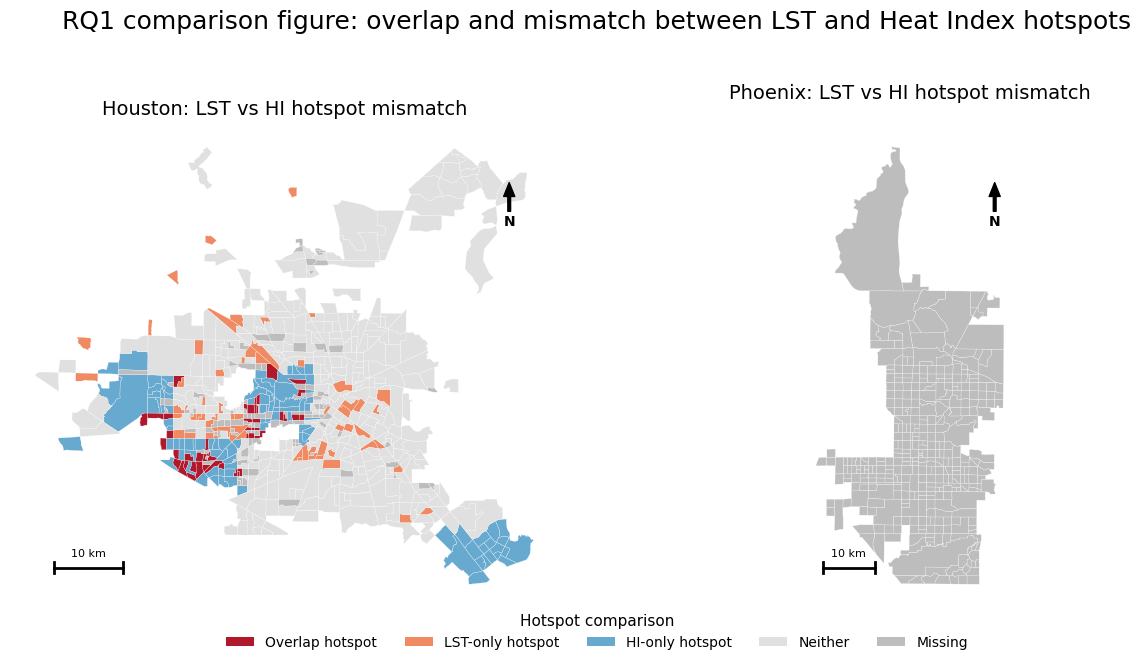


Block C file check:
/Users/yufeizhou/Desktop/heat-exposure-compare/outputs/pilot/rq1_lst_hi_hotspot_compare_qc.csv -> True
/Users/yufeizhou/Desktop/heat-exposure-compare/figures/pilot/rq1_lst_hi_hotspot_mismatch.png -> True
/Users/yufeizhou/Desktop/heat-exposure-compare/data_processed/houston/houston_master_lst_hi_hotcompare.gpkg -> True
/Users/yufeizhou/Desktop/heat-exposure-compare/data_processed/phoenix/phoenix_master_lst_hi_hotcompare.gpkg -> True

Quick interpretation:
Houston: valid tracts=549, missing=105, Jaccard=0.219
Phoenix: valid tracts=0, missing=373, Jaccard=nan


In [38]:
# ============================================================
# Block C (robust): hotspot overlap, Jaccard, and mismatch maps
# ============================================================

import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

houston_cmp = gpd.read_file(data_processed / "houston" / "houston_master_with_lst_hi.gpkg")
phoenix_cmp = gpd.read_file(data_processed / "phoenix" / "phoenix_master_with_lst_hi.gpkg")

def detect_lst_col(gdf, city_name):
    for c in ["lst_summer_median_c", "median_lst_c", "lst_median_c"]:
        if c in gdf.columns:
            return c
    raise ValueError(f"{city_name}: cannot find LST column.")

houston_lst_col = detect_lst_col(houston_cmp, "Houston")
phoenix_lst_col = detect_lst_col(phoenix_cmp, "Phoenix")

def add_hotspot_sets(gdf, lst_col, hi_col="hi_summer_median_c"):
    gdf = gdf.copy()

    valid = gdf[gdf[lst_col].notna() & gdf[hi_col].notna()].copy()

    lst_cut = valid[lst_col].quantile(0.80)
    hi_cut = valid[hi_col].quantile(0.80)

    gdf["lst_hotspot20"] = False
    gdf["hi_hotspot20"] = False

    gdf.loc[valid.index, "lst_hotspot20"] = valid[lst_col] >= lst_cut
    gdf.loc[valid.index, "hi_hotspot20"] = valid[hi_col] >= hi_cut

    gdf["hotspot_mismatch"] = "Missing"
    gdf.loc[valid.index, "hotspot_mismatch"] = "Neither"
    gdf.loc[valid.index[(valid[lst_col] >= lst_cut) & (valid[hi_col] >= hi_cut)], "hotspot_mismatch"] = "Overlap hotspot"
    gdf.loc[valid.index[(valid[lst_col] >= lst_cut) & (valid[hi_col] < hi_cut)], "hotspot_mismatch"] = "LST-only hotspot"
    gdf.loc[valid.index[(valid[lst_col] < lst_cut) & (valid[hi_col] >= hi_cut)], "hotspot_mismatch"] = "HI-only hotspot"

    intersection = int(((valid[lst_col] >= lst_cut) & (valid[hi_col] >= hi_cut)).sum())
    union = int(((valid[lst_col] >= lst_cut) | (valid[hi_col] >= hi_cut)).sum())
    jaccard = intersection / union if union > 0 else np.nan

    return gdf, lst_cut, hi_cut, intersection, union, jaccard, len(valid)

houston_hotcmp, hou_lst_cut, hou_hi_cut, hou_inter, hou_union, hou_jaccard, hou_valid_n = add_hotspot_sets(houston_cmp, houston_lst_col)
phoenix_hotcmp, phx_lst_cut, phx_hi_cut, phx_inter, phx_union, phx_jaccard, phx_valid_n = add_hotspot_sets(phoenix_cmp, phoenix_lst_col)

hotspot_compare_qc = pd.DataFrame([
    {
        "city": "Houston",
        "valid_tracts_used": hou_valid_n,
        "lst_hotspot_cut": hou_lst_cut,
        "hi_hotspot_cut": hou_hi_cut,
        "lst_hotspot_count": int((houston_hotcmp["hotspot_mismatch"].isin(["Overlap hotspot", "LST-only hotspot"])).sum()),
        "hi_hotspot_count": int((houston_hotcmp["hotspot_mismatch"].isin(["Overlap hotspot", "HI-only hotspot"])).sum()),
        "intersection_count": hou_inter,
        "union_count": hou_union,
        "jaccard_index": hou_jaccard,
        "missing_rows": int((houston_hotcmp["hotspot_mismatch"] == "Missing").sum()),
    },
    {
        "city": "Phoenix",
        "valid_tracts_used": phx_valid_n,
        "lst_hotspot_cut": phx_lst_cut,
        "hi_hotspot_cut": phx_hi_cut,
        "lst_hotspot_count": int((phoenix_hotcmp["hotspot_mismatch"].isin(["Overlap hotspot", "LST-only hotspot"])).sum()),
        "hi_hotspot_count": int((phoenix_hotcmp["hotspot_mismatch"].isin(["Overlap hotspot", "HI-only hotspot"])).sum()),
        "intersection_count": phx_inter,
        "union_count": phx_union,
        "jaccard_index": phx_jaccard,
        "missing_rows": int((phoenix_hotcmp["hotspot_mismatch"] == "Missing").sum()),
    }
])

print("Hotspot comparison QC:")
display(hotspot_compare_qc)

hotspot_compare_qc_out = output_dir / "rq1_lst_hi_hotspot_compare_qc.csv"
hotspot_compare_qc.to_csv(hotspot_compare_qc_out, index=False)

mismatch_colors = {
    "Overlap hotspot": "#b2182b",
    "LST-only hotspot": "#ef8a62",
    "HI-only hotspot": "#67a9cf",
    "Neither": "#e0e0e0",
    "Missing": "#bdbdbd",
}

fig, axes = plt.subplots(1, 2, figsize=(14, 6.8))

for ax, city_name, gdf in [
    (axes[0], "Houston", houston_hotcmp),
    (axes[1], "Phoenix", phoenix_hotcmp),
]:
    for cat, color in mismatch_colors.items():
        sub = gdf[gdf["hotspot_mismatch"] == cat]
        if len(sub) > 0:
            sub.plot(ax=ax, color=color, edgecolor="white", linewidth=0.18)

    ax.set_title(f"{city_name}: LST vs HI hotspot mismatch", fontsize=14, pad=8)
    ax.set_axis_off()
    add_north_arrow(ax)
    add_scalebar(ax, length_km=10)

handles = [Patch(facecolor=c, edgecolor="none", label=k) for k, c in mismatch_colors.items()]
fig.legend(
    handles=handles,
    title="Hotspot comparison",
    loc="lower center",
    bbox_to_anchor=(0.5, 0.02),
    ncol=5,
    frameon=False,
    fontsize=10,
    title_fontsize=11
)

fig.suptitle("RQ1 comparison figure: overlap and mismatch between LST and Heat Index hotspots", fontsize=18, y=0.98)
plt.tight_layout(rect=[0, 0.08, 1, 0.95])

hotspot_mismatch_fig_out = figure_dir / "rq1_lst_hi_hotspot_mismatch.png"
plt.savefig(hotspot_mismatch_fig_out, dpi=300, bbox_inches="tight")
plt.show()

houston_hotcmp_out = data_processed / "houston" / "houston_master_lst_hi_hotcompare.gpkg"
phoenix_hotcmp_out = data_processed / "phoenix" / "phoenix_master_lst_hi_hotcompare.gpkg"
houston_hotcmp.to_file(houston_hotcmp_out, driver="GPKG")
phoenix_hotcmp.to_file(phoenix_hotcmp_out, driver="GPKG")

print("\nBlock C file check:")
for p in [hotspot_compare_qc_out, hotspot_mismatch_fig_out, houston_hotcmp_out, phoenix_hotcmp_out]:
    print(p, "->", p.exists())

print("\nQuick interpretation:")
for _, row in hotspot_compare_qc.iterrows():
    print(
        f"{row['city']}: valid tracts={row['valid_tracts_used']}, "
        f"missing={row['missing_rows']}, "
        f"Jaccard={row['jaccard_index']:.3f}"
    )

In [39]:
from pathlib import Path
import pandas as pd
import geopandas as gpd

project_root = Path.cwd()
if not (project_root / "data_processed").exists():
    project_root = project_root.parent

data_processed = project_root / "data_processed"
output_dir = project_root / "outputs" / "pilot"

houston_master_path = data_processed / "houston" / "houston_master_with_lst_hotspot.gpkg"
phoenix_master_path = data_processed / "phoenix" / "phoenix_master_with_lst_hotspot.gpkg"

houston = gpd.read_file(houston_master_path).copy()
phoenix = gpd.read_file(phoenix_master_path).copy()

houston_hi = pd.read_csv(output_dir / "houston_hi_pilot.csv", dtype={"GEOID": str}, low_memory=False)
phoenix_hi = pd.read_csv(output_dir / "phoenix_hi_pilot.csv", dtype={"GEOID": str}, low_memory=False)

def clean_geoid(s):
    return (
        s.astype(str)
         .str.replace(r"\.0$", "", regex=True)
         .str.strip()
         .str.zfill(11)
    )

houston["GEOID"] = clean_geoid(houston["GEOID"])
phoenix["GEOID"] = clean_geoid(phoenix["GEOID"])
houston_hi["GEOID"] = clean_geoid(houston_hi["GEOID"])
phoenix_hi["GEOID"] = clean_geoid(phoenix_hi["GEOID"])

print("Houston master sample GEOID:")
print(houston["GEOID"].head().tolist())
print("Houston HI sample GEOID:")
print(houston_hi["GEOID"].head().tolist())

print("\nPhoenix master sample GEOID:")
print(phoenix["GEOID"].head().tolist())
print("Phoenix HI sample GEOID:")
print(phoenix_hi["GEOID"].head().tolist())

hou_common = set(houston["GEOID"]) & set(houston_hi["GEOID"])
phx_common = set(phoenix["GEOID"]) & set(phoenix_hi["GEOID"])

print("\nHouston common GEOIDs:", len(hou_common))
print("Phoenix common GEOIDs:", len(phx_common))

houston_test = houston.merge(
    houston_hi[["GEOID", "hi_summer_mean_c", "hi_summer_median_c"]],
    on="GEOID", how="left"
)
phoenix_test = phoenix.merge(
    phoenix_hi[["GEOID", "hi_summer_mean_c", "hi_summer_median_c"]],
    on="GEOID", how="left"
)

print("\nAfter repair merge check:")
print("Houston missing hi:", int(houston_test["hi_summer_median_c"].isna().sum()), "out of", len(houston_test))
print("Phoenix missing hi:", int(phoenix_test["hi_summer_median_c"].isna().sum()), "out of", len(phoenix_test))
print("Houston median HI:", houston_test["hi_summer_median_c"].median())
print("Phoenix median HI:", phoenix_test["hi_summer_median_c"].median())

Houston master sample GEOID:
['48201421101', '48201423301', '48201453401', '48201331100', '48201331200']
Houston HI sample GEOID:
['48201421101', '48201423301', '48201453401', '48201331100', '48201331200']

Phoenix master sample GEOID:
['04013117200', '04013082016', '04013104402', '04013104701', '04013104702']
Phoenix HI sample GEOID:
['04013117200', '04013082016', '04013104402', '04013104701', '04013104702']

Houston common GEOIDs: 654
Phoenix common GEOIDs: 373

After repair merge check:
Houston missing hi: 105 out of 654
Phoenix missing hi: 41 out of 373
Houston median HI: 34.182124562548104
Phoenix median HI: 33.3082424010499


Houston LST column: lst_summer_median_c
Phoenix LST column: lst_summer_median_c
Comparison QC:


,city,tract_rows,missing_hi_after_merge,median_lst_c,median_hi_c
0,Houston,654,105,48.531293,34.182125
1,Phoenix,373,41,57.217040,33.308242


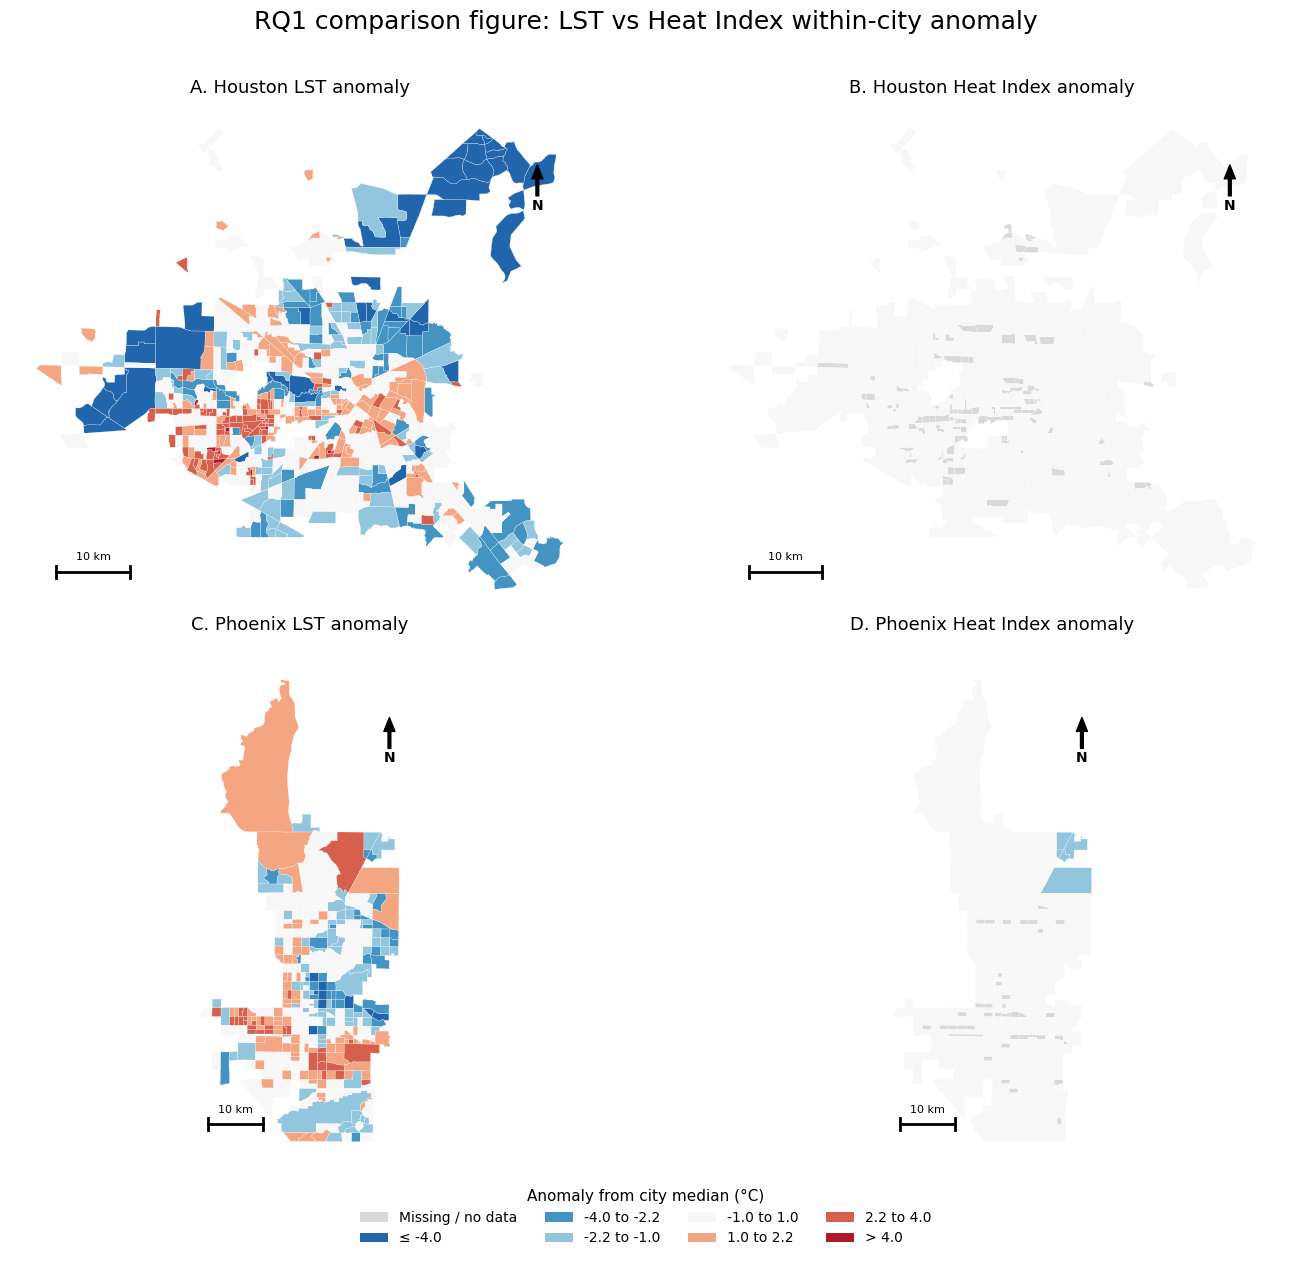


Block B2 file check:
/Users/yufeizhou/Desktop/heat-exposure-compare/figures/pilot/rq1_lst_vs_hi_anomaly_panel_fixed.png -> True
/Users/yufeizhou/Desktop/heat-exposure-compare/outputs/pilot/rq1_lst_vs_hi_comparison_qc_fixed.csv -> True
/Users/yufeizhou/Desktop/heat-exposure-compare/data_processed/houston/houston_master_with_lst_hi_fixed.gpkg -> True
/Users/yufeizhou/Desktop/heat-exposure-compare/data_processed/phoenix/phoenix_master_with_lst_hi_fixed.gpkg -> True


In [40]:
# ============================================================
# Block B2: FIXED merge + LST vs Heat Index anomaly panel
# ============================================================

from pathlib import Path
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

# ---------- locate project root ----------
project_root = Path.cwd()
if not (project_root / "data_processed").exists():
    project_root = project_root.parent

data_processed = project_root / "data_processed"
output_dir = project_root / "outputs" / "pilot"
figure_dir = project_root / "figures" / "pilot"
figure_dir.mkdir(parents=True, exist_ok=True)

# ---------- helper ----------
def clean_geoid(s):
    return (
        s.astype(str)
         .str.replace(r"\.0$", "", regex=True)
         .str.strip()
         .str.zfill(11)
    )

def detect_lst_col(gdf, city_name):
    for c in ["lst_summer_median_c", "median_lst_c", "lst_median_c"]:
        if c in gdf.columns:
            return c
    raise ValueError(f"{city_name}: cannot find LST column. Available columns: {list(gdf.columns)}")

def add_north_arrow(ax, x=0.91, y=0.88, size=0.08):
    ax.annotate(
        "N",
        xy=(x, y), xytext=(x, y - size),
        xycoords="axes fraction",
        textcoords="axes fraction",
        ha="center", va="center",
        fontsize=10, fontweight="bold",
        arrowprops=dict(facecolor="black", width=2, headwidth=8, headlength=10)
    )

def add_scalebar(ax, length_km=10, location=(0.08, 0.08), linewidth=2):
    xmin, xmax = ax.get_xlim()
    ymin, ymax = ax.get_ylim()
    x0 = xmin + (xmax - xmin) * location[0]
    y0 = ymin + (ymax - ymin) * location[1]
    length_m = length_km * 1000
    tick_h = (ymax - ymin) * 0.012

    ax.plot([x0, x0 + length_m], [y0, y0], color="black", linewidth=linewidth)
    ax.plot([x0, x0], [y0 - tick_h, y0 + tick_h], color="black", linewidth=linewidth)
    ax.plot([x0 + length_m, x0 + length_m], [y0 - tick_h, y0 + tick_h], color="black", linewidth=linewidth)
    ax.text(x0 + length_m / 2, y0 + tick_h * 1.6, f"{length_km} km", ha="center", va="bottom", fontsize=8)

# ---------- input paths ----------
houston_master_path = data_processed / "houston" / "houston_master_with_lst_hotspot.gpkg"
phoenix_master_path = data_processed / "phoenix" / "phoenix_master_with_lst_hotspot.gpkg"

houston_hi_csv = output_dir / "houston_hi_pilot.csv"
phoenix_hi_csv = output_dir / "phoenix_hi_pilot.csv"

# ---------- read ----------
houston = gpd.read_file(houston_master_path).copy()
phoenix = gpd.read_file(phoenix_master_path).copy()

houston_hi = pd.read_csv(houston_hi_csv, dtype={"GEOID": str}, low_memory=False)
phoenix_hi = pd.read_csv(phoenix_hi_csv, dtype={"GEOID": str}, low_memory=False)

houston["GEOID"] = clean_geoid(houston["GEOID"])
phoenix["GEOID"] = clean_geoid(phoenix["GEOID"])
houston_hi["GEOID"] = clean_geoid(houston_hi["GEOID"])
phoenix_hi["GEOID"] = clean_geoid(phoenix_hi["GEOID"])

houston_lst_col = detect_lst_col(houston, "Houston")
phoenix_lst_col = detect_lst_col(phoenix, "Phoenix")

print("Houston LST column:", houston_lst_col)
print("Phoenix LST column:", phoenix_lst_col)

# ---------- merge ----------
houston_cmp = houston.merge(
    houston_hi[["GEOID", "hi_summer_mean_c", "hi_summer_median_c"]],
    on="GEOID",
    how="left"
).copy()

phoenix_cmp = phoenix.merge(
    phoenix_hi[["GEOID", "hi_summer_mean_c", "hi_summer_median_c"]],
    on="GEOID",
    how="left"
).copy()

# ---------- anomalies ----------
houston_cmp["lst_anomaly"] = houston_cmp[houston_lst_col] - houston_cmp[houston_lst_col].median()
phoenix_cmp["lst_anomaly"] = phoenix_cmp[phoenix_lst_col] - phoenix_cmp[phoenix_lst_col].median()

houston_cmp["hi_anomaly"] = houston_cmp["hi_summer_median_c"] - houston_cmp["hi_summer_median_c"].median()
phoenix_cmp["hi_anomaly"] = phoenix_cmp["hi_summer_median_c"] - phoenix_cmp["hi_summer_median_c"].median()

comparison_qc = pd.DataFrame([
    {
        "city": "Houston",
        "tract_rows": len(houston_cmp),
        "missing_hi_after_merge": int(houston_cmp["hi_summer_median_c"].isna().sum()),
        "median_lst_c": float(houston_cmp[houston_lst_col].median()),
        "median_hi_c": float(houston_cmp["hi_summer_median_c"].median()),
    },
    {
        "city": "Phoenix",
        "tract_rows": len(phoenix_cmp),
        "missing_hi_after_merge": int(phoenix_cmp["hi_summer_median_c"].isna().sum()),
        "median_lst_c": float(phoenix_cmp[phoenix_lst_col].median()),
        "median_hi_c": float(phoenix_cmp["hi_summer_median_c"].median()),
    }
])

print("Comparison QC:")
display(comparison_qc)

# ---------- common bins across all valid anomaly values ----------
all_abs = pd.concat([
    houston_cmp["lst_anomaly"].abs(),
    phoenix_cmp["lst_anomaly"].abs(),
    houston_cmp["hi_anomaly"].abs(),
    phoenix_cmp["hi_anomaly"].abs()
], ignore_index=True).dropna()

vmax = float(np.nanpercentile(all_abs, 95))
vmax = max(vmax, 2.0)
vmax = np.ceil(vmax * 2) / 2

b1 = round(vmax * 0.25, 1)
b2 = round(vmax * 0.55, 1)
b3 = round(vmax, 1)

bins = [-np.inf, -b3, -b2, -b1, b1, b2, b3, np.inf]
labels = [
    f"≤ -{b3}",
    f"-{b3} to -{b2}",
    f"-{b2} to -{b1}",
    f"-{b1} to {b1}",
    f"{b1} to {b2}",
    f"{b2} to {b3}",
    f"> {b3}"
]
colors = {
    f"≤ -{b3}": "#2166ac",
    f"-{b3} to -{b2}": "#4393c3",
    f"-{b2} to -{b1}": "#92c5de",
    f"-{b1} to {b1}": "#f7f7f7",
    f"{b1} to {b2}": "#f4a582",
    f"{b2} to {b3}": "#d6604d",
    f"> {b3}": "#b2182b"
}

for gdf in [houston_cmp, phoenix_cmp]:
    gdf["lst_anom_class"] = pd.cut(gdf["lst_anomaly"], bins=bins, labels=labels, include_lowest=True)
    gdf["hi_anom_class"] = pd.cut(gdf["hi_anomaly"], bins=bins, labels=labels, include_lowest=True)

# ---------- plotting helper ----------
def plot_class_map(ax, gdf, class_col, title):
    missing = gdf[gdf[class_col].isna()]
    if len(missing) > 0:
        missing.plot(ax=ax, color="#d9d9d9", edgecolor="white", linewidth=0.18)

    for lab in labels:
        sub = gdf[gdf[class_col] == lab]
        if len(sub) > 0:
            sub.plot(ax=ax, color=colors[lab], edgecolor="white", linewidth=0.18)

    ax.set_title(title, fontsize=13, pad=8)
    ax.set_axis_off()
    add_north_arrow(ax)
    add_scalebar(ax, length_km=10)

# ---------- figure ----------
fig, axes = plt.subplots(2, 2, figsize=(14, 13))

plot_class_map(axes[0, 0], houston_cmp, "lst_anom_class", "A. Houston LST anomaly")
plot_class_map(axes[0, 1], houston_cmp, "hi_anom_class", "B. Houston Heat Index anomaly")
plot_class_map(axes[1, 0], phoenix_cmp, "lst_anom_class", "C. Phoenix LST anomaly")
plot_class_map(axes[1, 1], phoenix_cmp, "hi_anom_class", "D. Phoenix Heat Index anomaly")

handles = [Patch(facecolor="#d9d9d9", edgecolor="none", label="Missing / no data")]
handles += [Patch(facecolor=colors[l], edgecolor="none", label=l) for l in labels]

fig.legend(
    handles=handles,
    title="Anomaly from city median (°C)",
    loc="lower center",
    bbox_to_anchor=(0.5, 0.02),
    ncol=4,
    frameon=False,
    fontsize=10,
    title_fontsize=11
)

fig.suptitle("RQ1 comparison figure: LST vs Heat Index within-city anomaly", fontsize=18, y=0.98)
plt.tight_layout(rect=[0, 0.08, 1, 0.96])

lst_hi_compare_out = figure_dir / "rq1_lst_vs_hi_anomaly_panel_fixed.png"
plt.savefig(lst_hi_compare_out, dpi=300, bbox_inches="tight")
plt.show()

# ---------- save ----------
comparison_qc_out = output_dir / "rq1_lst_vs_hi_comparison_qc_fixed.csv"
comparison_qc.to_csv(comparison_qc_out, index=False)

houston_cmp_out = data_processed / "houston" / "houston_master_with_lst_hi_fixed.gpkg"
phoenix_cmp_out = data_processed / "phoenix" / "phoenix_master_with_lst_hi_fixed.gpkg"
houston_cmp.to_file(houston_cmp_out, driver="GPKG")
phoenix_cmp.to_file(phoenix_cmp_out, driver="GPKG")

print("\nBlock B2 file check:")
for p in [lst_hi_compare_out, comparison_qc_out, houston_cmp_out, phoenix_cmp_out]:
    print(p, "->", p.exists())

Project root: /Users/yufeizhou/Desktop/heat-exposure-compare
Houston base: /Users/yufeizhou/Desktop/heat-exposure-compare/data_processed/houston/houston_master_demo_poverty.gpkg
Phoenix base: /Users/yufeizhou/Desktop/heat-exposure-compare/data_processed/phoenix/phoenix_master_demo_poverty.gpkg
Houston LST csv: /Users/yufeizhou/Desktop/heat-exposure-compare/outputs/pilot/houston_landsat_lst_pilot.csv
Phoenix LST csv: /Users/yufeizhou/Desktop/heat-exposure-compare/outputs/pilot/phoenix_landsat_lst_pilot.csv
Houston HI csv: /Users/yufeizhou/Desktop/heat-exposure-compare/outputs/pilot/houston_hi_pilot.csv
Phoenix HI csv: /Users/yufeizhou/Desktop/heat-exposure-compare/outputs/pilot/phoenix_hi_pilot.csv

Fresh fixed gpkg saved:
/Users/yufeizhou/Desktop/heat-exposure-compare/data_processed/houston/houston_master_with_lst_hi_fixed.gpkg -> True
/Users/yufeizhou/Desktop/heat-exposure-compare/data_processed/phoenix/phoenix_master_with_lst_hi_fixed.gpkg -> True

LST bins used: [-inf, -2.62, -1.35,

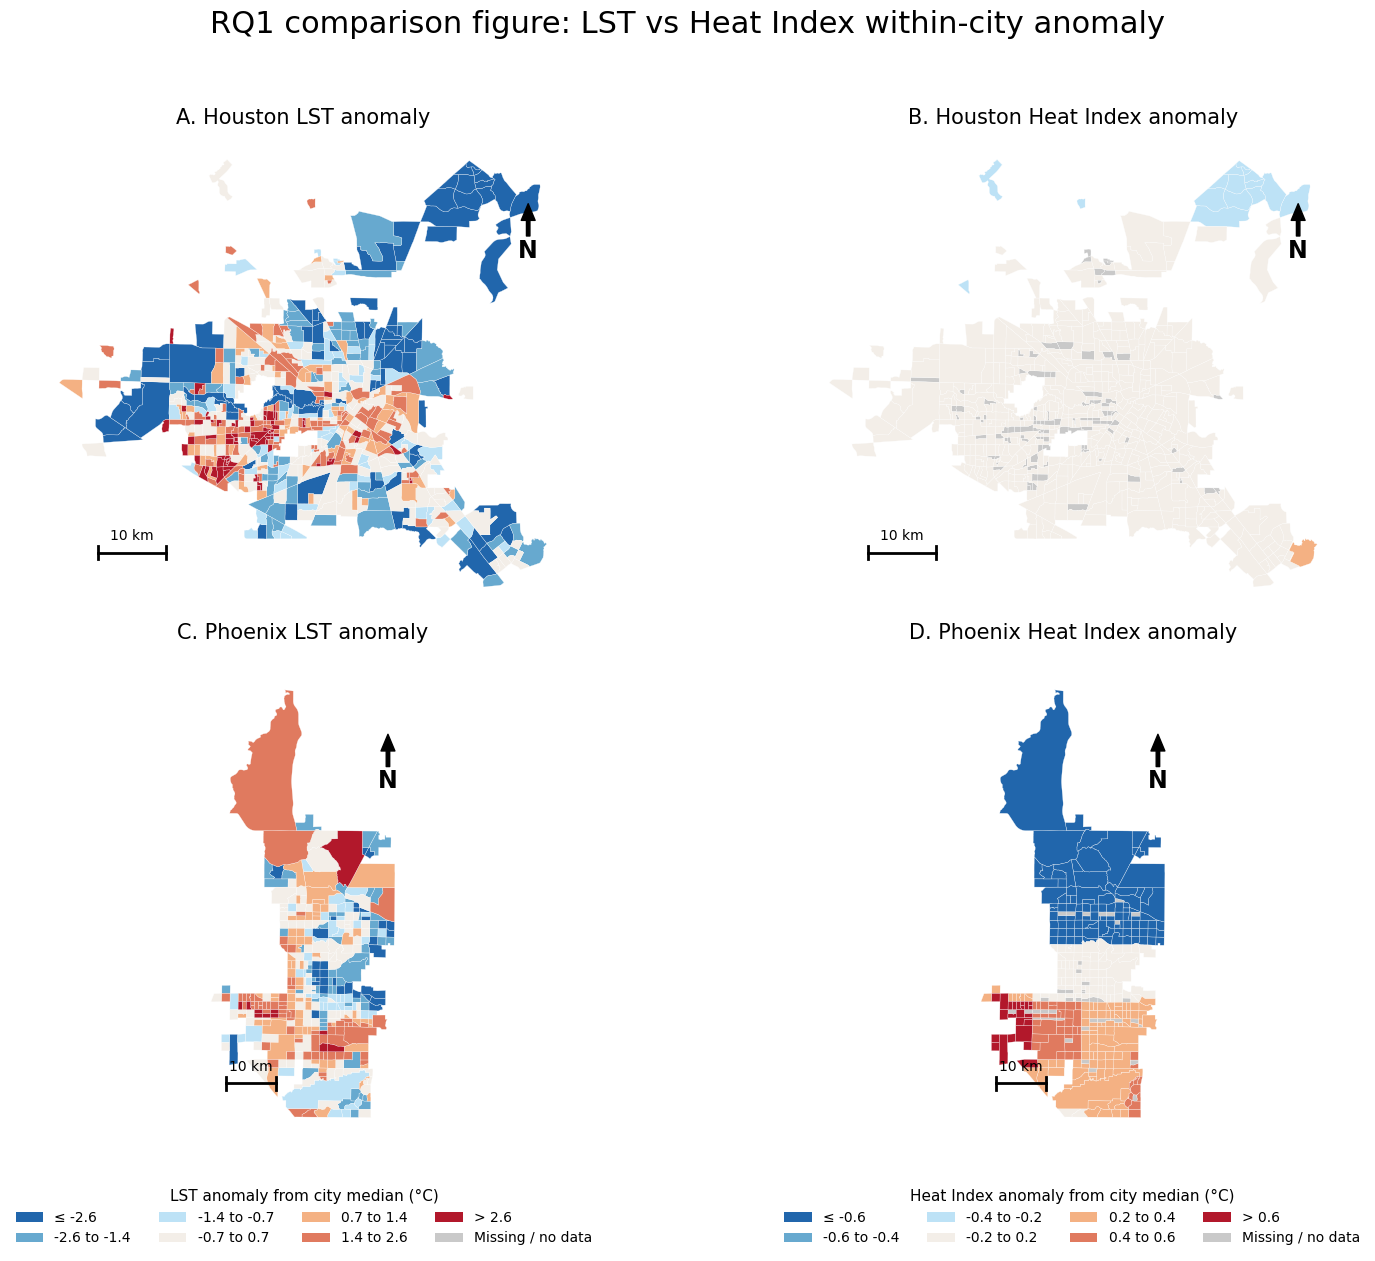

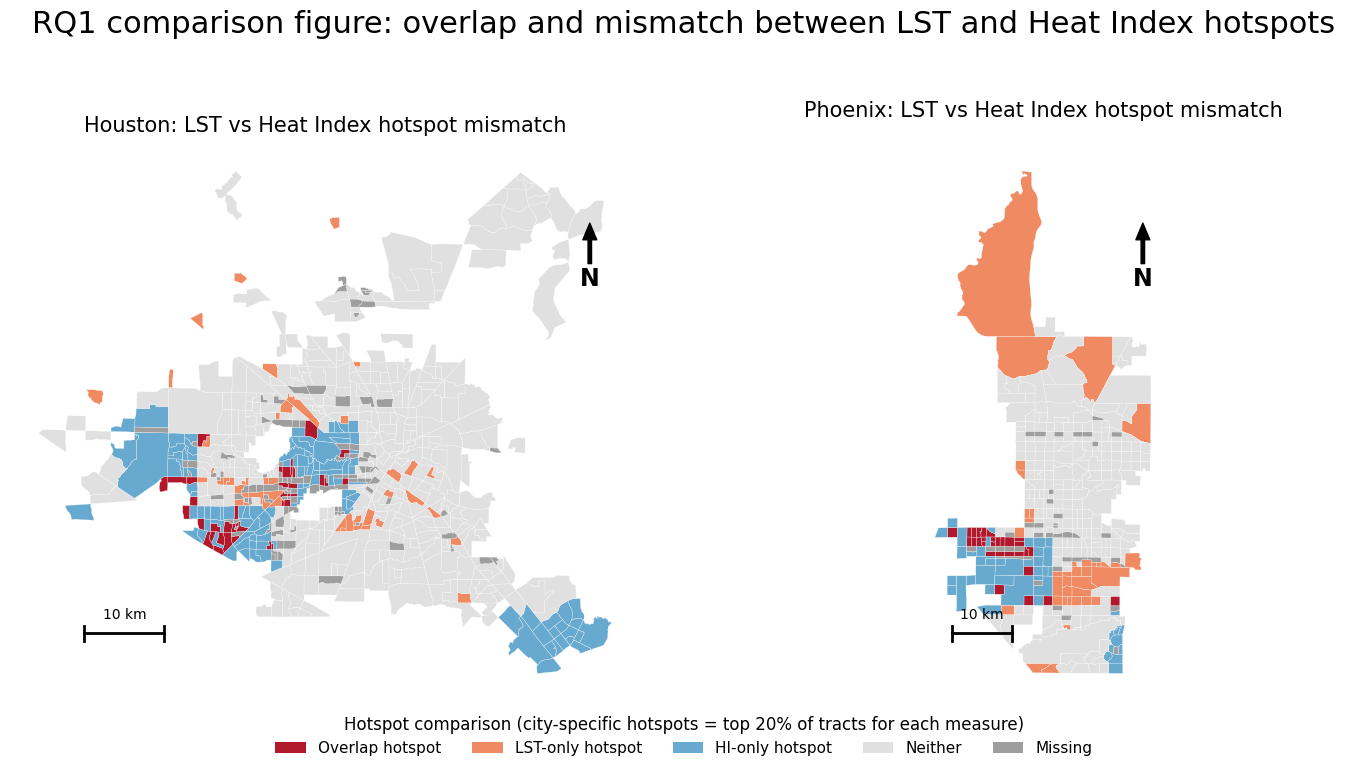


================ FINAL OUTPUT FILE CHECK ================
/Users/yufeizhou/Desktop/heat-exposure-compare/figures/pilot/teacher_ready_lst_vs_hi_anomaly.png -> True
/Users/yufeizhou/Desktop/heat-exposure-compare/figures/pilot/teacher_ready_lst_vs_hi_hotspot_compare.png -> True
/Users/yufeizhou/Desktop/heat-exposure-compare/outputs/pilot/teacher_ready_lst_hi_compare_qc.csv -> True
/Users/yufeizhou/Desktop/heat-exposure-compare/data_processed/houston/houston_master_with_lst_hi_fixed.gpkg -> True
/Users/yufeizhou/Desktop/heat-exposure-compare/data_processed/phoenix/phoenix_master_with_lst_hi_fixed.gpkg -> True

QC preview:


,section,city,tract_rows,missing_lst,missing_hi,city_median_lst_c,city_median_hi_c,lst_anomaly_min,lst_anomaly_max,hi_anomaly_min,hi_anomaly_max,lst_hotspot_threshold_c,hi_hotspot_threshold_c,overlap_hotspot_count,lst_only_hotspot_count,hi_only_hotspot_count,neither_count,missing_count
0,anomaly_base,Houston,654,0,105,48.531,34.182,-14.599,4.950,-0.377,0.374,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,anomaly_base,Phoenix,373,0,41,57.217,33.308,-5.776,3.249,-2.002,0.879,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,hotspot_compare,Houston,654,0,105,NaN,NaN,NaN,NaN,NaN,NaN,50.315,34.198,38.0,45.0,108.0,358.0,105.0
3,hotspot_compare,Phoenix,373,0,41,NaN,NaN,NaN,NaN,NaN,NaN,58.607,33.694,29.0,37.0,44.0,222.0,41.0


In [42]:
# ============================================================
# FINAL REPLACEMENT CELL
# Teacher-ready LST vs Heat Index comparison for RQ1
# ============================================================

from pathlib import Path
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

# ----------------------------
# 0) locate project root
# ----------------------------
project_root = Path.cwd()
if not (project_root / "outputs").exists():
    project_root = project_root.parent

figure_dir = project_root / "figures" / "pilot"
output_dir = project_root / "outputs" / "pilot"
data_processed = project_root / "data_processed"

figure_dir.mkdir(parents=True, exist_ok=True)
output_dir.mkdir(parents=True, exist_ok=True)

print("Project root:", project_root)

# ----------------------------
# 1) helpers
# ----------------------------
def find_existing(paths):
    for p in paths:
        if p.exists():
            return p
    raise FileNotFoundError("No existing path found among:\n" + "\n".join(str(p) for p in paths))

def std_geoid(s):
    return (
        s.fillna("")
         .astype(str)
         .str.replace(".0", "", regex=False)
         .str.strip()
         .str.zfill(11)
    )

def first_existing_col(df, candidates, label):
    for c in candidates:
        if c in df.columns:
            return c
    raise KeyError(f"Cannot find {label}. Tried: {candidates}\nAvailable columns:\n{list(df.columns)}")

def add_north_arrow(ax, x=0.92, y=0.86, size=17):
    ax.annotate(
        "N",
        xy=(x, y),
        xytext=(x, y - 0.10),
        xycoords="axes fraction",
        textcoords="axes fraction",
        ha="center",
        va="center",
        fontsize=size,
        fontweight="bold",
        arrowprops=dict(facecolor="black", width=2.5, headwidth=10, headlength=12)
    )

def add_scale_bar(ax, gdf, length_km=10):
    """
    Assume projected CRS in meters.
    """
    xmin, ymin, xmax, ymax = gdf.total_bounds
    length_m = length_km * 1000

    x0 = xmin + (xmax - xmin) * 0.08
    y0 = ymin + (ymax - ymin) * 0.08
    tick = (ymax - ymin) * 0.015

    ax.plot([x0, x0 + length_m], [y0, y0], color="black", linewidth=2)
    ax.plot([x0, x0], [y0 - tick, y0 + tick], color="black", linewidth=2)
    ax.plot([x0 + length_m, x0 + length_m], [y0 - tick, y0 + tick], color="black", linewidth=2)
    ax.text(x0 + length_m / 2, y0 + tick * 1.5, f"{length_km} km", ha="center", va="bottom", fontsize=10)

def robust_symmetric_bins(series, quantiles=(0.25, 0.50, 0.80), min_step=0.2):
    """
    Build strictly increasing symmetric bins around 0.
    Prevent duplicated bin edges like -0.0 / 0.0.
    """
    vals = pd.Series(series).dropna().astype(float).to_numpy()
    if len(vals) == 0:
        raise ValueError("No non-missing values available to build bins.")

    abs_vals = np.abs(vals)
    qs = np.quantile(abs_vals, quantiles)

    clean_qs = []
    prev = 0.0
    for q in qs:
        q = float(q)

        if q < min_step:
            q = min_step

        if q <= prev:
            q = prev + min_step

        q = round(q, 2)
        clean_qs.append(q)
        prev = q

    a, b, c = clean_qs

    if not (0 < a < b < c):
        a = round(min_step, 2)
        b = round(a + min_step, 2)
        c = round(b + min_step, 2)

    bins = [-np.inf, -c, -b, -a, a, b, c, np.inf]
    return bins

def labels_from_bins(bins):
    labels = []
    for i in range(len(bins) - 1):
        lo = bins[i]
        hi = bins[i + 1]
        if np.isneginf(lo):
            labels.append(f"≤ {hi:.1f}")
        elif np.isposinf(hi):
            labels.append(f"> {lo:.1f}")
        else:
            labels.append(f"{lo:.1f} to {hi:.1f}")
    return labels

def classify_with_bins(series, bins):
    bins = np.array(bins, dtype=float)

    if not np.all(np.diff(bins) > 0):
        raise ValueError(f"Bins are not strictly increasing: {bins}")

    labels = labels_from_bins(bins)
    out = pd.cut(series, bins=bins, labels=labels, include_lowest=True)
    return out, labels

def plot_class_map(ax, gdf, class_col, title, category_order, color_map, missing_color="#c9c9c9"):
    miss = gdf[gdf[class_col].isna()]
    if len(miss) > 0:
        miss.plot(ax=ax, color=missing_color, edgecolor="white", linewidth=0.20)

    for cat in category_order:
        sub = gdf[gdf[class_col] == cat]
        if len(sub) > 0:
            sub.plot(ax=ax, color=color_map[cat], edgecolor="white", linewidth=0.20)

    ax.set_title(title, fontsize=15, pad=10)
    ax.set_axis_off()
    add_north_arrow(ax)
    add_scale_bar(ax, gdf, length_km=10)

# ----------------------------
# 2) input paths
# ----------------------------
houston_base = find_existing([
    data_processed / "houston" / "houston_master_demo_poverty.gpkg",
    data_processed / "houston" / "houston_master_with_lst_hotspot.gpkg",
    data_processed / "houston" / "houston_master_demo.gpkg",
])

phoenix_base = find_existing([
    data_processed / "phoenix" / "phoenix_master_demo_poverty.gpkg",
    data_processed / "phoenix" / "phoenix_master_with_lst_hotspot.gpkg",
    data_processed / "phoenix" / "phoenix_master_demo.gpkg",
])

houston_lst_csv = find_existing([
    output_dir / "houston_landsat_lst_pilot.csv",
])

phoenix_lst_csv = find_existing([
    output_dir / "phoenix_landsat_lst_pilot.csv",
])

houston_hi_csv = find_existing([
    output_dir / "houston_hi_pilot.csv",
])

phoenix_hi_csv = find_existing([
    output_dir / "phoenix_hi_pilot.csv",
])

print("Houston base:", houston_base)
print("Phoenix base:", phoenix_base)
print("Houston LST csv:", houston_lst_csv)
print("Phoenix LST csv:", phoenix_lst_csv)
print("Houston HI csv:", houston_hi_csv)
print("Phoenix HI csv:", phoenix_hi_csv)

# ----------------------------
# 3) rebuild fresh city GeoDataFrames
# ----------------------------
def build_city_gdf(city_name, base_path, lst_csv_path, hi_csv_path):
    gdf = gpd.read_file(base_path).copy()

    geoid_base_col = first_existing_col(gdf, ["GEOID", "geoid"], f"{city_name} base GEOID")
    gdf["GEOID"] = std_geoid(gdf[geoid_base_col])

    lst_df = pd.read_csv(lst_csv_path, dtype={"GEOID": str}, low_memory=False)
    geoid_lst_col = first_existing_col(lst_df, ["GEOID", "geoid"], f"{city_name} LST GEOID")
    lst_df["GEOID"] = std_geoid(lst_df[geoid_lst_col])

    lst_value_col = first_existing_col(
        lst_df,
        [
            "lst_summer_median_c",
            "median_lst_c",
            "lst_median_c",
            "median_lst"
        ],
        f"{city_name} LST median column"
    )
    lst_keep = lst_df[["GEOID", lst_value_col]].copy()
    lst_keep = lst_keep.rename(columns={lst_value_col: "lst_c"})
    lst_keep["lst_c"] = pd.to_numeric(lst_keep["lst_c"], errors="coerce")

    hi_df = pd.read_csv(hi_csv_path, dtype={"GEOID": str}, low_memory=False)
    geoid_hi_col = first_existing_col(hi_df, ["GEOID", "geoid"], f"{city_name} HI GEOID")
    hi_df["GEOID"] = std_geoid(hi_df[geoid_hi_col])

    hi_value_col = first_existing_col(
        hi_df,
        [
            "hi_summer_median_c",
            "median_hi_c",
            "hi_median_c",
            "median_heat_index_c",
            "heat_index_median_c"
        ],
        f"{city_name} HI median column"
    )
    hi_keep = hi_df[["GEOID", hi_value_col]].copy()
    hi_keep = hi_keep.rename(columns={hi_value_col: "hi_c"})
    hi_keep["hi_c"] = pd.to_numeric(hi_keep["hi_c"], errors="coerce")

    out = gdf.merge(lst_keep, on="GEOID", how="left")
    out = out.merge(hi_keep, on="GEOID", how="left")
    out["city"] = city_name

    out["lst_c"] = pd.to_numeric(out["lst_c"], errors="coerce")
    out["hi_c"] = pd.to_numeric(out["hi_c"], errors="coerce")

    return out

houston = build_city_gdf("Houston", houston_base, houston_lst_csv, houston_hi_csv)
phoenix = build_city_gdf("Phoenix", phoenix_base, phoenix_lst_csv, phoenix_hi_csv)

# save fresh merged files
houston_fixed_gpkg = data_processed / "houston" / "houston_master_with_lst_hi_fixed.gpkg"
phoenix_fixed_gpkg = data_processed / "phoenix" / "phoenix_master_with_lst_hi_fixed.gpkg"
houston.to_file(houston_fixed_gpkg, driver="GPKG")
phoenix.to_file(phoenix_fixed_gpkg, driver="GPKG")

print("\nFresh fixed gpkg saved:")
print(houston_fixed_gpkg, "->", houston_fixed_gpkg.exists())
print(phoenix_fixed_gpkg, "->", phoenix_fixed_gpkg.exists())

# ----------------------------
# 4) anomaly variables
# ----------------------------
for gdf in [houston, phoenix]:
    gdf["lst_anom"] = gdf["lst_c"] - gdf["lst_c"].median()
    gdf["hi_anom"] = gdf["hi_c"] - gdf["hi_c"].median()

# Build bins separately for LST and HI
all_lst_anom = pd.concat([houston["lst_anom"], phoenix["lst_anom"]], ignore_index=True)
all_hi_anom  = pd.concat([houston["hi_anom"], phoenix["hi_anom"]], ignore_index=True)

lst_bins = robust_symmetric_bins(all_lst_anom, quantiles=(0.25, 0.50, 0.80), min_step=0.2)
hi_bins  = robust_symmetric_bins(all_hi_anom, quantiles=(0.25, 0.50, 0.80), min_step=0.2)

houston["lst_anom_class"], lst_labels = classify_with_bins(houston["lst_anom"], lst_bins)
phoenix["lst_anom_class"], _          = classify_with_bins(phoenix["lst_anom"], lst_bins)

houston["hi_anom_class"], hi_labels = classify_with_bins(houston["hi_anom"], hi_bins)
phoenix["hi_anom_class"], _         = classify_with_bins(phoenix["hi_anom"], hi_bins)

print("\nLST bins used:", lst_bins)
print("HI bins used:", hi_bins)

# separate color maps
anomaly_colors = [
    "#2166ac",  # deep blue
    "#67a9cf",  # blue
    "#bde2f6",  # light blue
    "#f3eee8",  # soft neutral center (not white)
    "#f4b183",  # light orange
    "#e07a5f",  # orange-red
    "#b2182b",  # deep red
]

lst_color_map = {lab: col for lab, col in zip(lst_labels, anomaly_colors)}
hi_color_map  = {lab: col for lab, col in zip(hi_labels, anomaly_colors)}

# ----------------------------
# 5) Figure 1: anomaly comparison
# ----------------------------
fig, axes = plt.subplots(2, 2, figsize=(16, 13))

plot_class_map(
    axes[0, 0], houston, "lst_anom_class",
    "A. Houston LST anomaly",
    lst_labels, lst_color_map, missing_color="#c9c9c9"
)
plot_class_map(
    axes[0, 1], houston, "hi_anom_class",
    "B. Houston Heat Index anomaly",
    hi_labels, hi_color_map, missing_color="#c9c9c9"
)
plot_class_map(
    axes[1, 0], phoenix, "lst_anom_class",
    "C. Phoenix LST anomaly",
    lst_labels, lst_color_map, missing_color="#c9c9c9"
)
plot_class_map(
    axes[1, 1], phoenix, "hi_anom_class",
    "D. Phoenix Heat Index anomaly",
    hi_labels, hi_color_map, missing_color="#c9c9c9"
)

fig.suptitle("RQ1 comparison figure: LST vs Heat Index within-city anomaly", fontsize=22, y=0.98)

lst_handles = [Patch(facecolor=lst_color_map[l], edgecolor="none", label=l) for l in lst_labels]
hi_handles  = [Patch(facecolor=hi_color_map[l], edgecolor="none", label=l) for l in hi_labels]
missing_handle = Patch(facecolor="#c9c9c9", edgecolor="none", label="Missing / no data")

fig.legend(
    handles=lst_handles + [missing_handle],
    loc="lower center",
    bbox_to_anchor=(0.26, 0.02),
    ncol=4,
    title="LST anomaly from city median (°C)",
    frameon=False,
    fontsize=10,
    title_fontsize=11
)
fig.legend(
    handles=hi_handles + [missing_handle],
    loc="lower center",
    bbox_to_anchor=(0.74, 0.02),
    ncol=4,
    title="Heat Index anomaly from city median (°C)",
    frameon=False,
    fontsize=10,
    title_fontsize=11
)

plt.tight_layout(rect=[0, 0.10, 1, 0.95])

fig1_out = figure_dir / "teacher_ready_lst_vs_hi_anomaly.png"
plt.savefig(fig1_out, dpi=300, bbox_inches="tight")
plt.show()

# ----------------------------
# 6) hotspot overlap / mismatch
# ----------------------------
def build_hotspot_compare(gdf):
    out = gdf.copy()

    valid_lst = out["lst_c"].notna()
    valid_hi = out["hi_c"].notna()

    lst_thresh = out.loc[valid_lst, "lst_c"].quantile(0.80)
    hi_thresh  = out.loc[valid_hi, "hi_c"].quantile(0.80)

    out["lst_hot"] = False
    out["hi_hot"] = False
    out.loc[valid_lst, "lst_hot"] = out.loc[valid_lst, "lst_c"] >= lst_thresh
    out.loc[valid_hi, "hi_hot"] = out.loc[valid_hi, "hi_c"] >= hi_thresh

    out["cmp_class"] = "Neither"
    out.loc[out["lst_c"].isna() | out["hi_c"].isna(), "cmp_class"] = "Missing"
    out.loc[(out["lst_hot"]) & (out["hi_hot"]), "cmp_class"] = "Overlap hotspot"
    out.loc[(out["lst_hot"]) & (~out["hi_hot"]) & out["hi_c"].notna(), "cmp_class"] = "LST-only hotspot"
    out.loc[(~out["lst_hot"]) & (out["hi_hot"]) & out["lst_c"].notna(), "cmp_class"] = "HI-only hotspot"

    qc = {
        "city": out["city"].iloc[0],
        "tract_rows": len(out),
        "missing_lst": int(out["lst_c"].isna().sum()),
        "missing_hi": int(out["hi_c"].isna().sum()),
        "lst_hotspot_threshold_c": round(float(lst_thresh), 3),
        "hi_hotspot_threshold_c": round(float(hi_thresh), 3),
        "overlap_hotspot_count": int((out["cmp_class"] == "Overlap hotspot").sum()),
        "lst_only_hotspot_count": int((out["cmp_class"] == "LST-only hotspot").sum()),
        "hi_only_hotspot_count": int((out["cmp_class"] == "HI-only hotspot").sum()),
        "neither_count": int((out["cmp_class"] == "Neither").sum()),
        "missing_count": int((out["cmp_class"] == "Missing").sum()),
    }
    return out, qc

houston_cmp, houston_cmp_qc = build_hotspot_compare(houston)
phoenix_cmp, phoenix_cmp_qc = build_hotspot_compare(phoenix)

cmp_order = ["Overlap hotspot", "LST-only hotspot", "HI-only hotspot", "Neither", "Missing"]
cmp_colors = {
    "Overlap hotspot": "#b2182b",
    "LST-only hotspot": "#ef8a62",
    "HI-only hotspot": "#67a9cf",
    "Neither": "#e0e0e0",
    "Missing": "#9e9e9e",
}

fig, axes = plt.subplots(1, 2, figsize=(16, 8))

plot_class_map(
    axes[0], houston_cmp, "cmp_class",
    "Houston: LST vs Heat Index hotspot mismatch",
    cmp_order, cmp_colors, missing_color="#9e9e9e"
)
plot_class_map(
    axes[1], phoenix_cmp, "cmp_class",
    "Phoenix: LST vs Heat Index hotspot mismatch",
    cmp_order, cmp_colors, missing_color="#9e9e9e"
)

fig.suptitle("RQ1 comparison figure: overlap and mismatch between LST and Heat Index hotspots", fontsize=22, y=0.98)

cmp_handles = [Patch(facecolor=cmp_colors[c], edgecolor="none", label=c) for c in cmp_order]
fig.legend(
    handles=cmp_handles,
    loc="lower center",
    bbox_to_anchor=(0.5, 0.03),
    ncol=5,
    title="Hotspot comparison (city-specific hotspots = top 20% of tracts for each measure)",
    frameon=False,
    fontsize=11,
    title_fontsize=12
)

plt.tight_layout(rect=[0, 0.10, 1, 0.94])

fig2_out = figure_dir / "teacher_ready_lst_vs_hi_hotspot_compare.png"
plt.savefig(fig2_out, dpi=300, bbox_inches="tight")
plt.show()

# ----------------------------
# 7) QC table
# ----------------------------
qc_rows = []

for gdf in [houston, phoenix]:
    qc_rows.append({
        "section": "anomaly_base",
        "city": gdf["city"].iloc[0],
        "tract_rows": len(gdf),
        "missing_lst": int(gdf["lst_c"].isna().sum()),
        "missing_hi": int(gdf["hi_c"].isna().sum()),
        "city_median_lst_c": round(float(gdf["lst_c"].median()), 3),
        "city_median_hi_c": round(float(gdf["hi_c"].median()), 3),
        "lst_anomaly_min": round(float(gdf["lst_anom"].min()), 3),
        "lst_anomaly_max": round(float(gdf["lst_anom"].max()), 3),
        "hi_anomaly_min": round(float(gdf["hi_anom"].min()), 3),
        "hi_anomaly_max": round(float(gdf["hi_anom"].max()), 3),
    })

for row in [houston_cmp_qc, phoenix_cmp_qc]:
    row = row.copy()
    row["section"] = "hotspot_compare"
    qc_rows.append(row)

qc_df = pd.DataFrame(qc_rows)
qc_out = output_dir / "teacher_ready_lst_hi_compare_qc.csv"
qc_df.to_csv(qc_out, index=False)

print("\n================ FINAL OUTPUT FILE CHECK ================")
for p in [fig1_out, fig2_out, qc_out, houston_fixed_gpkg, phoenix_fixed_gpkg]:
    print(p, "->", p.exists())

print("\nQC preview:")
display(qc_df)

Houston LST column: lst_c
Houston HI column: hi_c
Phoenix LST column: lst_c
Phoenix HI column: hi_c
LST bins: [33.899999 47.7      49.3      51.7      57.       60.500001]
HI bins: [31.299999 33.3      34.1      34.2      34.600001]


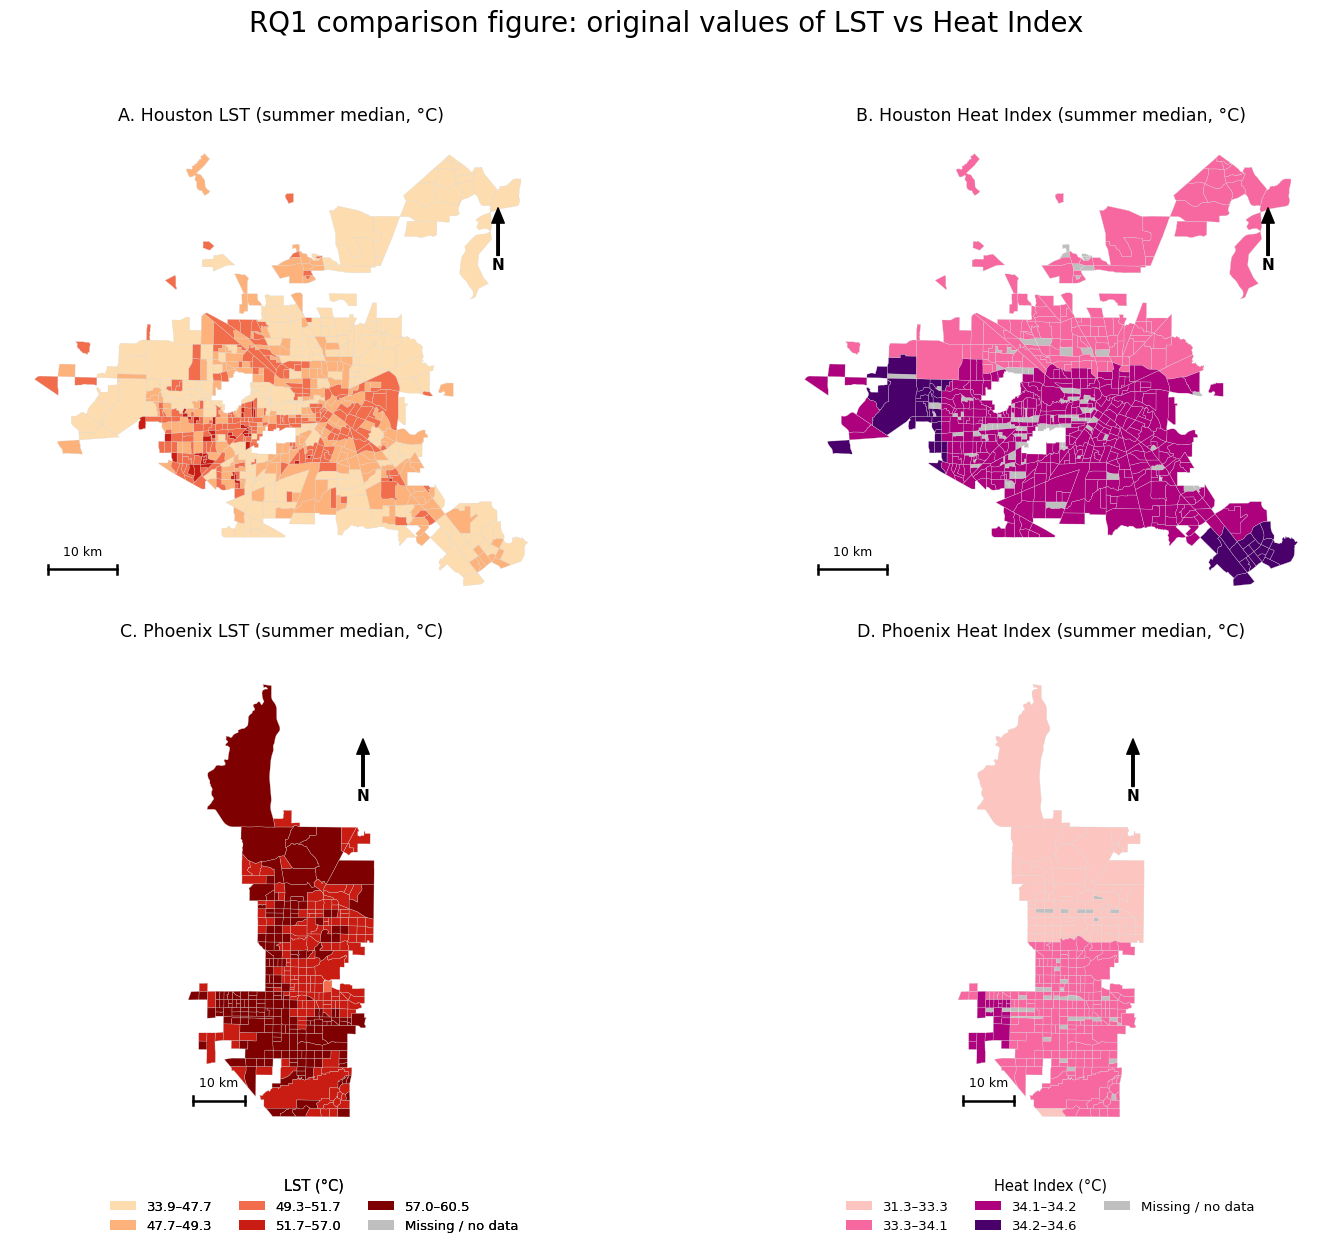

,city,tract_rows,missing_lst,missing_hi,lst_min_c,lst_median_c,lst_max_c,hi_min_c,hi_median_c,hi_max_c
0,Houston,654,0,105,33.932659,48.531293,53.481081,33.805164,34.182125,34.556514
1,Phoenix,373,0,41,51.440967,57.217040,60.466231,31.306490,33.308242,34.186790



Polished figure file check:
/Users/yufeizhou/Desktop/heat-exposure-compare/figures/pilot/teacher_ready_original_values_choropleth_polished.png -> True
/Users/yufeizhou/Desktop/heat-exposure-compare/outputs/pilot/rq1_original_value_map_qc_polished.csv -> True


In [3]:
# ============================================================
# Block 36 FINAL POLISH REPLACEMENT
# Teacher-requested original-value choropleth map
# Polished version for professor review
# ============================================================

from pathlib import Path
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

# -----------------------------
# locate project root
# -----------------------------
project_root = Path.cwd()
if not (project_root / "data_processed").exists():
    project_root = project_root.parent

figure_dir = project_root / "figures" / "pilot"
output_dir = project_root / "outputs" / "pilot"
figure_dir.mkdir(parents=True, exist_ok=True)
output_dir.mkdir(parents=True, exist_ok=True)

# -----------------------------
# helpers
# -----------------------------
def first_existing(candidates):
    for p in candidates:
        if p.exists():
            return p
    raise FileNotFoundError(
        "None of these files exists:\n" + "\n".join(str(x) for x in candidates)
    )

def pick_first_column(gdf, candidates, label):
    for c in candidates:
        if c in gdf.columns:
            return c
    raise ValueError(
        f"Could not find a valid {label} column. Tried: {candidates}\n"
        f"Available columns are:\n{list(gdf.columns)}"
    )

def load_city_gdf(path, city_name):
    gdf = gpd.read_file(path).copy()

    lst_col = pick_first_column(
        gdf,
        ["lst_c", "lst_value", "lst_summer_median_c", "median_lst_c", "median_lst", "lst_median_c"],
        "LST"
    )
    hi_col = pick_first_column(
        gdf,
        ["hi_c", "hi_value", "hi_summer_median_c", "median_hi_c", "hi_median_c", "median_heat_index_c", "heat_index_median_c"],
        "Heat Index"
    )

    gdf["city"] = city_name
    gdf["lst_value"] = pd.to_numeric(gdf[lst_col], errors="coerce")
    gdf["hi_value"] = pd.to_numeric(gdf[hi_col], errors="coerce")
    gdf = gdf.loc[gdf.geometry.notna()].copy()

    return gdf, lst_col, hi_col

def make_common_bins(series, q=5, decimals=1):
    s = pd.Series(series).dropna().astype(float)
    if len(s) == 0:
        raise ValueError("Series is empty after dropping NA.")

    _, bins = pd.qcut(s, q=q, retbins=True, duplicates="drop")
    bins = np.array(bins, dtype=float)
    bins = np.round(bins, decimals)
    bins = np.unique(bins)

    if len(bins) < 3:
        bins = np.linspace(s.min(), s.max(), q + 1)
        bins = np.round(bins, decimals)
        bins = np.unique(bins)

    bins = np.sort(bins)
    bins[0] = min(bins[0], s.min()) - 1e-6
    bins[-1] = max(bins[-1], s.max()) + 1e-6

    labels = []
    for i in range(len(bins) - 1):
        labels.append(f"{bins[i]:.{decimals}f}–{bins[i+1]:.{decimals}f}")
    return bins, labels

def classify_values(gdf, value_col, bins, labels, out_col):
    gdf[out_col] = pd.cut(
        gdf[value_col],
        bins=bins,
        labels=labels,
        include_lowest=True
    )
    return gdf

def add_north_arrow(ax, x=0.90, y=0.84):
    ax.annotate(
        "",
        xy=(x, y),
        xytext=(x, y - 0.10),
        xycoords="axes fraction",
        arrowprops=dict(facecolor="black", width=1.8, headwidth=9, headlength=11)
    )
    ax.text(
        x, y - 0.12, "N",
        transform=ax.transAxes,
        ha="center", va="center",
        fontsize=11, fontweight="bold"
    )

def add_scale_bar(ax, length_km=10):
    xmin, xmax = ax.get_xlim()
    ymin, ymax = ax.get_ylim()

    bar_len = length_km * 1000  # projected CRS in meters
    x0 = xmin + 0.07 * (xmax - xmin)
    y0 = ymin + 0.08 * (ymax - ymin)

    ax.plot([x0, x0 + bar_len], [y0, y0], color="black", lw=1.8)
    ax.plot([x0, x0], [y0 - 0.01*(ymax-ymin), y0 + 0.01*(ymax-ymin)], color="black", lw=1.8)
    ax.plot([x0 + bar_len, x0 + bar_len], [y0 - 0.01*(ymax-ymin), y0 + 0.01*(ymax-ymin)], color="black", lw=1.8)
    ax.text(x0 + bar_len/2, y0 + 0.022*(ymax-ymin), f"{length_km} km",
            ha="center", va="bottom", fontsize=9)

def plot_panel(ax, gdf, class_col, label_order, colors, title):
    missing_mask = gdf[class_col].isna()
    if missing_mask.any():
        gdf.loc[missing_mask].plot(
            ax=ax,
            color="#bfbfbf",
            edgecolor="#e6e6e6",
            linewidth=0.20
        )

    for label, color in zip(label_order, colors):
        sub = gdf.loc[gdf[class_col] == label]
        if len(sub) > 0:
            sub.plot(
                ax=ax,
                color=color,
                edgecolor="#d8d8d8",
                linewidth=0.20
            )

    ax.set_title(title, fontsize=12.5, pad=8)
    ax.set_axis_off()
    add_north_arrow(ax)
    add_scale_bar(ax, length_km=10)

# -----------------------------
# files
# -----------------------------
houston_path = first_existing([
    project_root / "data_processed" / "houston" / "houston_master_with_lst_hi_fixed.gpkg",
    project_root / "data_processed" / "houston" / "houston_master_with_lst_hi.gpkg",
    project_root / "data_processed" / "houston" / "houston_master_demo_poverty.gpkg",
    project_root / "data_processed" / "houston" / "houston_master_demo.gpkg",
])

phoenix_path = first_existing([
    project_root / "data_processed" / "phoenix" / "phoenix_master_with_lst_hi_fixed.gpkg",
    project_root / "data_processed" / "phoenix" / "phoenix_master_with_lst_hi.gpkg",
    project_root / "data_processed" / "phoenix" / "phoenix_master_demo_poverty.gpkg",
    project_root / "data_processed" / "phoenix" / "phoenix_master_demo.gpkg",
])

houston, houston_lst_col, houston_hi_col = load_city_gdf(houston_path, "Houston")
phoenix, phoenix_lst_col, phoenix_hi_col = load_city_gdf(phoenix_path, "Phoenix")

print("Houston LST column:", houston_lst_col)
print("Houston HI column:", houston_hi_col)
print("Phoenix LST column:", phoenix_lst_col)
print("Phoenix HI column:", phoenix_hi_col)

# -----------------------------
# common bins
# -----------------------------
lst_all = pd.concat([houston["lst_value"], phoenix["lst_value"]], ignore_index=True)
hi_all = pd.concat([houston["hi_value"], phoenix["hi_value"]], ignore_index=True)

lst_bins, lst_labels = make_common_bins(lst_all, q=5, decimals=1)
hi_bins, hi_labels = make_common_bins(hi_all, q=5, decimals=1)

print("LST bins:", lst_bins)
print("HI bins:", hi_bins)

houston = classify_values(houston, "lst_value", lst_bins, lst_labels, "lst_class")
phoenix = classify_values(phoenix, "lst_value", lst_bins, lst_labels, "lst_class")
houston = classify_values(houston, "hi_value", hi_bins, hi_labels, "hi_class")
phoenix = classify_values(phoenix, "hi_value", hi_bins, hi_labels, "hi_class")

# -----------------------------
# stronger colors
# -----------------------------
lst_cmap = plt.get_cmap("OrRd", len(lst_labels) + 1)
hi_cmap = plt.get_cmap("RdPu", len(hi_labels) + 1)

# skip the palest color to make Houston clearer
lst_colors = [lst_cmap(i) for i in range(1, len(lst_labels) + 1)]
hi_colors = [hi_cmap(i) for i in range(1, len(hi_labels) + 1)]

# -----------------------------
# plot
# -----------------------------
fig, axes = plt.subplots(2, 2, figsize=(16, 13))

plot_panel(
    axes[0, 0], houston, "lst_class", lst_labels, lst_colors,
    "A. Houston LST (summer median, °C)"
)
plot_panel(
    axes[0, 1], houston, "hi_class", hi_labels, hi_colors,
    "B. Houston Heat Index (summer median, °C)"
)
plot_panel(
    axes[1, 0], phoenix, "lst_class", lst_labels, lst_colors,
    "C. Phoenix LST (summer median, °C)"
)
plot_panel(
    axes[1, 1], phoenix, "hi_class", hi_labels, hi_colors,
    "D. Phoenix Heat Index (summer median, °C)"
)

fig.suptitle(
    "RQ1 comparison figure: original values of LST vs Heat Index",
    fontsize=20, y=0.98
)

lst_handles = [Patch(facecolor=c, edgecolor="none", label=l) for c, l in zip(lst_colors, lst_labels)]
lst_handles.append(Patch(facecolor="#bfbfbf", edgecolor="none", label="Missing / no data"))

hi_handles = [Patch(facecolor=c, edgecolor="none", label=l) for c, l in zip(hi_colors, hi_labels)]
hi_handles.append(Patch(facecolor="#bfbfbf", edgecolor="none", label="Missing / no data"))

leg1 = fig.legend(
    handles=lst_handles,
    title="LST (°C)",
    loc="lower center",
    bbox_to_anchor=(0.28, 0.03),
    ncol=3,
    frameon=False,
    fontsize=9.5,
    title_fontsize=10.5
)
leg2 = fig.legend(
    handles=hi_handles,
    title="Heat Index (°C)",
    loc="lower center",
    bbox_to_anchor=(0.74, 0.03),
    ncol=3,
    frameon=False,
    fontsize=9.5,
    title_fontsize=10.5
)
fig.add_artist(leg1)

plt.tight_layout(rect=[0, 0.10, 1, 0.95])

teacher_original_out = figure_dir / "teacher_ready_original_values_choropleth_polished.png"
plt.savefig(teacher_original_out, dpi=300, bbox_inches="tight")
plt.show()

# -----------------------------
# QC
# -----------------------------
qc_rows = []
for city_name, gdf in [("Houston", houston), ("Phoenix", phoenix)]:
    qc_rows.append({
        "city": city_name,
        "tract_rows": len(gdf),
        "missing_lst": int(gdf["lst_value"].isna().sum()),
        "missing_hi": int(gdf["hi_value"].isna().sum()),
        "lst_min_c": float(gdf["lst_value"].min()) if gdf["lst_value"].notna().any() else np.nan,
        "lst_median_c": float(gdf["lst_value"].median()) if gdf["lst_value"].notna().any() else np.nan,
        "lst_max_c": float(gdf["lst_value"].max()) if gdf["lst_value"].notna().any() else np.nan,
        "hi_min_c": float(gdf["hi_value"].min()) if gdf["hi_value"].notna().any() else np.nan,
        "hi_median_c": float(gdf["hi_value"].median()) if gdf["hi_value"].notna().any() else np.nan,
        "hi_max_c": float(gdf["hi_value"].max()) if gdf["hi_value"].notna().any() else np.nan,
    })

qc_df = pd.DataFrame(qc_rows)
display(qc_df)

qc_out = output_dir / "rq1_original_value_map_qc_polished.csv"
qc_df.to_csv(qc_out, index=False)

print("\nPolished figure file check:")
for p in [teacher_original_out, qc_out]:
    print(p, "->", p.exists())